In [ ]:
# @title ▶️ Step 1: Setup and Imports
#
# This cell mounts your Google Drive to make your data file accessible
# and imports all the necessary libraries for data manipulation,
# model building, and visualization.

import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

# Mount Google Drive
try:
    drive.mount('/content/drive')
    print("✅ Google Drive mounted successfully!")
except:
    print("⚠️ Could not mount Google Drive.")

Mounted at /content/drive
✅ Google Drive mounted successfully!


In [ ]:
# @title ▶️ STEP 1: Setup - Mount Drive, Import Libraries, Load & Save Data
#
# Run this script ONCE at the beginning of your session. It performs all
# necessary setup, loads all data (features, timeseries, CLIP), scales
# the features, and saves everything into a single 'all_data.pkl' file
# for the experiment scripts to use.

import numpy as np
import tensorflow as tf
import json
import os
import pickle
from google.colab import drive
from sklearn.preprocessing import StandardScaler

# --- 1. Mount Google Drive ---
try:
    drive.mount('/content/drive')
    print("✅ Google Drive mounted successfully!")
except Exception as e:
    print(f"⚠️ Could not mount Google Drive. Error: {e}")

# --- 2. Imports & Seed Setting ---
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(42)
np.random.seed(42)
print("✅ Libraries imported and seeds set.")

# --- 3. Load Pre-computed Features (X_raw, y_raw) ---
print("\n--- Loading Pre-computed Features ---")
feature_json_paths = [
    '/content/drive/MyDrive/Feature Detection File for all subjects/Anvita_New1_processed_features.json',
    '/content/drive/MyDrive/Feature Detection File for all subjects/SharadNew_processed_features.json',
    '/content/drive/MyDrive/Feature Detection File for all subjects/anushka2_processed_features.json',
    '/content/drive/MyDrive/Feature Detection File for all subjects/anushka3_processed_features.json',
    '/content/drive/MyDrive/Feature Detection File for all subjects/sub01_processed_features.json',
    '/content/drive/MyDrive/Feature Detection File for all subjects/sub02_processed_features.json',
    '/content/drive/MyDrive/Feature Detection File for all subjects/sub03_processed_features.json',
    '/content/drive/MyDrive/Feature Detection File for all subjects/sub06_processed_features.json',
    '/content/drive/MyDrive/Feature Detection File for all subjects/sub08new_processed_features.json',
    '/content/drive/MyDrive/Feature Detection File for all subjects/sub09_processed_features.json',
    '/content/drive/MyDrive/Feature Detection File for all subjects/sub10Diya_processed_features.json',
    '/content/drive/MyDrive/Feature Detection File for all subjects/sub11_processed_features.json',
    '/content/drive/MyDrive/Feature Detection File for all subjects/sub12_processed_features.json',
    '/content/drive/MyDrive/Feature Detection File for all subjects/sub14_processed_features.json',
    '/content/drive/MyDrive/Feature Detection File for all subjects/sub15_processed_features.json'
]

all_data, clean_data = [], []
loaded_files_count = 0
for file_path in feature_json_paths:
    if os.path.exists(file_path):
        try:
            with open(file_path, 'r') as f:
                data = json.load(f)
                all_data.extend(data)
                loaded_files_count += 1
                print(f"  Processed: {os.path.basename(file_path)}")
        except Exception as e:
            print(f"  ⚠️ Warning: Could not load or process {os.path.basename(file_path)}. Error: {e}")
    else:
        print(f"  ⚠️ Warning: File not found {file_path}. Skipping.")

print(f"\nLoaded data from {loaded_files_count}/{len(feature_json_paths)} feature files.")

rejected_count = 0
for trial in all_data:
    if np.sum(np.abs(trial['features'][0])) > 1e-9 and np.sum(np.abs(trial['features'][1])) > 1e-9:
        clean_data.append(trial)
    else:
        rejected_count += 1

y_raw = np.array([trial['label'] for trial in clean_data])
X_raw = np.array([trial['features'] for trial in clean_data])
print(f"Filtered {rejected_count} trials with zero features.")
print(f"Final pre-computed feature samples: {len(X_raw)}")

# --- 4. Scale Pre-computed Features ---
num_samples, num_channels, num_features_per_channel = X_raw.shape
X_reshaped = X_raw.reshape(num_samples, num_channels * num_features_per_channel)
scaler = StandardScaler()
X_scaled_features = scaler.fit_transform(X_reshaped) # Use a distinct variable name
print(f"✅ Pre-computed features scaled. Shape: {X_scaled_features.shape}")

# --- 5. Load Raw Time-Series Data ---
print("\n--- Loading Raw Time-Series Data ---")
filtered_json_paths = [
    '/content/drive/MyDrive/Filtered EEG Files/SharadNew_filtered_eeg.json',
    '/content/drive/MyDrive/Filtered EEG Files/Anvita_New1_filtered_eeg.json',
    '/content/drive/MyDrive/Filtered EEG Files/anushka1_filtered_eeg.json',
    '/content/drive/MyDrive/Filtered EEG Files/anushka2_filtered_eeg.json',
    '/content/drive/MyDrive/Filtered EEG Files/anushka3_filtered_eeg.json',
    '/content/drive/MyDrive/Filtered EEG Files/sub01_filtered_eeg.json',
    '/content/drive/MyDrive/Filtered EEG Files/sub02_filtered_eeg.json',
    '/content/drive/MyDrive/Filtered EEG Files/sub03_filtered_eeg.json',
    '/content/drive/MyDrive/Filtered EEG Files/sub06_filtered_eeg.json',
    '/content/drive/MyDrive/Filtered EEG Files/sub08new_filtered_eeg.json',
    '/content/drive/MyDrive/Filtered EEG Files/sub09_filtered_eeg.json',
    '/content/drive/MyDrive/Filtered EEG Files/sub10Diya_filtered_eeg.json',
    '/content/drive/MyDrive/Filtered EEG Files/sub11_filtered_eeg.json',
    '/content/drive/MyDrive/Filtered EEG Files/sub12_filtered_eeg.json',
    '/content/drive/MyDrive/Filtered EEG Files/sub14_filtered_eeg.json',
    '/content/drive/MyDrive/Filtered EEG Files/sub15_filtered_eeg.json'
]
all_trials_data, all_trials_labels = [], []
loaded_files_count = 0
for file_path in filtered_json_paths:
     if os.path.exists(file_path):
        try:
            with open(file_path, 'r') as f:
                data = json.load(f)
                for trial in data:
                    all_trials_data.append(np.array(trial['eeg_data']))
                    all_trials_labels.append(trial['label'])
            loaded_files_count += 1
            print(f"  Processed: {os.path.basename(file_path)}")
        except Exception as e:
            print(f"  ⚠️ Warning: Could not load or process {os.path.basename(file_path)}. Error: {e}")
     else:
        print(f"  ⚠️ Warning: File not found {file_path}. Skipping.")


X_timeseries = np.array(all_trials_data).transpose(0, 2, 1)
y_timeseries_str = np.array(all_trials_labels)
print(f"\nLoaded data from {loaded_files_count}/{len(filtered_json_paths)} time-series files.")
print(f"Final time-series samples: {len(X_timeseries)}")

# --- 6. Load CLIP Embeddings ---
print("\n--- Loading CLIP Embeddings ---")
try:
    clip_embeddings = np.load('/content/drive/MyDrive/clip_embeddings_new.npy', allow_pickle=True).item()
    print(f"✅ Loaded embeddings for classes: {list(clip_embeddings.keys())}")
except FileNotFoundError:
     raise SystemExit("❌ ERROR: 'clip_embeddings_new.npy' not found. Please ensure the file exists in your Drive.")

# --- 7. Package and Save All Data ---
# **MODIFIED**: Include the scaled features in the saved dictionary
data_to_save = {
    'X_raw': X_raw,
    'y_raw': y_raw,
    'X_scaled_features': X_scaled_features, # <-- Added the scaled features
    'X_timeseries': X_timeseries,
    'y_timeseries_str': y_timeseries_str,
    'clip_embeddings': clip_embeddings,
}
output_filename = 'all_data.pkl'
with open(output_filename, 'wb') as f:
    pickle.dump(data_to_save, f)

print(f"\n✅ All data loaded, processed, and saved to '{output_filename}'. You can now run the experiment scripts.")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted successfully!
✅ Libraries imported and seeds set.

--- Loading Pre-computed Features ---
  Processed: Anvita_New1_processed_features.json
  Processed: SharadNew_processed_features.json
  Processed: anushka2_processed_features.json
  Processed: anushka3_processed_features.json
  Processed: sub01_processed_features.json
  Processed: sub02_processed_features.json
  Processed: sub03_processed_features.json
  Processed: sub06_processed_features.json
  Processed: sub08new_processed_features.json
  Processed: sub09_processed_features.json
  Processed: sub10Diya_processed_features.json
  Processed: sub11_processed_features.json
  Processed: sub12_processed_features.json
  Processed: sub14_processed_features.json
  Processed: sub15_processed_features.json

Loaded data from 15/15 feature files.
Filtered 149 trials with zero features.
Final pre-co

In [ ]:
# @title Helper Functions for All Experiments
#
# This file contains shared functions used by the training and validation scripts,
# such as the Triplet Loss function and the L2 Normalization layer.

import tensorflow as tf
import numpy as np

def L2Normalization(x):
    """A named function for L2 normalization for safe model saving/loading."""
    return tf.math.l2_normalize(x, axis=1)

def triplet_loss(y_true, y_pred, alpha=0.4):
    """
    The Triplet Loss function. It calculates the loss based on the distances
    between the anchor, positive, and negative embeddings.
    """
    embedding_dim = tf.shape(y_pred)[1] // 3
    anchor, pos, neg = y_pred[:, :embedding_dim], y_pred[:, embedding_dim:embedding_dim*2], y_pred[:, embedding_dim*2:]

    pos_dist = tf.reduce_sum(tf.square(anchor - pos), axis=1)
    neg_dist = tf.reduce_sum(tf.square(anchor - neg), axis=1)

    loss = tf.reduce_mean(tf.maximum(pos_dist - neg_dist + alpha, 0.0))
    return loss

def create_triplets(X_features, y_labels_str, clip_embeds):
    """
    Generates triplets of (anchor, positive, negative) for training the model.
    """
    x_anchor, x_positive, x_negative = [], [], []
    classes = list(clip_embeds.keys())

    for i in range(len(X_features)):
        anchor_eeg = X_features[i]
        true_label_name = y_labels_str[i]

        positive_clip = clip_embeds[true_label_name]

        # Select a random negative class
        negative_label_name = np.random.choice([c for c in classes if c != true_label_name])
        negative_clip = clip_embeds[negative_label_name]

        x_anchor.append(anchor_eeg)
        x_positive.append(positive_clip)
        x_negative.append(negative_clip)

    return np.array(x_anchor), np.array(x_positive), np.array(x_negative)



In [ ]:
# @title  Run Experiment 01 - Simple Feed-Forward Network (FFN)
#
# This script trains the simple but effective FFN architecture that previously
# achieved high accuracy. It serves as our baseline model.

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda, GaussianNoise
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
import pickle
import os

# --- HELPER FUNCTIONS (to make script self-contained) ---

def L2Normalization(x):
    """A named function for L2 normalization for safe model saving."""
    return tf.math.l2_normalize(x, axis=1)

def triplet_loss(y_true, y_pred, alpha=0.4):
    """The Triplet Loss function."""
    embedding_dim = tf.shape(y_pred)[1] // 3
    anchor, pos, neg = y_pred[:, :embedding_dim], y_pred[:, embedding_dim:embedding_dim*2], y_pred[:, embedding_dim*2:]
    pos_dist = tf.reduce_sum(tf.square(anchor - pos), axis=1)
    neg_dist = tf.reduce_sum(tf.square(anchor - neg), axis=1)
    loss = tf.reduce_mean(tf.maximum(pos_dist - neg_dist + alpha, 0.0))
    return loss

def create_triplets(X_features, y_labels_str, clip_embeds):
    """Creates anchor, positive, and negative samples for training."""
    x_anchor, x_positive, x_negative = [], [], []
    classes = list(clip_embeds.keys())
    for i in range(len(X_features)):
        anchor_eeg, true_label_name = X_features[i], y_labels_str[i]
        positive_clip = clip_embeds[true_label_name]
        negative_label_name = np.random.choice([c for c in classes if c != true_label_name])
        negative_clip = clip_embeds[negative_label_name]
        x_anchor.append(anchor_eeg)
        x_positive.append(positive_clip)
        x_negative.append(negative_clip)
    return np.array(x_anchor), np.array(x_positive), np.array(x_negative)


# --- 1. SET RANDOM SEEDS ---
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(42)
np.random.seed(42)

# --- 2. LOAD & PREPARE DATA ---
print("--- Loading and Preparing Data for Experiment 01 ---")
with open('all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)
X_raw = all_data['X_raw']
y_raw = all_data['y_raw']
clip_embeddings = all_data['clip_embeddings']

# Scale the pre-computed features
num_samples, num_channels, num_features_per_channel = X_raw.shape
X_reshaped = X_raw.reshape(num_samples, num_channels * num_features_per_channel)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped)
print(f"✅ Data prepared and scaled. Shape: {X_scaled.shape}")

# --- 3. BUILD THE FFN ENCODER MODEL ---
def build_simple_ffn_encoder(input_shape, embedding_dim):
    """Builds the simple Feed-Forward Network encoder."""
    eeg_input = Input(shape=input_shape, name="eeg_input")
    x = GaussianNoise(0.1)(eeg_input)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.002))(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.002))(x)
    x = Dropout(0.5)(x)
    x = Dense(embedding_dim, activation=None)(x)
    x = Lambda(L2Normalization, name="L2Normalization")(x)
    return Model(inputs=eeg_input, outputs=x, name="EEG_Encoder_Simple_FFN")

EEG_FEATURE_SHAPE = (X_scaled.shape[1],)
EMBEDDING_DIM = 512
encoder = build_simple_ffn_encoder(EEG_FEATURE_SHAPE, EMBEDDING_DIM)
print("\n--- Model Architecture ---")
encoder.summary()

# --- 4. CREATE TRIPLETS & COMPILE FULL MODEL ---
anchor, positive, negative = create_triplets(X_scaled, y_raw, clip_embeddings)
anchor_input = Input(shape=EEG_FEATURE_SHAPE)
pos_input = Input(shape=(EMBEDDING_DIM,))
neg_input = Input(shape=(EMBEDDING_DIM,))
eeg_embedding = encoder(anchor_input)
merged_output = tf.keras.layers.concatenate([eeg_embedding, pos_input, neg_input], axis=1)
training_model = Model(inputs=[anchor_input, pos_input, neg_input], outputs=merged_output)
training_model.compile(optimizer=Adam(learning_rate=0.0001), loss=triplet_loss)

# --- 5. TRAIN THE ENCODER ---
early_stopping = EarlyStopping(monitor='val_loss', patience=25, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6, verbose=1)

print("\n🚀 Starting training for Experiment 01...")
history = training_model.fit(
    [anchor, positive, negative], np.zeros((anchor.shape[0], 1)),
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)
print("\n✅ Training complete!")

# --- 6. SAVE THE TRAINED ENCODER ---
encoder_filename = 'exp01_simple_ffn_encoder.keras'
encoder.save(encoder_filename)
print(f"\n✅ Trained encoder saved successfully to '{encoder_filename}'")
print("\nNow, run '99_validate_model.py' to check the accuracy.")



--- Loading and Preparing Data for Experiment 01 ---
✅ Data prepared and scaled. Shape: (1820, 40)

--- Model Architecture ---


Model: "EEG_Encoder_Simple_FFN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)          │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2Normalization (Lambda)        │ (None, 512)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,808 (343.00 KB)

 Trainable params: 87,808 (343.00 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Starting training for Experiment 01...
Epoch 1/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.7729 - val_loss: 0.7569 - learning_rate: 1.0000e-04
Epoch 2/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7481 - val_loss: 0.7456 - learning_rate: 1.0000e-04
Epoch 3/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.7244 - val_loss: 0.7354 - learning_rate: 1.0000e-04
Epoch 4/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7051 - val_loss: 0.7255 - learning_rate: 1.0000e-04
Epoch 5/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6824 - val_loss: 0.7172 - learning_rate: 1.0000e-04
Epoch 6/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6643 - val_loss: 0.7093 - learning_rate: 1.0000e-04
Epoch 7/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6478 - val_loss: 0.7020 - learning_rate: 1.0000e-04
Epoch 8/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6309 - val_loss: 0.6957 - learning_rate: 1.0000e-04
Epoch 9/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - 

--- Validating Model: /content/exp01_simple_ffn_encoder.keras ---
✅ Encoder model loaded successfully.
✅ Prepared 364 test samples.
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

--- OVERALL PERFORMANCE ON TEST SET ---
✅ Accuracy: 56.59%


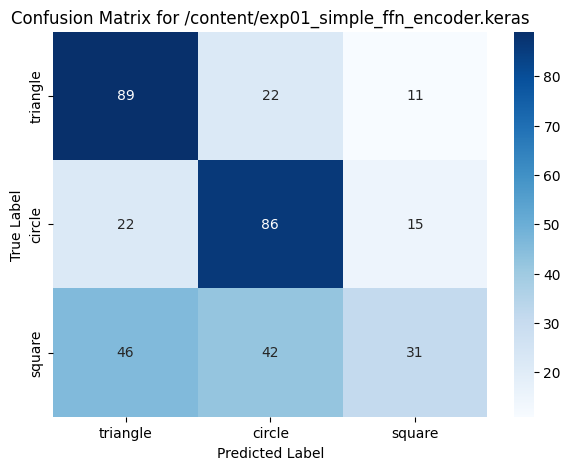

In [ ]:
# @title  Validate Model (Corrected & Self-Contained)
#
# This script loads a saved encoder, matches EEG to images, and calculates
# the overall accuracy on the entire test set. It is now self-contained.

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# --- HELPER FUNCTION (Previously in shared_utils.py) ---
def L2Normalization(x):
    """A named function for L2 normalization for safe model saving."""
    return tf.math.l2_normalize(x, axis=1)

# --- ⬇️ CONFIGURATION FOR VALIDATION ⬇️ ---
# ⚠️ Update these two variables before running!
MODEL_FILENAME = '/content/exp01_simple_ffn_encoder.keras' # e.g., 'exp02_wider_ffn_encoder.keras'
DATA_TYPE = 'features' # Can be 'features' or 'timeseries'
# --- ⬆️ CONFIGURATION FOR VALIDATION ⬆️ ---

print(f"--- Validating Model: {MODEL_FILENAME} ---")

# 1. Load packaged data from the setup script
try:
    with open('all_data.pkl', 'rb') as f:
        all_data = pickle.load(f)
    clip_embeddings = all_data['clip_embeddings']
except FileNotFoundError:
    raise SystemExit("❌ ERROR: 'all_data.pkl' not found. Please run the '00_setup.py' script first.")

# 2. Load the specific encoder model
try:
    encoder = tf.keras.models.load_model(MODEL_FILENAME, custom_objects={'L2Normalization': L2Normalization})
    print("✅ Encoder model loaded successfully.")
except Exception as e:
     raise SystemExit(f"❌ ERROR: Could not load the model. Make sure '{MODEL_FILENAME}' exists. Error details: {e}")

# 3. Prepare the correct dataset for testing
if DATA_TYPE == 'features':
    num_samples, num_channels, num_features_per_channel = all_data['X_raw'].shape
    X_reshaped = all_data['X_raw'].reshape(num_samples, num_channels * num_features_per_channel)
    scaler = StandardScaler()
    X_full_data = scaler.fit_transform(X_reshaped)
    y_full_data = all_data['y_raw']
elif DATA_TYPE == 'timeseries':
    X_full_data = all_data['X_timeseries']
    y_full_data = all_data['y_timeseries_str']
else:
    raise ValueError("DATA_TYPE must be 'features' or 'timeseries'")

# Create a consistent test split
_, X_test, _, y_test = train_test_split(X_full_data, y_full_data, test_size=0.2, random_state=42, stratify=y_full_data)
print(f"✅ Prepared {len(X_test)} test samples.")

# 4. Generate Embeddings and Make Predictions
predicted_eeg_embeddings = encoder.predict(X_test)
class_labels = list(clip_embeddings.keys())
clip_matrix = np.vstack([clip_embeddings[label] for label in class_labels])
similarities = cosine_similarity(predicted_eeg_embeddings, clip_matrix)
pred_indices = np.argmax(similarities, axis=1)
pred_labels = [class_labels[i] for i in pred_indices]

# 5. Display Results
accuracy = accuracy_score(y_test, pred_labels)
print(f"\n--- OVERALL PERFORMANCE ON TEST SET ---")
print(f"✅ Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, pred_labels, labels=class_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Confusion Matrix for {MODEL_FILENAME}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



# t-SNE of Simple FFN

✅ Encoder loaded
🔄 Generating EEG embeddings...
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
🔄 Running t-SNE...


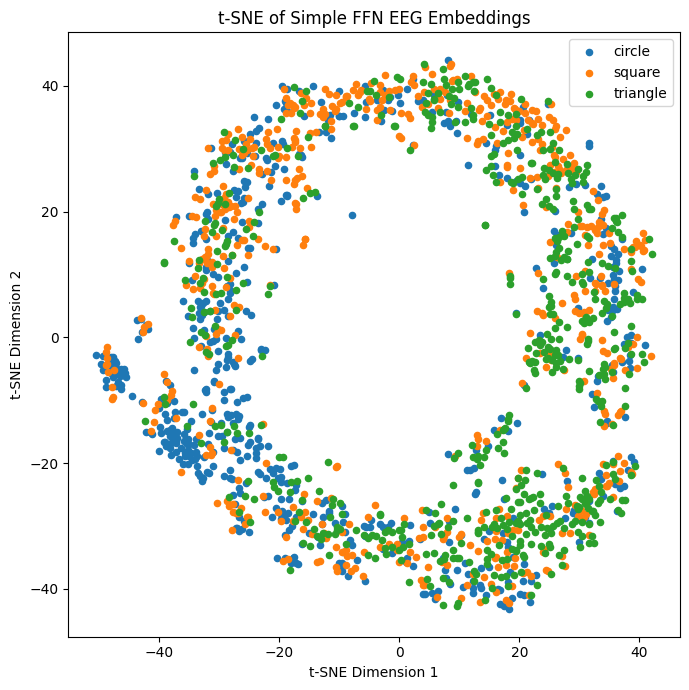

In [ ]:
# ============================================================
# t-SNE Visualization – Simple FFN (Matched with TriFusion Style)
# ============================================================

import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ---------- Helper ----------
def L2Normalization(x):
    return tf.math.l2_normalize(x, axis=1)

# ---------- Load trained encoder ----------
ENCODER_PATH = "exp01_simple_ffn_encoder.keras"
encoder = tf.keras.models.load_model(
    ENCODER_PATH,
    custom_objects={"L2Normalization": L2Normalization}
)
encoder.eval = lambda: None  # compatibility safeguard
print("✅ Encoder loaded")

# ---------- Load data ----------
with open("all_data.pkl", "rb") as f:
    all_data = pickle.load(f)

X_raw = all_data["X_raw"]
y_raw = all_data["y_raw"]
unique_labels = sorted(list(set(y_raw)))

# ---------- Prepare EEG features ----------
num_samples, num_channels, num_features = X_raw.shape
X_flat = X_raw.reshape(num_samples, num_channels * num_features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

# ---------- Generate EEG embeddings ----------
print("🔄 Generating EEG embeddings...")
Z = encoder.predict(X_scaled, batch_size=64)

# ---------- t-SNE ----------
print("🔄 Running t-SNE...")
ts = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="pca",
    random_state=42
)
Z2 = ts.fit_transform(Z)

# ---------- Plot (MATCHES TRIFUSION STYLE) ----------
plt.figure(figsize=(7,7))

for lab in unique_labels:
    idx = np.where(np.array(y_raw) == lab)[0]
    plt.scatter(
        Z2[idx, 0],
        Z2[idx, 1],
        s=20,
        label=lab
    )

plt.legend()
plt.title("t-SNE of Simple FFN EEG Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()


In [ ]:
# @title  Run Experiment 02 - Wider Feed-Forward Network (FFN)
#
# This script trains an FFN with more neurons in each layer to see if
# a wider architecture can learn broader feature representations.
# MODIFIED: Made self-contained to remove the 'shared_utils' import error.

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda, GaussianNoise
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
import pickle
import os

# --- 1. SET RANDOM SEEDS ---
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(42)
np.random.seed(42)

# --- HELPER FUNCTIONS (Previously in shared_utils.py) ---
def L2Normalization(x):
    """A named function for L2 normalization for safe model saving."""
    return tf.math.l2_normalize(x, axis=1)

def triplet_loss(y_true, y_pred, alpha=0.4):
    """The Triplet Loss function."""
    embedding_dim = tf.shape(y_pred)[1] // 3
    anchor, pos, neg = y_pred[:, :embedding_dim], y_pred[:, embedding_dim:embedding_dim*2], y_pred[:, embedding_dim*2:]
    pos_dist = tf.reduce_sum(tf.square(anchor - pos), axis=1)
    neg_dist = tf.reduce_sum(tf.square(anchor - neg), axis=1)
    loss = tf.reduce_mean(tf.maximum(pos_dist - neg_dist + alpha, 0.0))
    return loss

def create_triplets(X_features, y_labels_str, clip_embeds):
    """Creates anchor, positive, and negative samples for training."""
    x_anchor, x_positive, x_negative = [], [], []
    classes = list(clip_embeds.keys())
    for i in range(len(X_features)):
        anchor_eeg, true_label_name = X_features[i], y_labels_str[i]
        positive_clip = clip_embeds[true_label_name]
        negative_label_name = np.random.choice([c for c in classes if c != true_label_name])
        negative_clip = clip_embeds[negative_label_name]
        x_anchor.append(anchor_eeg)
        x_positive.append(positive_clip)
        x_negative.append(negative_clip)
    return np.array(x_anchor), np.array(x_positive), np.array(x_negative)

# --- 2. LOAD & PREPARE DATA ---
print("--- Loading and Preparing Data for Experiment 02 ---")
with open('all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)
X_raw, y_raw, clip_embeddings = all_data['X_raw'], all_data['y_raw'], all_data['clip_embeddings']

# Scale the pre-computed features
num_samples, num_channels, num_features = X_raw.shape
X_reshaped = X_raw.reshape(num_samples, num_channels * num_features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped)
print(f"✅ Data prepared and scaled. Shape: {X_scaled.shape}")

# --- 3. BUILD THE WIDER FFN ENCODER MODEL ---
def build_wider_ffn_encoder(input_shape, embedding_dim):
    """Builds a wider Feed-Forward Network encoder."""
    eeg_input = Input(shape=input_shape, name="eeg_input")
    x = GaussianNoise(0.1)(eeg_input)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.002))(x) # Wider layer
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.002))(x) # Wider layer
    x = Dropout(0.5)(x)
    x = Dense(embedding_dim, activation=None)(x)
    x = Lambda(L2Normalization, name="L2Normalization")(x)
    return Model(inputs=eeg_input, outputs=x, name="EEG_Encoder_Wider_FFN")

EEG_FEATURE_SHAPE = (X_scaled.shape[1],)
EMBEDDING_DIM = 512
encoder = build_wider_ffn_encoder(EEG_FEATURE_SHAPE, EMBEDDING_DIM)
print("\n--- Model Architecture ---")
encoder.summary()

# --- 4. CREATE TRIPLETS & COMPILE FULL MODEL ---
anchor, positive, negative = create_triplets(X_scaled, y_raw, clip_embeddings)
anchor_input, pos_input, neg_input = Input(shape=EEG_FEATURE_SHAPE), Input(shape=(EMBEDDING_DIM,)), Input(shape=(EMBEDDING_DIM,))
eeg_embedding = encoder(anchor_input)
merged_output = tf.keras.layers.concatenate([eeg_embedding, pos_input, neg_input], axis=1)
training_model = Model(inputs=[anchor_input, pos_input, neg_input], outputs=merged_output)
training_model.compile(optimizer=Adam(learning_rate=0.0001), loss=triplet_loss)

# --- 5. TRAIN THE ENCODER ---
early_stopping = EarlyStopping(monitor='val_loss', patience=25, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6, verbose=1)

print("\n🚀 Starting training for Experiment 02...")
training_model.fit(
    [anchor, positive, negative], np.zeros((anchor.shape[0], 1)),
    epochs=200, batch_size=32, validation_split=0.2,
    callbacks=[early_stopping, reduce_lr], verbose=1
)
print("\n✅ Training complete!")

# --- 6. SAVE THE TRAINED ENCODER ---
encoder_filename = 'exp02_wider_ffn_encoder.keras'
encoder.save(encoder_filename)
print(f"\n✅ Trained encoder saved to '{encoder_filename}'")



--- Loading and Preparing Data for Experiment 02 ---
✅ Data prepared and scaled. Shape: (1820, 40)

--- Model Architecture ---


Model: "EEG_Encoder_Wider_FFN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)          │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_1                │ (None, 40)             │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2Normalization (Lambda)        │ (None, 512)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 207,872 (812.00 KB)

 Trainable params: 207,872 (812.00 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Starting training for Experiment 02...
Epoch 1/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 1.0383 - val_loss: 1.0207 - learning_rate: 1.0000e-04
Epoch 2/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.9844 - val_loss: 0.9862 - learning_rate: 1.0000e-04
Epoch 3/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.9305 - val_loss: 0.9537 - learning_rate: 1.0000e-04
Epoch 4/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.8832 - val_loss: 0.9250 - learning_rate: 1.0000e-04
Epoch 5/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.8430 - val_loss: 0.8997 - learning_rate: 1.0000e-04
Epoch 6/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.8024 - val_loss: 0.8766 - learning_rate: 1.0000e-04
Epoch 7/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.7706 - val_loss: 0.8549 - learning_rate: 1.0000e-04
Epoch 8/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.7379 - val_loss: 0.8330 - learning_rate: 1.0000e-04
Epoch 9/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms

# t-SNE for Wider FFN

✅ Wider FFN encoder loaded
🔄 Generating EEG embeddings...
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
🔄 Running t-SNE...


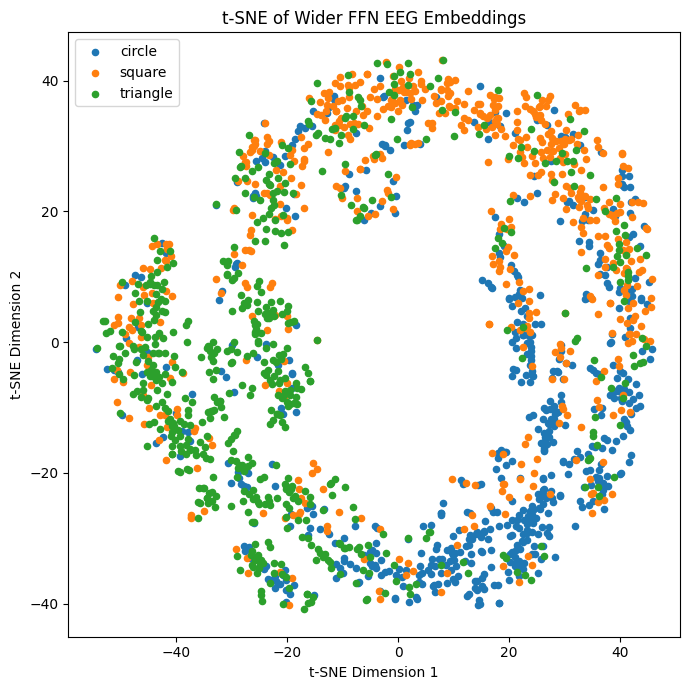

In [ ]:
# ============================================================
# t-SNE Visualization – Wider FFN (Experiment 02)
# Matched with TriFusion & Simple FFN colour scheme
# ============================================================

import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ---------- Helper ----------
def L2Normalization(x):
    return tf.math.l2_normalize(x, axis=1)

# ---------- Load trained encoder ----------
ENCODER_PATH = "exp02_wider_ffn_encoder.keras"
encoder = tf.keras.models.load_model(
    ENCODER_PATH,
    custom_objects={"L2Normalization": L2Normalization}
)
print("✅ Wider FFN encoder loaded")

# ---------- Load data ----------
with open("all_data.pkl", "rb") as f:
    all_data = pickle.load(f)

X_raw = all_data["X_raw"]
y_raw = all_data["y_raw"]
unique_labels = sorted(list(set(y_raw)))

# ---------- Prepare EEG features ----------
num_samples, num_channels, num_features = X_raw.shape
X_flat = X_raw.reshape(num_samples, num_channels * num_features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

# ---------- Generate EEG embeddings ----------
print("🔄 Generating EEG embeddings...")
Z = encoder.predict(X_scaled, batch_size=64)

# ---------- t-SNE ----------
print("🔄 Running t-SNE...")
ts = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="pca",
    random_state=42
)
Z2 = ts.fit_transform(Z)

# ---------- Plot (EXACT SAME STYLE AS TRIFUSION) ----------
plt.figure(figsize=(7, 7))

for lab in unique_labels:
    idx = np.where(np.array(y_raw) == lab)[0]
    plt.scatter(
        Z2[idx, 0],
        Z2[idx, 1],
        s=20,
        label=lab
    )

plt.legend()
plt.title("t-SNE of Wider FFN EEG Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()


--- Validating Model: /content/exp02_wider_ffn_encoder_70.88%_Accuracy.keras ---
✅ Encoder model loaded successfully.
✅ Prepared 364 test samples.
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

--- OVERALL PERFORMANCE ON TEST SET ---
✅ Accuracy: 70.88%


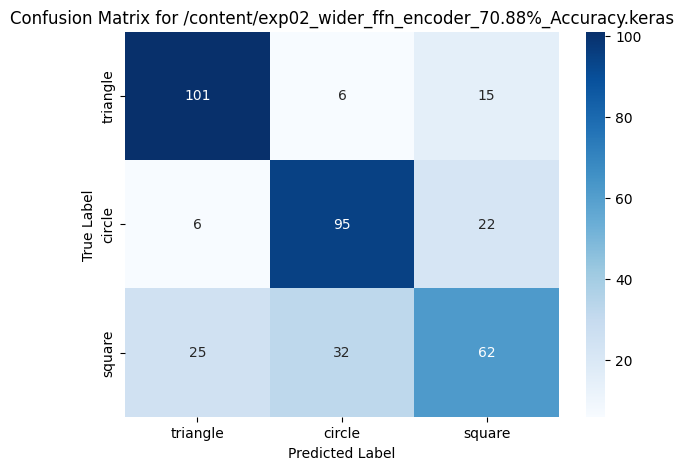

In [ ]:
# @title  Validate Model (Corrected & Self-Contained)
#
# This script loads a saved encoder, matches EEG to images, and calculates
# the overall accuracy on the entire test set. It is now self-contained.

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# --- HELPER FUNCTION (Previously in shared_utils.py) ---
def L2Normalization(x):
    """A named function for L2 normalization for safe model saving."""
    return tf.math.l2_normalize(x, axis=1)

# --- ⬇️ CONFIGURATION FOR VALIDATION ⬇️ ---
# ⚠️ Update these two variables before running!
MODEL_FILENAME = '/content/exp02_wider_ffn_encoder_70.88%_Accuracy.keras' # e.g., 'exp02_wider_ffn_encoder.keras'
DATA_TYPE = 'features' # Can be 'features' or 'timeseries'
# --- ⬆️ CONFIGURATION FOR VALIDATION ⬆️ ---

print(f"--- Validating Model: {MODEL_FILENAME} ---")

# 1. Load packaged data from the setup script
try:
    with open('all_data.pkl', 'rb') as f:
        all_data = pickle.load(f)
    clip_embeddings = all_data['clip_embeddings']
except FileNotFoundError:
    raise SystemExit("❌ ERROR: 'all_data.pkl' not found. Please run the '00_setup.py' script first.")

# 2. Load the specific encoder model
try:
    encoder = tf.keras.models.load_model(MODEL_FILENAME, custom_objects={'L2Normalization': L2Normalization})
    print("✅ Encoder model loaded successfully.")
except Exception as e:
     raise SystemExit(f"❌ ERROR: Could not load the model. Make sure '{MODEL_FILENAME}' exists. Error details: {e}")

# 3. Prepare the correct dataset for testing
if DATA_TYPE == 'features':
    num_samples, num_channels, num_features_per_channel = all_data['X_raw'].shape
    X_reshaped = all_data['X_raw'].reshape(num_samples, num_channels * num_features_per_channel)
    scaler = StandardScaler()
    X_full_data = scaler.fit_transform(X_reshaped)
    y_full_data = all_data['y_raw']
elif DATA_TYPE == 'timeseries':
    X_full_data = all_data['X_timeseries']
    y_full_data = all_data['y_timeseries_str']
else:
    raise ValueError("DATA_TYPE must be 'features' or 'timeseries'")

# Create a consistent test split
_, X_test, _, y_test = train_test_split(X_full_data, y_full_data, test_size=0.2, random_state=42, stratify=y_full_data)
print(f"✅ Prepared {len(X_test)} test samples.")

# 4. Generate Embeddings and Make Predictions
predicted_eeg_embeddings = encoder.predict(X_test)
class_labels = list(clip_embeddings.keys())
clip_matrix = np.vstack([clip_embeddings[label] for label in class_labels])
similarities = cosine_similarity(predicted_eeg_embeddings, clip_matrix)
pred_indices = np.argmax(similarities, axis=1)
pred_labels = [class_labels[i] for i in pred_indices]

# 5. Display Results
accuracy = accuracy_score(y_test, pred_labels)
print(f"\n--- OVERALL PERFORMANCE ON TEST SET ---")
print(f"✅ Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, pred_labels, labels=class_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Confusion Matrix for {MODEL_FILENAME}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



In [ ]:
# @title Run Experiment 03 - FFN with Leaky ReLU
#
# This script replaces the standard ReLU activation with Leaky ReLU, which
# can help prevent the "dying ReLU" problem and improve training stability.

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda, GaussianNoise, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
import pickle
import os

# --- HELPER FUNCTIONS (to make script self-contained) ---
def L2Normalization(x):
    """A named function for L2 normalization for safe model saving."""
    return tf.math.l2_normalize(x, axis=1)

def triplet_loss(y_true, y_pred, alpha=0.4):
    """The Triplet Loss function."""
    embedding_dim = tf.shape(y_pred)[1] // 3
    anchor, pos, neg = y_pred[:, :embedding_dim], y_pred[:, embedding_dim:embedding_dim*2], y_pred[:, embedding_dim*2:]
    pos_dist = tf.reduce_sum(tf.square(anchor - pos), axis=1)
    neg_dist = tf.reduce_sum(tf.square(anchor - neg), axis=1)
    loss = tf.reduce_mean(tf.maximum(pos_dist - neg_dist + alpha, 0.0))
    return loss

def create_triplets(X_features, y_labels_str, clip_embeds):
    """Creates anchor, positive, and negative samples for training."""
    x_anchor, x_positive, x_negative = [], [], []
    classes = list(clip_embeds.keys())
    for i in range(len(X_features)):
        anchor_eeg, true_label_name = X_features[i], y_labels_str[i]
        positive_clip = clip_embeds[true_label_name]
        negative_label_name = np.random.choice([c for c in classes if c != true_label_name])
        negative_clip = clip_embeds[negative_label_name]
        x_anchor.append(anchor_eeg)
        x_positive.append(positive_clip)
        x_negative.append(negative_clip)
    return np.array(x_anchor), np.array(x_positive), np.array(x_negative)

# --- 1. SETUP ---
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(42)
np.random.seed(42)

# --- 2. LOAD & PREPARE DATA ---
print("--- Loading and Preparing Data for Experiment 03 ---")
with open('all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)
X_raw, y_raw, clip_embeddings = all_data['X_raw'], all_data['y_raw'], all_data['clip_embeddings']

# Scale the pre-computed features
num_samples, num_channels, num_features = X_raw.shape
X_reshaped = X_raw.reshape(num_samples, num_channels * num_features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped)
print(f"✅ Data prepared and scaled. Shape: {X_scaled.shape}")

# --- 3. BUILD THE LEAKY RELU FFN ENCODER MODEL ---
def build_leaky_relu_ffn_encoder(input_shape, embedding_dim):
    """Builds an FFN encoder using LeakyReLU activation."""
    eeg_input = Input(shape=input_shape, name="eeg_input")
    x = GaussianNoise(0.1)(eeg_input)
    x = Dense(128, kernel_regularizer=l2(0.002))(x)
    x = LeakyReLU(alpha=0.2)(x) # Use Leaky ReLU
    x = Dropout(0.5)(x)
    x = Dense(128, kernel_regularizer=l2(0.002))(x)
    x = LeakyReLU(alpha=0.2)(x) # Use Leaky ReLU
    x = Dropout(0.5)(x)
    x = Dense(embedding_dim, activation=None)(x)
    x = Lambda(L2Normalization, name="L2Normalization")(x)
    return Model(inputs=eeg_input, outputs=x, name="EEG_Encoder_Leaky_ReLU_FFN")

EEG_FEATURE_SHAPE = (X_scaled.shape[1],)
EMBEDDING_DIM = 512
encoder = build_leaky_relu_ffn_encoder(EEG_FEATURE_SHAPE, EMBEDDING_DIM)
print("\n--- Model Architecture ---")
encoder.summary()

# --- 4. CREATE TRIPLETS & COMPILE FULL MODEL ---
anchor, positive, negative = create_triplets(X_scaled, y_raw, clip_embeddings)
anchor_input, pos_input, neg_input = Input(shape=EEG_FEATURE_SHAPE), Input(shape=(EMBEDDING_DIM,)), Input(shape=(EMBEDDING_DIM,))
eeg_embedding = encoder(anchor_input)
merged_output = tf.keras.layers.concatenate([eeg_embedding, pos_input, neg_input], axis=1)
training_model = Model(inputs=[anchor_input, pos_input, neg_input], outputs=merged_output)
training_model.compile(optimizer=Adam(learning_rate=0.0001), loss=triplet_loss)

# --- 5. TRAIN THE ENCODER ---
early_stopping = EarlyStopping(monitor='val_loss', patience=25, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6, verbose=1)

print("\n🚀 Starting training for Experiment 03...")
training_model.fit(
    [anchor, positive, negative], np.zeros((anchor.shape[0], 1)),
    epochs=200, batch_size=32, validation_split=0.2,
    callbacks=[early_stopping, reduce_lr], verbose=1
)
print("\n✅ Training complete!")

# --- 6. SAVE THE TRAINED ENCODER ---
encoder_filename = 'exp03_leaky_relu_ffn_encoder.keras'
encoder.save(encoder_filename)
print(f"\n✅ Trained encoder saved to '{encoder_filename}'")



--- Loading and Preparing Data for Experiment 03 ---
✅ Data prepared and scaled. Shape: (1820, 40)

--- Model Architecture ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "EEG_Encoder_Leaky_ReLU_FFN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)          │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_2                │ (None, 40)             │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2Normalization (Lambda)        │ (None, 512)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,808 (343.00 KB)

 Trainable params: 87,808 (343.00 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Starting training for Experiment 03...
Epoch 1/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.7730 - val_loss: 0.7570 - learning_rate: 1.0000e-04
Epoch 2/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.7484 - val_loss: 0.7476 - learning_rate: 1.0000e-04
Epoch 3/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7260 - val_loss: 0.7398 - learning_rate: 1.0000e-04
Epoch 4/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7069 - val_loss: 0.7317 - learning_rate: 1.0000e-04
Epoch 5/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6870 - val_loss: 0.7243 - learning_rate: 1.0000e-04
Epoch 6/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6681 - val_loss: 0.7179 - learning_rate: 1.0000e-04
Epoch 7/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6510 - val_loss: 0.7108 - learning_rate: 1.0000e-04
Epoch 8/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6341 - val_loss: 0.7052 - learning_rate: 1.0000e-04
Epoch 9/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

--- Validating Model: /content/exp03_leaky_relu_ffn_encoder.keras ---
✅ Encoder model loaded successfully.
✅ Prepared 364 test samples.
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

--- OVERALL PERFORMANCE ON TEST SET ---
✅ Accuracy: 51.92%


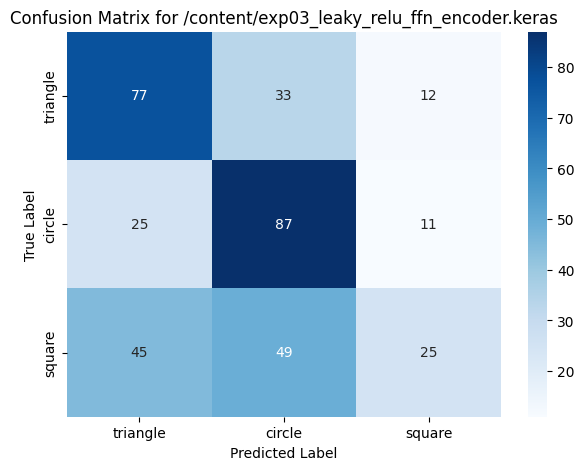

In [ ]:
# @title  Validate Model (Corrected & Self-Contained)
#
# This script loads a saved encoder, matches EEG to images, and calculates
# the overall accuracy on the entire test set. It is now self-contained.

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# --- HELPER FUNCTION (Previously in shared_utils.py) ---
def L2Normalization(x):
    """A named function for L2 normalization for safe model saving."""
    return tf.math.l2_normalize(x, axis=1)

# --- ⬇️ CONFIGURATION FOR VALIDATION ⬇️ ---
# ⚠️ Update these two variables before running!
MODEL_FILENAME = '/content/exp03_leaky_relu_ffn_encoder.keras' # e.g., 'exp02_wider_ffn_encoder.keras'
DATA_TYPE = 'features' # Can be 'features' or 'timeseries'
# --- ⬆️ CONFIGURATION FOR VALIDATION ⬆️ ---

print(f"--- Validating Model: {MODEL_FILENAME} ---")

# 1. Load packaged data from the setup script
try:
    with open('all_data.pkl', 'rb') as f:
        all_data = pickle.load(f)
    clip_embeddings = all_data['clip_embeddings']
except FileNotFoundError:
    raise SystemExit("❌ ERROR: 'all_data.pkl' not found. Please run the '00_setup.py' script first.")

# 2. Load the specific encoder model
try:
    encoder = tf.keras.models.load_model(MODEL_FILENAME, custom_objects={'L2Normalization': L2Normalization})
    print("✅ Encoder model loaded successfully.")
except Exception as e:
     raise SystemExit(f"❌ ERROR: Could not load the model. Make sure '{MODEL_FILENAME}' exists. Error details: {e}")

# 3. Prepare the correct dataset for testing
if DATA_TYPE == 'features':
    num_samples, num_channels, num_features_per_channel = all_data['X_raw'].shape
    X_reshaped = all_data['X_raw'].reshape(num_samples, num_channels * num_features_per_channel)
    scaler = StandardScaler()
    X_full_data = scaler.fit_transform(X_reshaped)
    y_full_data = all_data['y_raw']
elif DATA_TYPE == 'timeseries':
    X_full_data = all_data['X_timeseries']
    y_full_data = all_data['y_timeseries_str']
else:
    raise ValueError("DATA_TYPE must be 'features' or 'timeseries'")

# Create a consistent test split
_, X_test, _, y_test = train_test_split(X_full_data, y_full_data, test_size=0.2, random_state=42, stratify=y_full_data)
print(f"✅ Prepared {len(X_test)} test samples.")

# 4. Generate Embeddings and Make Predictions
predicted_eeg_embeddings = encoder.predict(X_test)
class_labels = list(clip_embeddings.keys())
clip_matrix = np.vstack([clip_embeddings[label] for label in class_labels])
similarities = cosine_similarity(predicted_eeg_embeddings, clip_matrix)
pred_indices = np.argmax(similarities, axis=1)
pred_labels = [class_labels[i] for i in pred_indices]

# 5. Display Results
accuracy = accuracy_score(y_test, pred_labels)
print(f"\n--- OVERALL PERFORMANCE ON TEST SET ---")
print(f"✅ Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, pred_labels, labels=class_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Confusion Matrix for {MODEL_FILENAME}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



# t-SNE for Leaky ReLU FFN

✅ Leaky ReLU FFN encoder loaded
🔄 Generating EEG embeddings...
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
🔄 Running t-SNE...


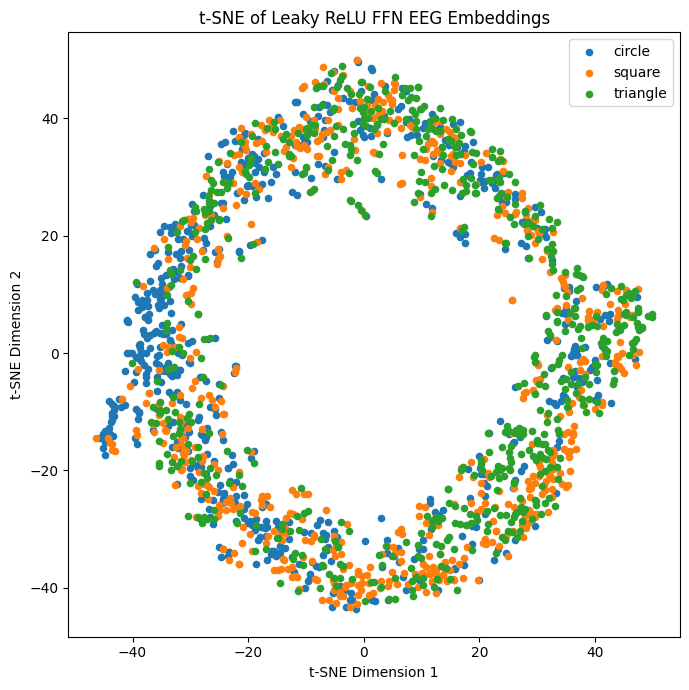

In [ ]:
# ============================================================
# t-SNE Visualization – Leaky ReLU FFN (Experiment 03)
# Matched with TriFusion & other FFN variants
# ============================================================

import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ---------- Helper ----------
def L2Normalization(x):
    return tf.math.l2_normalize(x, axis=1)

# ---------- Load trained encoder ----------
ENCODER_PATH = "exp03_leaky_relu_ffn_encoder.keras"
encoder = tf.keras.models.load_model(
    ENCODER_PATH,
    custom_objects={"L2Normalization": L2Normalization}
)
print("✅ Leaky ReLU FFN encoder loaded")

# ---------- Load data ----------
with open("all_data.pkl", "rb") as f:
    all_data = pickle.load(f)

X_raw = all_data["X_raw"]
y_raw = all_data["y_raw"]
unique_labels = sorted(list(set(y_raw)))

# ---------- Prepare EEG features ----------
num_samples, num_channels, num_features = X_raw.shape
X_flat = X_raw.reshape(num_samples, num_channels * num_features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

# ---------- Generate EEG embeddings ----------
print("🔄 Generating EEG embeddings...")
Z = encoder.predict(X_scaled, batch_size=64)

# ---------- t-SNE ----------
print("🔄 Running t-SNE...")
ts = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="pca",
    random_state=42
)
Z2 = ts.fit_transform(Z)

# ---------- Plot (EXACT SAME STYLE AS TRIFUSION) ----------
plt.figure(figsize=(7, 7))

for lab in unique_labels:
    idx = np.where(np.array(y_raw) == lab)[0]
    plt.scatter(
        Z2[idx, 0],
        Z2[idx, 1],
        s=20,
        label=lab
    )

plt.legend()
plt.title("t-SNE of Leaky ReLU FFN EEG Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()


In [ ]:
# @title  Run Experiment 04 - 1D-CNN on Pre-computed Features
#
# This script uses a 1D Convolutional Neural Network on the 40-feature vectors,
# treating them as a short sequence to find local patterns.

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda, GaussianNoise, Reshape, Conv1D, BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
import pickle
import os

# --- HELPER FUNCTIONS (to make script self-contained) ---
def L2Normalization(x):
    """A named function for L2 normalization for safe model saving."""
    return tf.math.l2_normalize(x, axis=1)

def triplet_loss(y_true, y_pred, alpha=0.4):
    """The Triplet Loss function."""
    embedding_dim = tf.shape(y_pred)[1] // 3
    anchor, pos, neg = y_pred[:, :embedding_dim], y_pred[:, embedding_dim:embedding_dim*2], y_pred[:, embedding_dim*2:]
    pos_dist = tf.reduce_sum(tf.square(anchor - pos), axis=1)
    neg_dist = tf.reduce_sum(tf.square(anchor - neg), axis=1)
    loss = tf.reduce_mean(tf.maximum(pos_dist - neg_dist + alpha, 0.0))
    return loss

def create_triplets(X_features, y_labels_str, clip_embeds):
    """Creates anchor, positive, and negative samples for training."""
    x_anchor, x_positive, x_negative = [], [], []
    classes = list(clip_embeds.keys())
    for i in range(len(X_features)):
        anchor_eeg, true_label_name = X_features[i], y_labels_str[i]
        positive_clip = clip_embeds[true_label_name]
        negative_label_name = np.random.choice([c for c in classes if c != true_label_name])
        negative_clip = clip_embeds[negative_label_name]
        x_anchor.append(anchor_eeg)
        x_positive.append(positive_clip)
        x_negative.append(negative_clip)
    return np.array(x_anchor), np.array(x_positive), np.array(x_negative)

# --- 1. SETUP ---
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(42)
np.random.seed(42)

# --- 2. LOAD & PREPARE DATA ---
print("--- Loading and Preparing Data for Experiment 04 ---")
with open('all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)
X_raw, y_raw, clip_embeddings = all_data['X_raw'], all_data['y_raw'], all_data['clip_embeddings']

# Scale the pre-computed features
num_samples, num_channels, num_features = X_raw.shape
X_reshaped = X_raw.reshape(num_samples, num_channels * num_features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped)
print(f"✅ Data prepared and scaled. Shape: {X_scaled.shape}")

# --- 3. BUILD THE 1D-CNN ENCODER MODEL ---
def build_feature_cnn_encoder(input_shape, embedding_dim):
    """Builds a 1D-CNN encoder for pre-computed features."""
    eeg_input = Input(shape=input_shape, name="eeg_input")
    # Reshape flat input (40,) to a sequence (40, 1) for Conv1D
    x = Reshape((input_shape[0], 1))(eeg_input)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Conv1D(filters=128, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    # Use Global Average Pooling to summarize the features
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(embedding_dim, activation=None)(x)
    x = Lambda(L2Normalization, name="L2Normalization")(x)
    return Model(inputs=eeg_input, outputs=x, name="EEG_Encoder_Feature_CNN")

EEG_FEATURE_SHAPE = (X_scaled.shape[1],)
EMBEDDING_DIM = 512
encoder = build_feature_cnn_encoder(EEG_FEATURE_SHAPE, EMBEDDING_DIM)
print("\n--- Model Architecture ---")
encoder.summary()

# --- 4. CREATE TRIPLETS & COMPILE FULL MODEL ---
anchor, positive, negative = create_triplets(X_scaled, y_raw, clip_embeddings)
anchor_input, pos_input, neg_input = Input(shape=EEG_FEATURE_SHAPE), Input(shape=(EMBEDDING_DIM,)), Input(shape=(EMBEDDING_DIM,))
eeg_embedding = encoder(anchor_input)
merged_output = tf.keras.layers.concatenate([eeg_embedding, pos_input, neg_input], axis=1)
training_model = Model(inputs=[anchor_input, pos_input, neg_input], outputs=merged_output)
training_model.compile(optimizer=Adam(learning_rate=0.0001), loss=triplet_loss)

# --- 5. TRAIN THE ENCODER ---
early_stopping = EarlyStopping(monitor='val_loss', patience=25, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6, verbose=1)

print("\n🚀 Starting training for Experiment 04...")
training_model.fit(
    [anchor, positive, negative], np.zeros((anchor.shape[0], 1)),
    epochs=200, batch_size=32, validation_split=0.2,
    callbacks=[early_stopping, reduce_lr], verbose=1
)
print("\n✅ Training complete!")

# --- 6. SAVE THE TRAINED ENCODER ---
encoder_filename = 'exp04_feature_cnn_encoder.keras'
encoder.save(encoder_filename)
print(f"\n✅ Trained encoder saved to '{encoder_filename}'")



--- Loading and Preparing Data for Experiment 04 ---
✅ Data prepared and scaled. Shape: (1820, 40)

--- Model Architecture ---


Model: "EEG_Encoder_Feature_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)          │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 40, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 40, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 40, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 40, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2Normalization (Lambda)        │ (None, 512)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 190,336 (743.50 KB)

 Trainable params: 189,952 (742.00 KB)

 Non-trainable params: 384 (1.50 KB)


🚀 Starting training for Experiment 04...
Epoch 1/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.4853 - val_loss: 0.5010 - learning_rate: 1.0000e-04
Epoch 2/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4737 - val_loss: 0.5120 - learning_rate: 1.0000e-04
Epoch 3/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4657 - val_loss: 0.5242 - learning_rate: 1.0000e-04
Epoch 4/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4556 - val_loss: 0.5379 - learning_rate: 1.0000e-04
Epoch 5/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4473 - val_loss: 0.5528 - learning_rate: 1.0000e-04
Epoch 6/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4413 - val_loss: 0.5632 - learning_rate: 1.0000e-04
Epoch 7/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4356 - val_loss: 0.5704 - learning_rate: 1.0000e-04
Epoch 8/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4314 - val_loss: 0.5737 - learning_rate: 1.0000e-04
Epoch 9/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


--- Validating Model: /content/exp04_feature_cnn_encoder.keras ---
✅ Encoder model loaded successfully.
✅ Test samples: 364
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step

--- OVERALL PERFORMANCE ON TEST SET ---
Accuracy  (%) : 32.14
Precision (%) : 14.97
Recall    (%) : 31.71
F1-score  (%) : 17.27


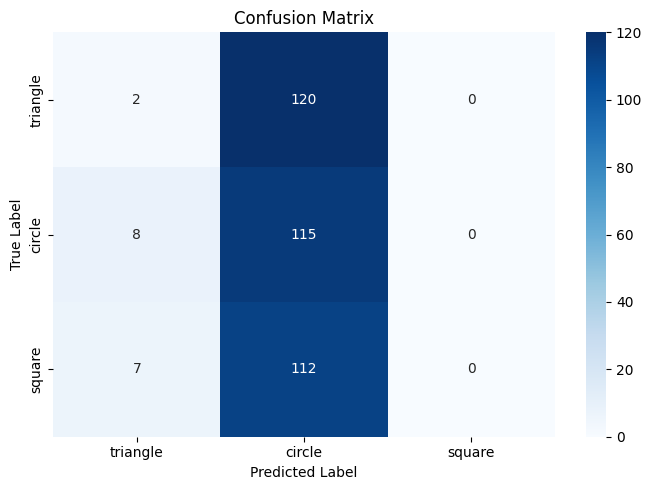

In [ ]:
# @title Validate Model (FINAL – Paper-Style Overall Metrics)
#
# This script validates a trained EEG encoder by matching EEG embeddings
# with CLIP image embeddings and reports overall Accuracy, Precision,
# Recall, and F1-score (single value each, macro-averaged).

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# -------------------------------------------------------
# Helper Function
# -------------------------------------------------------
def L2Normalization(x):
    """L2 normalization layer used during training."""
    return tf.math.l2_normalize(x, axis=1)

# -------------------------------------------------------
# Configuration
# -------------------------------------------------------
MODEL_FILENAME = '/content/exp04_feature_cnn_encoder.keras'
DATA_TYPE = 'features'  # 'features' or 'timeseries'

print(f"\n--- Validating Model: {MODEL_FILENAME} ---")

# -------------------------------------------------------
# Load Data
# -------------------------------------------------------
try:
    with open('all_data.pkl', 'rb') as f:
        all_data = pickle.load(f)
    clip_embeddings = all_data['clip_embeddings']
except FileNotFoundError:
    raise SystemExit("❌ ERROR: 'all_data.pkl' not found. Run setup script first.")

# -------------------------------------------------------
# Load Encoder Model
# -------------------------------------------------------
try:
    encoder = tf.keras.models.load_model(
        MODEL_FILENAME,
        custom_objects={'L2Normalization': L2Normalization}
    )
    print("✅ Encoder model loaded successfully.")
except Exception as e:
    raise SystemExit(f"❌ ERROR loading model: {e}")

# -------------------------------------------------------
# Prepare Dataset
# -------------------------------------------------------
if DATA_TYPE == 'features':
    num_samples, num_channels, num_features = all_data['X_raw'].shape
    X_reshaped = all_data['X_raw'].reshape(num_samples, num_channels * num_features)

    scaler = StandardScaler()
    X_full = scaler.fit_transform(X_reshaped)
    y_full = all_data['y_raw']

elif DATA_TYPE == 'timeseries':
    X_full = all_data['X_timeseries']
    y_full = all_data['y_timeseries_str']

else:
    raise ValueError("DATA_TYPE must be 'features' or 'timeseries'")

# -------------------------------------------------------
# Train–Test Split
# -------------------------------------------------------
_, X_test, _, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

print(f"✅ Test samples: {len(X_test)}")

# -------------------------------------------------------
# Generate Predictions
# -------------------------------------------------------
eeg_embeddings = encoder.predict(X_test)

class_labels = list(clip_embeddings.keys())
clip_matrix = np.vstack([clip_embeddings[label] for label in class_labels])

similarity_matrix = cosine_similarity(eeg_embeddings, clip_matrix)
pred_indices = np.argmax(similarity_matrix, axis=1)
pred_labels = [class_labels[i] for i in pred_indices]

# -------------------------------------------------------
# Overall Evaluation Metrics (Single Value Each)
# -------------------------------------------------------
accuracy = accuracy_score(y_test, pred_labels)
precision = precision_score(y_test, pred_labels, average='macro', zero_division=0)
recall = recall_score(y_test, pred_labels, average='macro', zero_division=0)
f1 = f1_score(y_test, pred_labels, average='macro', zero_division=0)

print("\n--- OVERALL PERFORMANCE ON TEST SET ---")
print(f"Accuracy  (%) : {accuracy * 100:.2f}")
print(f"Precision (%) : {precision * 100:.2f}")
print(f"Recall    (%) : {recall * 100:.2f}")
print(f"F1-score  (%) : {f1 * 100:.2f}")

# -------------------------------------------------------
# Confusion Matrix
# -------------------------------------------------------
cm = confusion_matrix(y_test, pred_labels, labels=class_labels)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


# t-SNE for Leaky ReLU

✅ Feature-CNN encoder loaded
🔄 Generating EEG embeddings...
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
🔄 Running t-SNE...


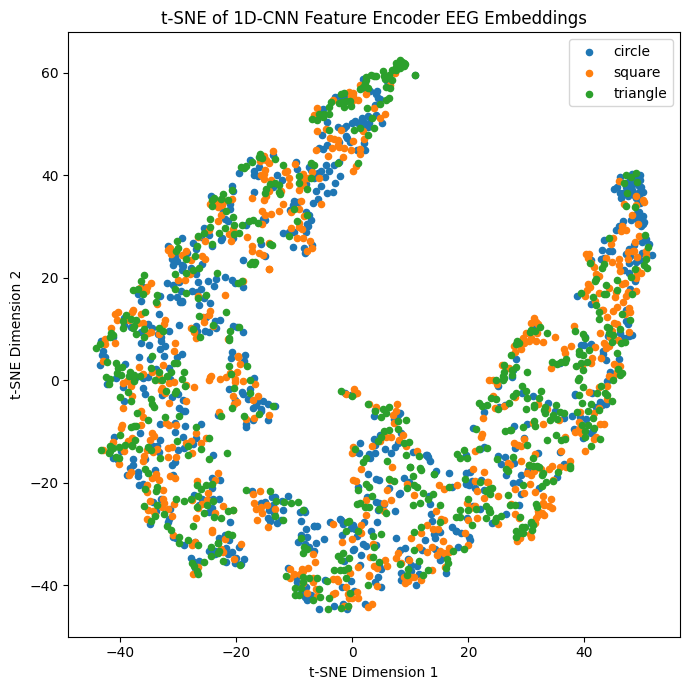

In [ ]:
# ============================================================
# t-SNE Visualization – 1D-CNN on Pre-computed Features (Exp 04)
# Matched with TriFusion & FFN variants colour scheme
# ============================================================

import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ---------- Helper ----------
def L2Normalization(x):
    return tf.math.l2_normalize(x, axis=1)

# ---------- Load trained encoder ----------
ENCODER_PATH = "exp04_feature_cnn_encoder.keras"
encoder = tf.keras.models.load_model(
    ENCODER_PATH,
    custom_objects={"L2Normalization": L2Normalization}
)
print("✅ Feature-CNN encoder loaded")

# ---------- Load data ----------
with open("all_data.pkl", "rb") as f:
    all_data = pickle.load(f)

X_raw = all_data["X_raw"]
y_raw = all_data["y_raw"]
unique_labels = sorted(list(set(y_raw)))

# ---------- Prepare EEG features ----------
num_samples, num_channels, num_features = X_raw.shape
X_flat = X_raw.reshape(num_samples, num_channels * num_features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

# ---------- Generate EEG embeddings ----------
print("🔄 Generating EEG embeddings...")
Z = encoder.predict(X_scaled, batch_size=64)

# ---------- t-SNE ----------
print("🔄 Running t-SNE...")
ts = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="pca",
    random_state=42
)
Z2 = ts.fit_transform(Z)

# ---------- Plot (EXACT SAME STYLE AS TRIFUSION) ----------
plt.figure(figsize=(7, 7))

for lab in unique_labels:
    idx = np.where(np.array(y_raw) == lab)[0]
    plt.scatter(
        Z2[idx, 0],
        Z2[idx, 1],
        s=20,
        label=lab
    )

plt.legend()
plt.title("t-SNE of 1D-CNN Feature Encoder EEG Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()


In [ ]:
# @title Run Experiment 05 - 1D-CNN with Attention on Features
#
# This script adds a self-attention mechanism after the CNN layers to allow
# the model to weigh the importance of the features extracted by the convolutions.

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda, Reshape, Conv1D, MaxPooling1D, Flatten, MultiHeadAttention
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
import pickle
import os

# --- HELPER FUNCTIONS (to make script self-contained) ---
def L2Normalization(x):
    """A named function for L2 normalization for safe model saving."""
    return tf.math.l2_normalize(x, axis=1)

def triplet_loss(y_true, y_pred, alpha=0.4):
    """The Triplet Loss function."""
    embedding_dim = tf.shape(y_pred)[1] // 3
    anchor, pos, neg = y_pred[:, :embedding_dim], y_pred[:, embedding_dim:embedding_dim*2], y_pred[:, embedding_dim*2:]
    pos_dist = tf.reduce_sum(tf.square(anchor - pos), axis=1)
    neg_dist = tf.reduce_sum(tf.square(anchor - neg), axis=1)
    loss = tf.reduce_mean(tf.maximum(pos_dist - neg_dist + alpha, 0.0))
    return loss

def create_triplets(X_features, y_labels_str, clip_embeds):
    """Creates anchor, positive, and negative samples for training."""
    x_anchor, x_positive, x_negative = [], [], []
    classes = list(clip_embeds.keys())
    for i in range(len(X_features)):
        anchor_eeg, true_label_name = X_features[i], y_labels_str[i]
        positive_clip = clip_embeds[true_label_name]
        negative_label_name = np.random.choice([c for c in classes if c != true_label_name])
        negative_clip = clip_embeds[negative_label_name]
        x_anchor.append(anchor_eeg)
        x_positive.append(positive_clip)
        x_negative.append(negative_clip)
    return np.array(x_anchor), np.array(x_positive), np.array(x_negative)

# --- 1. SETUP ---
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(42)
np.random.seed(42)

# --- 2. LOAD & PREPARE DATA ---
print("--- Loading and Preparing Data for Experiment 05 ---")
with open('all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)
X_raw, y_raw, clip_embeddings = all_data['X_raw'], all_data['y_raw'], all_data['clip_embeddings']

# Scale the pre-computed features
num_samples, num_channels, num_features = X_raw.shape
X_reshaped = X_raw.reshape(num_samples, num_channels * num_features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped)
print(f"✅ Data prepared and scaled. Shape: {X_scaled.shape}")

# --- 3. BUILD THE CNN + ATTENTION ENCODER MODEL ---
def build_feature_cnn_attention_encoder(input_shape, embedding_dim):
    """Builds a 1D-CNN with a self-attention layer."""
    eeg_input = Input(shape=input_shape, name="eeg_input")
    # Reshape flat input (40,) to a sequence (40, 1)
    x = Reshape((input_shape[0], 1))(eeg_input)
    # Feature extraction with convolutions
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
    x = MaxPooling1D(pool_size=2)(x)
    # Self-attention layer. Query, Value, and Key are all the same.
    attn_output = MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
    x = Flatten()(attn_output)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(embedding_dim, activation=None)(x)
    x = Lambda(L2Normalization, name="L2Normalization")(x)
    return Model(inputs=eeg_input, outputs=x, name="EEG_Encoder_CNN_Attention")

EEG_FEATURE_SHAPE = (X_scaled.shape[1],)
EMBEDDING_DIM = 512
encoder = build_feature_cnn_attention_encoder(EEG_FEATURE_SHAPE, EMBEDDING_DIM)
print("\n--- Model Architecture ---")
encoder.summary()

# --- 4. CREATE TRIPLETS & COMPILE FULL MODEL ---
anchor, positive, negative = create_triplets(X_scaled, y_raw, clip_embeddings)
anchor_input, pos_input, neg_input = Input(shape=EEG_FEATURE_SHAPE), Input(shape=(EMBEDDING_DIM,)), Input(shape=(EMBEDDING_DIM,))
eeg_embedding = encoder(anchor_input)
merged_output = tf.keras.layers.concatenate([eeg_embedding, pos_input, neg_input], axis=1)
training_model = Model(inputs=[anchor_input, pos_input, neg_input], outputs=merged_output)
training_model.compile(optimizer=Adam(learning_rate=0.0001), loss=triplet_loss)

# --- 5. TRAIN THE ENCODER ---
early_stopping = EarlyStopping(monitor='val_loss', patience=25, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6, verbose=1)

print("\n🚀 Starting training for Experiment 05...")
training_model.fit(
    [anchor, positive, negative], np.zeros((anchor.shape[0], 1)),
    epochs=200, batch_size=32, validation_split=0.2,
    callbacks=[early_stopping, reduce_lr], verbose=1
)
print("\n✅ Training complete!")

# --- 6. SAVE THE TRAINED ENCODER ---
encoder_filename = 'exp05_feature_cnn_attention_encoder.keras'
encoder.save(encoder_filename)
print(f"\n✅ Trained encoder saved to '{encoder_filename}'")



--- Loading and Preparing Data for Experiment 05 ---
✅ Data prepared and scaled. Shape: (1820, 40)

--- Model Architecture ---


Model: "EEG_Encoder_CNN_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ eeg_input           │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 40, 1)     │          0 │ eeg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 40, 64)    │        256 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 20, 64)    │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 64)    │     66,368 │ max_pooling1d[0]… │
│ (MultiHeadAttentio… │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1280)      │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 128)       │    163,968 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 128)       │          0 │ dense_13[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 512)       │     66,048 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ L2Normalization     │ (None, 512)       │          0 │ dense_14[0][0]    │
│ (Lambda)            │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 296,640 (1.13 MB)

 Trainable params: 296,640 (1.13 MB)

 Non-trainable params: 0 (0.00 B)


🚀 Starting training for Experiment 05...
Epoch 1/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.3977 - val_loss: 0.4476 - learning_rate: 1.0000e-04
Epoch 2/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3823 - val_loss: 0.4935 - learning_rate: 1.0000e-04
Epoch 3/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3742 - val_loss: 0.5000 - learning_rate: 1.0000e-04
Epoch 4/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3731 - val_loss: 0.5006 - learning_rate: 1.0000e-04
Epoch 5/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3704 - val_loss: 0.4975 - learning_rate: 1.0000e-04
Epoch 6/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3705 - val_loss: 0.4959 - learning_rate: 1.0000e-04
Epoch 7/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3727 - val_loss: 0.4998 - learning_rate: 1.0000e-04
Epoch 8/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3691 - val_loss: 0.4959 - learning_rate: 1.0000e-04
Epoch 9/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - 


--- Validating exp05_feature_cnn_attention_encoder.keras ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

--- PERFORMANCE ---
Accuracy  (%) : 33.79
Precision (%) : 11.26
Recall    (%) : 33.33
F1-score  (%) : 16.84


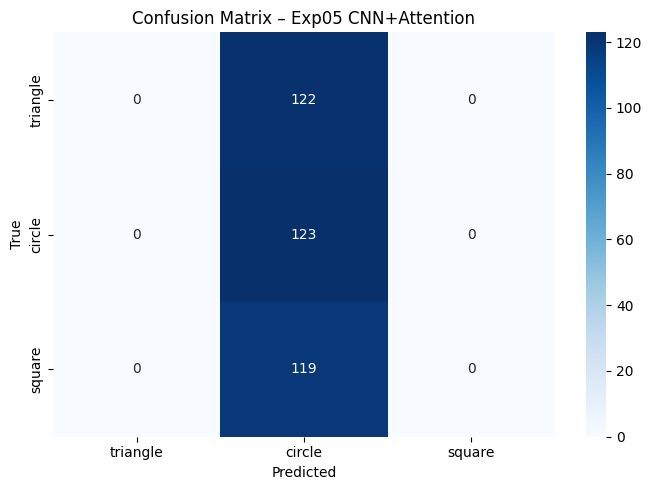

In [ ]:
# Validate Experiment 05 – CNN + Attention Encoder
# Reports Accuracy, Precision, Recall, F1-score (macro)

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# -------------------------------
# Helper
# -------------------------------
def L2Normalization(x):
    return tf.math.l2_normalize(x, axis=1)

# -------------------------------
# Config
# -------------------------------
ENCODER_FILENAME = 'exp05_feature_cnn_attention_encoder.keras'
DATA_TYPE = 'features'

print(f"\n--- Validating {ENCODER_FILENAME} ---")

# -------------------------------
# Load data
# -------------------------------
with open('all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)

X_raw = all_data['X_raw']
y = all_data['y_raw']
clip_embeddings = all_data['clip_embeddings']

# -------------------------------
# Prepare features
# -------------------------------
n, c, f = X_raw.shape
X = X_raw.reshape(n, c * f)
X = StandardScaler().fit_transform(X)

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# Load encoder
# -------------------------------
encoder = tf.keras.models.load_model(
    ENCODER_FILENAME,
    custom_objects={'L2Normalization': L2Normalization}
)

# -------------------------------
# Predict
# -------------------------------
eeg_embeddings = encoder.predict(X_test)

class_labels = list(clip_embeddings.keys())
clip_matrix = np.vstack([clip_embeddings[c] for c in class_labels])

similarity = cosine_similarity(eeg_embeddings, clip_matrix)
pred_indices = np.argmax(similarity, axis=1)
pred_labels = [class_labels[i] for i in pred_indices]

# -------------------------------
# Metrics (MACRO)
# -------------------------------
acc = accuracy_score(y_test, pred_labels)
prec = precision_score(y_test, pred_labels, average='macro', zero_division=0)
rec = recall_score(y_test, pred_labels, average='macro', zero_division=0)
f1 = f1_score(y_test, pred_labels, average='macro', zero_division=0)

print("\n--- PERFORMANCE ---")
print(f"Accuracy  (%) : {acc*100:.2f}")
print(f"Precision (%) : {prec*100:.2f}")
print(f"Recall    (%) : {rec*100:.2f}")
print(f"F1-score  (%) : {f1*100:.2f}")

# -------------------------------
# Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test, pred_labels, labels=class_labels)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Exp05 CNN+Attention")
plt.tight_layout()
plt.show()


# t-SNE for 1D-CNN+Attention

✅ CNN + Attention encoder loaded
🔄 Generating EEG embeddings...
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
🔄 Running t-SNE...


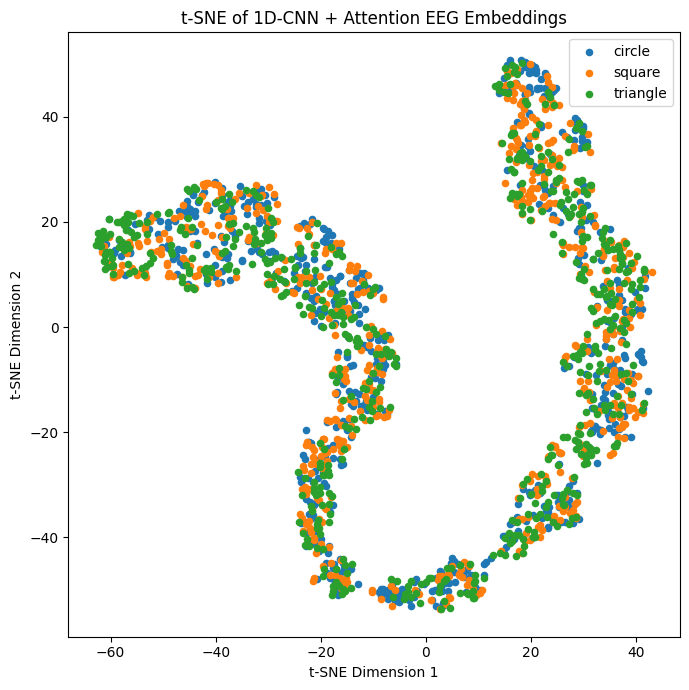

In [ ]:
# ============================================================
# t-SNE Visualization – 1D-CNN with Attention on Features (Exp 05)
# Matched with TriFusion & other baseline encoders
# ============================================================

import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ---------- Helper ----------
def L2Normalization(x):
    return tf.math.l2_normalize(x, axis=1)

# ---------- Load trained encoder ----------
ENCODER_PATH = "exp05_feature_cnn_attention_encoder.keras"
encoder = tf.keras.models.load_model(
    ENCODER_PATH,
    custom_objects={"L2Normalization": L2Normalization}
)
print("✅ CNN + Attention encoder loaded")

# ---------- Load data ----------
with open("all_data.pkl", "rb") as f:
    all_data = pickle.load(f)

X_raw = all_data["X_raw"]
y_raw = all_data["y_raw"]
unique_labels = sorted(list(set(y_raw)))

# ---------- Prepare EEG features ----------
num_samples, num_channels, num_features = X_raw.shape
X_flat = X_raw.reshape(num_samples, num_channels * num_features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

# ---------- Generate EEG embeddings ----------
print("🔄 Generating EEG embeddings...")
Z = encoder.predict(X_scaled, batch_size=64)

# ---------- t-SNE ----------
print("🔄 Running t-SNE...")
ts = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="pca",
    random_state=42
)
Z2 = ts.fit_transform(Z)

# ---------- Plot (EXACT SAME STYLE AS TRIFUSION) ----------
plt.figure(figsize=(7, 7))

for lab in unique_labels:
    idx = np.where(np.array(y_raw) == lab)[0]
    plt.scatter(
        Z2[idx, 0],
        Z2[idx, 1],
        s=20,
        label=lab
    )

plt.legend()
plt.title("t-SNE of 1D-CNN + Attention EEG Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()


In [ ]:
# @title  Run Experiment 06 - Denoising Autoencoder
#
# This script improves upon the basic autoencoder by training a denoising
# version. It adds noise to the input and trains the model to reconstruct the
# original, clean data, forcing it to learn more robust features.

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GaussianNoise, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pickle
import os

# --- 1. SETUP ---
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(42)
np.random.seed(42)

# --- 2. LOAD & PREPARE DATA ---
print("--- Loading and Preparing Data for Experiment 06b ---")
with open('all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)
X_raw = all_data['X_raw']

# Scale the pre-computed features
num_samples, num_channels, num_features = X_raw.shape
X_reshaped = X_raw.reshape(num_samples, num_channels * num_features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped)
print(f"✅ Data prepared and scaled. Shape: {X_scaled.shape}")

# Split data for autoencoder training
X_train_ae, X_test_ae = train_test_split(X_scaled, test_size=0.2, random_state=42)

# --- 3. BUILD THE DENOISING AUTOENCODER MODEL ---
INPUT_DIM = X_scaled.shape[1]
BOTTLENECK_DIM = 32

input_layer = Input(shape=(INPUT_DIM,), name="encoder_input")

# **NEW**: Add a noise layer to the input for the denoising process
noisy_input = GaussianNoise(0.2)(input_layer)

# Encoder part (now learns from the noisy input)
encoded = Dense(128, activation='relu')(noisy_input)
encoded = BatchNormalization()(encoded)
encoded = Dense(64, activation='relu')(encoded)
bottleneck = Dense(BOTTLENECK_DIM, activation='relu', name="bottleneck_embedding")(encoded)

# Decoder part
decoded = Dense(64, activation='relu')(bottleneck)
decoded = Dense(128, activation='relu')(decoded)
reconstruction = Dense(INPUT_DIM, activation='linear')(decoded) # Linear activation for reconstruction

# Full autoencoder model (for training)
autoencoder = Model(inputs=input_layer, outputs=reconstruction, name="Denoising_Autoencoder")
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# Separate encoder model (for getting the embeddings from clean data)
encoder = Model(inputs=input_layer, outputs=bottleneck, name="Encoder")

print("\n--- Denoising Autoencoder Architecture ---")
autoencoder.summary()

# --- 4. TRAIN THE DENOISING AUTOENCODER ---
print("\n🚀 Starting training for Experiment 06b...")
autoencoder.fit(
    # The model sees the clean data as BOTH the input and the target...
    X_train_ae, X_train_ae,
    # ...but the GaussianNoise layer adds noise to the input automatically during training.
    epochs=150, # Increased epochs for potentially harder task
    batch_size=32,
    validation_data=(X_test_ae, X_test_ae),
    callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)],
    verbose=1
)
print("\n✅ Training complete!")

# --- 5. SAVE THE TRAINED ENCODER PART ---
encoder_filename = 'exp06b_denoising_autoencoder_encoder.keras'
encoder.save(encoder_filename)
print(f"\n✅ Trained encoder saved to '{encoder_filename}'")
print("\nNow, run the 'validate_autoencoder.py' script and set the ENCODER_FILENAME to this new file to check its accuracy.")


--- Loading and Preparing Data for Experiment 06b ---
✅ Data prepared and scaled. Shape: (1820, 40)

--- Denoising Autoencoder Architecture ---


Model: "Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_3                │ (None, 40)             │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck_embedding (Dense)    │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 40)             │         5,160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,688 (123.78 KB)

 Trainable params: 31,432 (122.78 KB)

 Non-trainable params: 256 (1.00 KB)


🚀 Starting training for Experiment 06b...
Epoch 1/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.9105 - val_loss: 0.6102
Epoch 2/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4749 - val_loss: 0.4394
Epoch 3/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3418 - val_loss: 0.3461
Epoch 4/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2867 - val_loss: 0.2974
Epoch 5/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2542 - val_loss: 0.2595
Epoch 6/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2312 - val_loss: 0.2327
Epoch 7/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2132 - val_loss: 0.2159
Epoch 8/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1983 - val_loss: 0.2006
Epoch 9/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1859 - val_loss: 0.1910
Epoch 10/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1752 - val_loss: 0.1827
Epoch 11/150
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1668 - val_loss: 0.1740
Epoch 12/150
46/46 


--- Validating exp06b_denoising_autoencoder_encoder.keras ---
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

--- PERFORMANCE ---
Accuracy  (%) : 30.77
Precision (%) : 31.40
Recall    (%) : 30.70
F1-score  (%) : 30.60


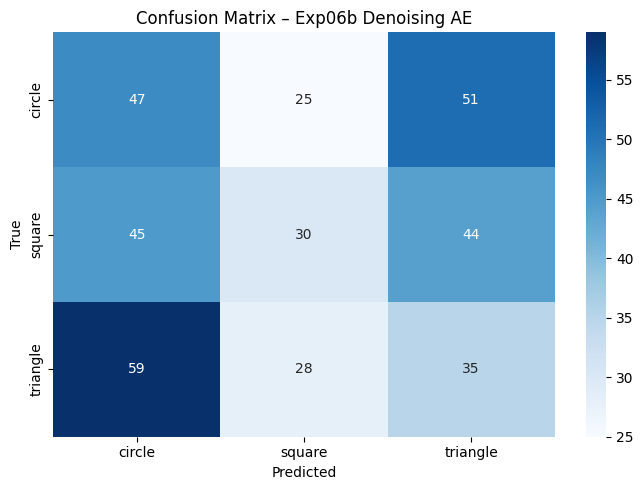

In [ ]:
# Validate Experiment 06b – Denoising Autoencoder Encoder
# Uses nearest-class centroid classification
# Reports Accuracy, Precision, Recall, F1-score (macro)

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# -------------------------------
# Config
# -------------------------------
ENCODER_FILENAME = 'exp06b_denoising_autoencoder_encoder.keras'

print(f"\n--- Validating {ENCODER_FILENAME} ---")

# -------------------------------
# Load data
# -------------------------------
with open('all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)

X_raw = all_data['X_raw']
y = all_data['y_raw']

# -------------------------------
# Prepare features
# -------------------------------
n, c, f = X_raw.shape
X = X_raw.reshape(n, c * f)
X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# Load encoder
# -------------------------------
encoder = tf.keras.models.load_model(ENCODER_FILENAME)

# -------------------------------
# Encode data
# -------------------------------
Z_train = encoder.predict(X_train)
Z_test = encoder.predict(X_test)

# -------------------------------
# Compute class centroids
# -------------------------------
class_labels = np.unique(y_train)
centroids = {}

for cls in class_labels:
    centroids[cls] = np.mean(Z_train[y_train == cls], axis=0)

centroid_matrix = np.vstack([centroids[c] for c in class_labels])

# -------------------------------
# Predict using cosine similarity
# -------------------------------
similarity = cosine_similarity(Z_test, centroid_matrix)
pred_indices = np.argmax(similarity, axis=1)
pred_labels = [class_labels[i] for i in pred_indices]

# -------------------------------
# Metrics (MACRO)
# -------------------------------
acc = accuracy_score(y_test, pred_labels)
prec = precision_score(y_test, pred_labels, average='macro', zero_division=0)
rec = recall_score(y_test, pred_labels, average='macro', zero_division=0)
f1 = f1_score(y_test, pred_labels, average='macro', zero_division=0)

print("\n--- PERFORMANCE ---")
print(f"Accuracy  (%) : {acc*100:.2f}")
print(f"Precision (%) : {prec*100:.2f}")
print(f"Recall    (%) : {rec*100:.2f}")
print(f"F1-score  (%) : {f1*100:.2f}")

# -------------------------------
# Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test, pred_labels, labels=class_labels)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Exp06b Denoising AE")
plt.tight_layout()
plt.show()


# t-SNE for Denoising Autoencoder

✅ Denoising Autoencoder encoder loaded
🔄 Generating bottleneck embeddings...
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
🔄 Running t-SNE...


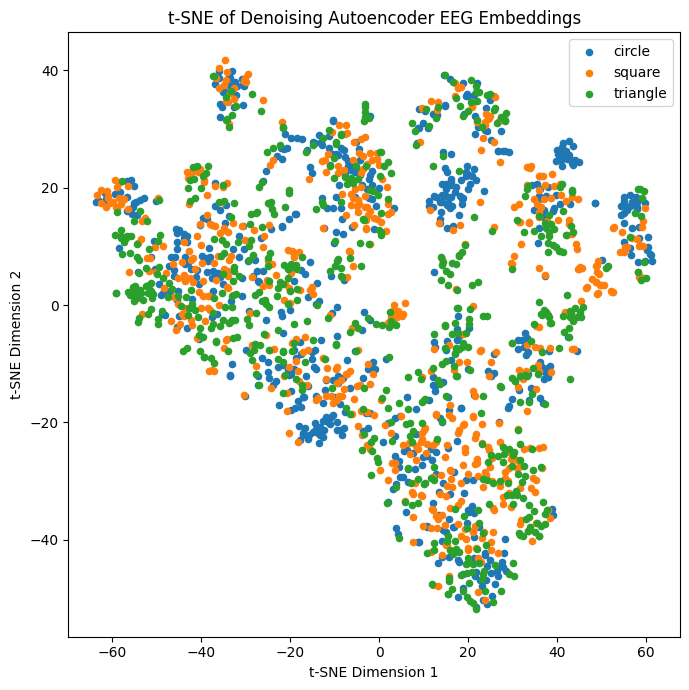

In [ ]:
# ============================================================
# t-SNE Visualization – Denoising Autoencoder (Experiment 06)
# Matched with TriFusion & all baseline encoders
# ============================================================

import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ---------- Load trained encoder ----------
ENCODER_PATH = "exp06b_denoising_autoencoder_encoder.keras"
encoder = tf.keras.models.load_model(ENCODER_PATH)
print("✅ Denoising Autoencoder encoder loaded")

# ---------- Load data ----------
with open("all_data.pkl", "rb") as f:
    all_data = pickle.load(f)

X_raw = all_data["X_raw"]
y_raw = all_data["y_raw"]
unique_labels = sorted(list(set(y_raw)))

# ---------- Prepare EEG features ----------
num_samples, num_channels, num_features = X_raw.shape
X_flat = X_raw.reshape(num_samples, num_channels * num_features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

# ---------- Generate bottleneck embeddings ----------
print("🔄 Generating bottleneck embeddings...")
Z = encoder.predict(X_scaled, batch_size=64)

# ---------- t-SNE ----------
print("🔄 Running t-SNE...")
ts = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="pca",
    random_state=42
)
Z2 = ts.fit_transform(Z)

# ---------- Plot (EXACT SAME STYLE AS TRIFUSION) ----------
plt.figure(figsize=(7, 7))

for lab in unique_labels:
    idx = np.where(np.array(y_raw) == lab)[0]
    plt.scatter(
        Z2[idx, 0],
        Z2[idx, 1],
        s=20,
        label=lab
    )

plt.legend()
plt.title("t-SNE of Denoising Autoencoder EEG Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()


In [ ]:
# @title  Run Experiment 07 - Pure LSTM on Time-Series
#
# This script applies a Long Short-Term Memory (LSTM) network directly to the
# raw, filtered time-series data to learn temporal patterns.

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda, LSTM, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pickle
import os

# --- HELPER FUNCTIONS (to make script self-contained) ---
def L2Normalization(x):
    """A named function for L2 normalization for safe model saving."""
    return tf.math.l2_normalize(x, axis=1)

def triplet_loss(y_true, y_pred, alpha=0.4):
    """The Triplet Loss function."""
    embedding_dim = tf.shape(y_pred)[1] // 3
    anchor, pos, neg = y_pred[:, :embedding_dim], y_pred[:, embedding_dim:embedding_dim*2], y_pred[:, embedding_dim*2:]
    pos_dist = tf.reduce_sum(tf.square(anchor - pos), axis=1)
    neg_dist = tf.reduce_sum(tf.square(anchor - neg), axis=1)
    loss = tf.reduce_mean(tf.maximum(pos_dist - neg_dist + alpha, 0.0))
    return loss

def create_triplets(X_features, y_labels_str, clip_embeds):
    """Creates anchor, positive, and negative samples for training."""
    x_anchor, x_positive, x_negative = [], [], []
    classes = list(clip_embeds.keys())
    for i in range(len(X_features)):
        anchor_eeg, true_label_name = X_features[i], y_labels_str[i]
        positive_clip = clip_embeds[true_label_name]
        negative_label_name = np.random.choice([c for c in classes if c != true_label_name])
        negative_clip = clip_embeds[negative_label_name]
        x_anchor.append(anchor_eeg)
        x_positive.append(positive_clip)
        x_negative.append(negative_clip)
    return np.array(x_anchor), np.array(x_positive), np.array(x_negative)

# --- 1. SETUP ---
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(42)
np.random.seed(42)

# --- 2. LOAD & PREPARE DATA ---
print("--- Loading and Preparing Data for Experiment 07 ---")
with open('all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)
# This model uses the raw time-series data
X_timeseries = all_data['X_timeseries']
y_timeseries_str = all_data['y_timeseries_str']
clip_embeddings = all_data['clip_embeddings']

# Normalize the time-series data for better training
scaler = StandardScaler()
# Reshape for scaling: (samples * timesteps, channels)
X_reshaped = X_timeseries.reshape(-1, X_timeseries.shape[-1])
X_scaled_reshaped = scaler.fit_transform(X_reshaped)
# Reshape back to the original time-series format
X_scaled = X_scaled_reshaped.reshape(X_timeseries.shape)
print(f"✅ Time-series data prepared and scaled. Shape: {X_scaled.shape}")

# --- 3. BUILD THE LSTM ENCODER MODEL ---
def build_pure_lstm_encoder(input_shape, embedding_dim):
    """Builds a pure LSTM encoder for time-series data."""
    eeg_input = Input(shape=input_shape, name="eeg_input")
    x = BatchNormalization()(eeg_input)
    # return_sequences=False returns only the last hidden state of the sequence
    x = LSTM(128, return_sequences=False)(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(embedding_dim, activation=None)(x)
    x = Lambda(L2Normalization, name="L2Normalization")(x)
    return Model(inputs=eeg_input, outputs=x, name="EEG_Encoder_Pure_LSTM")

TIMESERIES_SHAPE = (X_scaled.shape[1], X_scaled.shape[2])
EMBEDDING_DIM = 512
encoder = build_pure_lstm_encoder(TIMESERIES_SHAPE, EMBEDDING_DIM)
print("\n--- Model Architecture ---")
encoder.summary()

# --- 4. CREATE TRIPLETS & COMPILE FULL MODEL ---
anchor, positive, negative = create_triplets(X_scaled, y_timeseries_str, clip_embeddings)
anchor_input, pos_input, neg_input = Input(shape=TIMESERIES_SHAPE), Input(shape=(EMBEDDING_DIM,)), Input(shape=(EMBEDDING_DIM,))
eeg_embedding = encoder(anchor_input)
merged_output = tf.keras.layers.concatenate([eeg_embedding, pos_input, neg_input], axis=1)
training_model = Model(inputs=[anchor_input, pos_input, neg_input], outputs=merged_output)
training_model.compile(optimizer=Adam(learning_rate=0.0001), loss=triplet_loss)

# --- 5. TRAIN THE ENCODER ---
early_stopping = EarlyStopping(monitor='val_loss', patience=25, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6, verbose=1)

print("\n🚀 Starting training for Experiment 07...")
training_model.fit(
    [anchor, positive, negative], np.zeros((anchor.shape[0], 1)),
    epochs=200, batch_size=32, validation_split=0.2,
    callbacks=[early_stopping, reduce_lr], verbose=1
)
print("\n✅ Training complete!")

# --- 6. SAVE THE TRAINED ENCODER ---
encoder_filename = 'exp07_pure_lstm_encoder.keras'
encoder.save(encoder_filename)
print(f"\n✅ Trained encoder saved to '{encoder_filename}'")



--- Loading and Preparing Data for Experiment 07 ---
✅ Time-series data prepared and scaled. Shape: (1969, 375, 2)

--- Model Architecture ---


Model: "EEG_Encoder_Pure_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)          │ (None, 375, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 375, 2)         │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2Normalization (Lambda)        │ (None, 512)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 231,688 (905.03 KB)

 Trainable params: 231,684 (905.02 KB)

 Non-trainable params: 4 (16.00 B)


🚀 Starting training for Experiment 07...
Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.4020 - val_loss: 0.4078 - learning_rate: 1.0000e-04
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.3963 - val_loss: 0.4182 - learning_rate: 1.0000e-04
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.3930 - val_loss: 0.4282 - learning_rate: 1.0000e-04
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.3936 - val_loss: 0.4359 - learning_rate: 1.0000e-04
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.3920 - val_loss: 0.4419 - learning_rate: 1.0000e-04
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.3901 - val_loss: 0.4478 - learning_rate: 1.0000e-04
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.3903 - val_loss: 0.4535 - learning_rate: 1.0000e-04
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.3889 - val_loss: 0.4586 - learning_rate: 1.0000e-04
Epoch 9/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms

--- Validating Model: /content/exp07_pure_lstm_encoder.keras ---
✅ Encoder model loaded successfully.
✅ Prepared 394 test samples.
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 298ms/step

--- OVERALL PERFORMANCE ON TEST SET ---
✅ Accuracy: 33.50%


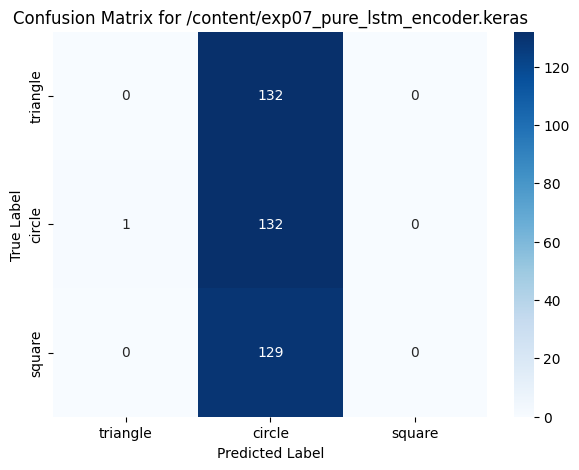

In [ ]:
# @title  Validate Model (Corrected & Self-Contained)
#
# This script loads a saved encoder, matches EEG to images, and calculates
# the overall accuracy on the entire test set. It is now self-contained.

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# --- HELPER FUNCTION (Previously in shared_utils.py) ---
def L2Normalization(x):
    """A named function for L2 normalization for safe model saving."""
    return tf.math.l2_normalize(x, axis=1)

# --- ⬇️ CONFIGURATION FOR VALIDATION ⬇️ ---
# ⚠️ Update these two variables before running!
MODEL_FILENAME = '/content/exp07_pure_lstm_encoder.keras' # e.g., 'exp02_wider_ffn_encoder.keras'
DATA_TYPE = 'timeseries' # Can be 'features' or 'timeseries'
# --- ⬆️ CONFIGURATION FOR VALIDATION ⬆️ ---

print(f"--- Validating Model: {MODEL_FILENAME} ---")

# 1. Load packaged data from the setup script
try:
    with open('all_data.pkl', 'rb') as f:
        all_data = pickle.load(f)
    clip_embeddings = all_data['clip_embeddings']
except FileNotFoundError:
    raise SystemExit("❌ ERROR: 'all_data.pkl' not found. Please run the '00_setup.py' script first.")

# 2. Load the specific encoder model
try:
    encoder = tf.keras.models.load_model(MODEL_FILENAME, custom_objects={'L2Normalization': L2Normalization})
    print("✅ Encoder model loaded successfully.")
except Exception as e:
     raise SystemExit(f"❌ ERROR: Could not load the model. Make sure '{MODEL_FILENAME}' exists. Error details: {e}")

# 3. Prepare the correct dataset for testing
if DATA_TYPE == 'features':
    num_samples, num_channels, num_features_per_channel = all_data['X_raw'].shape
    X_reshaped = all_data['X_raw'].reshape(num_samples, num_channels * num_features_per_channel)
    scaler = StandardScaler()
    X_full_data = scaler.fit_transform(X_reshaped)
    y_full_data = all_data['y_raw']
elif DATA_TYPE == 'timeseries':
    X_full_data = all_data['X_timeseries']
    y_full_data = all_data['y_timeseries_str']
else:
    raise ValueError("DATA_TYPE must be 'features' or 'timeseries'")

# Create a consistent test split
_, X_test, _, y_test = train_test_split(X_full_data, y_full_data, test_size=0.2, random_state=42, stratify=y_full_data)
print(f"✅ Prepared {len(X_test)} test samples.")

# 4. Generate Embeddings and Make Predictions
predicted_eeg_embeddings = encoder.predict(X_test)
class_labels = list(clip_embeddings.keys())
clip_matrix = np.vstack([clip_embeddings[label] for label in class_labels])
similarities = cosine_similarity(predicted_eeg_embeddings, clip_matrix)
pred_indices = np.argmax(similarities, axis=1)
pred_labels = [class_labels[i] for i in pred_indices]

# 5. Display Results
accuracy = accuracy_score(y_test, pred_labels)
print(f"\n--- OVERALL PERFORMANCE ON TEST SET ---")
print(f"✅ Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, pred_labels, labels=class_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Confusion Matrix for {MODEL_FILENAME}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



# t-SNE for LSTM

✅ Pure LSTM encoder loaded
🔄 Generating LSTM embeddings...
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
🔄 Running t-SNE...


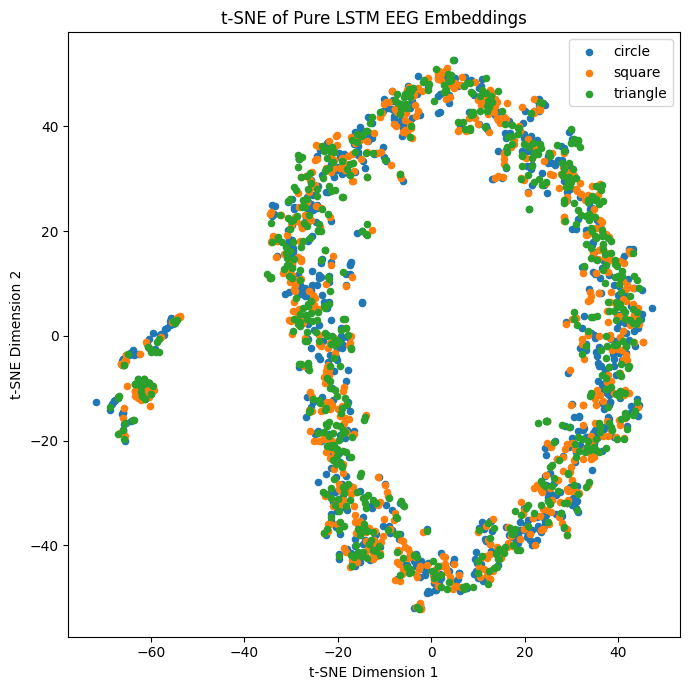

In [ ]:
# ============================================================
# t-SNE Visualization – Pure LSTM EEG Encoder (Experiment 07)
# Matched with all previous models (TriFusion, FFN, CNN, Hybrid)
# ============================================================

import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ---------- Helper ----------
def L2Normalization(x):
    return tf.math.l2_normalize(x, axis=1)

# ---------- Load trained encoder ----------
ENCODER_PATH = "exp07_pure_lstm_encoder.keras"
encoder = tf.keras.models.load_model(
    ENCODER_PATH,
    custom_objects={"L2Normalization": L2Normalization}
)
print("✅ Pure LSTM encoder loaded")

# ---------- Load data ----------
with open("all_data.pkl", "rb") as f:
    all_data = pickle.load(f)

X_timeseries = all_data["X_timeseries"]          # (N, time, channels)
y_raw = all_data["y_timeseries_str"]
unique_labels = sorted(list(set(y_raw)))

# ---------- Scale time-series (same as training) ----------
scaler = StandardScaler()
X_flat = X_timeseries.reshape(-1, X_timeseries.shape[-1])
X_scaled_flat = scaler.fit_transform(X_flat)
X_scaled = X_scaled_flat.reshape(X_timeseries.shape)

# ---------- Generate EEG embeddings ----------
print("🔄 Generating LSTM embeddings...")
Z = encoder.predict(X_scaled, batch_size=32)

# ---------- t-SNE ----------
print("🔄 Running t-SNE...")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="pca",
    random_state=42
)
Z_2d = tsne.fit_transform(Z)

# ---------- Plot (EXACT SAME STYLE AS ALL OTHER FIGURES) ----------
plt.figure(figsize=(7, 7))

for lab in unique_labels:
    idx = np.where(np.array(y_raw) == lab)[0]
    plt.scatter(
        Z_2d[idx, 0],
        Z_2d[idx, 1],
        s=20,
        label=lab
    )

plt.legend()
plt.title("t-SNE of Pure LSTM EEG Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()


In [ ]:
# @title  Run Experiment 08 - Pure GRU on Time-Series
#
# This script applies a Gated Recurrent Unit (GRU) network directly to the
# raw, filtered time-series data to learn temporal patterns.

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda, GRU, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
import pickle
import os

# --- HELPER FUNCTIONS (to make script self-contained) ---
def L2Normalization(x):
    """A named function for L2 normalization for safe model saving."""
    return tf.math.l2_normalize(x, axis=1)

def triplet_loss(y_true, y_pred, alpha=0.4):
    """The Triplet Loss function."""
    embedding_dim = tf.shape(y_pred)[1] // 3
    anchor, pos, neg = y_pred[:, :embedding_dim], y_pred[:, embedding_dim:embedding_dim*2], y_pred[:, embedding_dim*2:]
    pos_dist = tf.reduce_sum(tf.square(anchor - pos), axis=1)
    neg_dist = tf.reduce_sum(tf.square(anchor - neg), axis=1)
    loss = tf.reduce_mean(tf.maximum(pos_dist - neg_dist + alpha, 0.0))
    return loss

def create_triplets(X_features, y_labels_str, clip_embeds):
    """Creates anchor, positive, and negative samples for training."""
    x_anchor, x_positive, x_negative = [], [], []
    classes = list(clip_embeds.keys())
    for i in range(len(X_features)):
        anchor_eeg, true_label_name = X_features[i], y_labels_str[i]
        positive_clip = clip_embeds[true_label_name]
        negative_label_name = np.random.choice([c for c in classes if c != true_label_name])
        negative_clip = clip_embeds[negative_label_name]
        x_anchor.append(anchor_eeg)
        x_positive.append(positive_clip)
        x_negative.append(negative_clip)
    return np.array(x_anchor), np.array(x_positive), np.array(x_negative)

# --- 1. SETUP ---
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(42)
np.random.seed(42)

# --- 2. LOAD & PREPARE DATA ---
print("--- Loading and Preparing Data for Experiment 08 ---")
with open('all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)
# This model uses the raw time-series data
X_timeseries = all_data['X_timeseries']
y_timeseries_str = all_data['y_timeseries_str']
clip_embeddings = all_data['clip_embeddings']

# Normalize the time-series data for better training
scaler = StandardScaler()
# Reshape for scaling: (samples * timesteps, channels)
X_reshaped = X_timeseries.reshape(-1, X_timeseries.shape[-1])
X_scaled_reshaped = scaler.fit_transform(X_reshaped)
# Reshape back to the original time-series format
X_scaled = X_scaled_reshaped.reshape(X_timeseries.shape)
print(f"✅ Time-series data prepared and scaled. Shape: {X_scaled.shape}")

# --- 3. BUILD THE GRU ENCODER MODEL ---
def build_pure_gru_encoder(input_shape, embedding_dim):
    """Builds a pure GRU encoder for time-series data."""
    eeg_input = Input(shape=input_shape, name="eeg_input")
    x = BatchNormalization()(eeg_input)
    # return_sequences=False returns only the last hidden state
    x = GRU(128, return_sequences=False)(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(embedding_dim, activation=None)(x)
    x = Lambda(L2Normalization, name="L2Normalization")(x)
    return Model(inputs=eeg_input, outputs=x, name="EEG_Encoder_Pure_GRU")

TIMESERIES_SHAPE = (X_scaled.shape[1], X_scaled.shape[2])
EMBEDDING_DIM = 512
encoder = build_pure_gru_encoder(TIMESERIES_SHAPE, EMBEDDING_DIM)
print("\n--- Model Architecture ---")
encoder.summary()

# --- 4. CREATE TRIPLETS & COMPILE FULL MODEL ---
anchor, positive, negative = create_triplets(X_scaled, y_timeseries_str, clip_embeddings)
anchor_input, pos_input, neg_input = Input(shape=TIMESERIES_SHAPE), Input(shape=(EMBEDDING_DIM,)), Input(shape=(EMBEDDING_DIM,))
eeg_embedding = encoder(anchor_input)
merged_output = tf.keras.layers.concatenate([eeg_embedding, pos_input, neg_input], axis=1)
training_model = Model(inputs=[anchor_input, pos_input, neg_input], outputs=merged_output)
training_model.compile(optimizer=Adam(learning_rate=0.0001), loss=triplet_loss)

# --- 5. TRAIN THE ENCODER ---
early_stopping = EarlyStopping(monitor='val_loss', patience=25, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6, verbose=1)

print("\n🚀 Starting training for Experiment 08...")
training_model.fit(
    [anchor, positive, negative], np.zeros((anchor.shape[0], 1)),
    epochs=200, batch_size=32, validation_split=0.2,
    callbacks=[early_stopping, reduce_lr], verbose=1
)
print("\n✅ Training complete!")

# --- 6. SAVE THE TRAINED ENCODER ---
encoder_filename = 'exp08_pure_gru_encoder.keras'
encoder.save(encoder_filename)
print(f"\n✅ Trained encoder saved to '{encoder_filename}'")



--- Loading and Preparing Data for Experiment 08 ---
✅ Time-series data prepared and scaled. Shape: (1969, 375, 2)

--- Model Architecture ---


Model: "EEG_Encoder_Pure_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)          │ (None, 375, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 375, 2)         │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        50,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2Normalization (Lambda)        │ (None, 512)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,304 (841.03 KB)

 Trainable params: 215,300 (841.02 KB)

 Non-trainable params: 4 (16.00 B)


🚀 Starting training for Experiment 08...
Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.4011 - val_loss: 0.4074 - learning_rate: 1.0000e-04
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3960 - val_loss: 0.4191 - learning_rate: 1.0000e-04
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.3948 - val_loss: 0.4295 - learning_rate: 1.0000e-04
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3926 - val_loss: 0.4376 - learning_rate: 1.0000e-04
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.3936 - val_loss: 0.4437 - learning_rate: 1.0000e-04
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.3933 - val_loss: 0.4490 - learning_rate: 1.0000e-04
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.3916 - val_loss: 0.4543 - learning_rate: 1.0000e-04
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3890 - val_loss: 0.4585 - learning_rate: 1.0000e-04
Epoch 9/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms

--- Validating Model: /content/exp08_pure_gru_encoder.keras ---
✅ Encoder model loaded successfully.
✅ Prepared 394 test samples.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

--- OVERALL PERFORMANCE ON TEST SET ---
✅ Accuracy : 33.76%
✅ Precision: 11.39%
✅ Recall   : 33.76%
✅ F1 Score : 17.04%

--- CLASS-WISE PERFORMANCE ---
              precision    recall  f1-score   support

    triangle     0.3376    1.0000    0.5047       133
      circle     0.0000    0.0000    0.0000       129
      square     0.0000    0.0000    0.0000       132

    accuracy                         0.3376       394
   macro avg     0.1125    0.3333    0.1682       394
weighted avg     0.1139    0.3376    0.1704       394



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

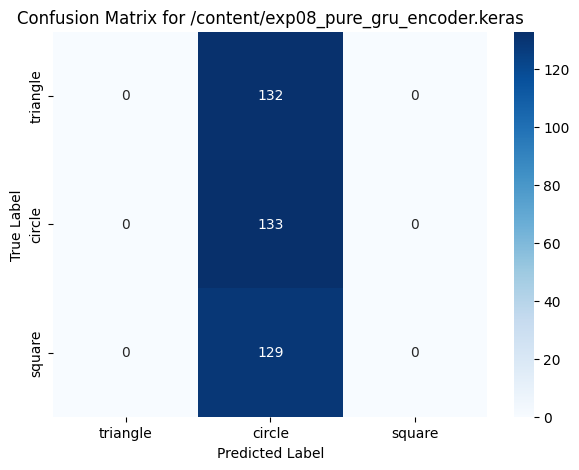

In [ ]:
# @title  Validate Model (Corrected & Self-Contained)
#
# This script loads a saved encoder, matches EEG to images, and calculates
# the overall accuracy on the entire test set. It is now self-contained.

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# --- HELPER FUNCTION (Previously in shared_utils.py) ---
def L2Normalization(x):
    """A named function for L2 normalization for safe model saving."""
    return tf.math.l2_normalize(x, axis=1)

# --- ⬇️ CONFIGURATION FOR VALIDATION ⬇️ ---
# ⚠️ Update these two variables before running!
MODEL_FILENAME = '/content/exp08_pure_gru_encoder.keras' # e.g., 'exp02_wider_ffn_encoder.keras'
DATA_TYPE = 'timeseries' # Can be 'features' or 'timeseries'
# --- ⬆️ CONFIGURATION FOR VALIDATION ⬆️ ---

print(f"--- Validating Model: {MODEL_FILENAME} ---")

# 1. Load packaged data from the setup script
try:
    with open('all_data.pkl', 'rb') as f:
        all_data = pickle.load(f)
    clip_embeddings = all_data['clip_embeddings']
except FileNotFoundError:
    raise SystemExit("❌ ERROR: 'all_data.pkl' not found. Please run the '00_setup.py' script first.")

# 2. Load the specific encoder model
try:
    encoder = tf.keras.models.load_model(MODEL_FILENAME, custom_objects={'L2Normalization': L2Normalization})
    print("✅ Encoder model loaded successfully.")
except Exception as e:
     raise SystemExit(f"❌ ERROR: Could not load the model. Make sure '{MODEL_FILENAME}' exists. Error details: {e}")

# 3. Prepare the correct dataset for testing
if DATA_TYPE == 'features':
    num_samples, num_channels, num_features_per_channel = all_data['X_raw'].shape
    X_reshaped = all_data['X_raw'].reshape(num_samples, num_channels * num_features_per_channel)
    scaler = StandardScaler()
    X_full_data = scaler.fit_transform(X_reshaped)
    y_full_data = all_data['y_raw']
elif DATA_TYPE == 'timeseries':
    X_full_data = all_data['X_timeseries']
    y_full_data = all_data['y_timeseries_str']
else:
    raise ValueError("DATA_TYPE must be 'features' or 'timeseries'")

# Create a consistent test split
_, X_test, _, y_test = train_test_split(X_full_data, y_full_data, test_size=0.2, random_state=42, stratify=y_full_data)
print(f"✅ Prepared {len(X_test)} test samples.")

# 4. Generate Embeddings and Make Predictions
predicted_eeg_embeddings = encoder.predict(X_test)
class_labels = list(clip_embeddings.keys())
clip_matrix = np.vstack([clip_embeddings[label] for label in class_labels])
similarities = cosine_similarity(predicted_eeg_embeddings, clip_matrix)
pred_indices = np.argmax(similarities, axis=1)
pred_labels = [class_labels[i] for i in pred_indices]

# 5. Display Results
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, pred_labels)

precision = precision_score(y_test, pred_labels, average='weighted')
recall = recall_score(y_test, pred_labels, average='weighted')
f1 = f1_score(y_test, pred_labels, average='weighted')

print(f"\n--- OVERALL PERFORMANCE ON TEST SET ---")
print(f"✅ Accuracy : {accuracy * 100:.2f}%")
print(f"✅ Precision: {precision * 100:.2f}%")
print(f"✅ Recall   : {recall * 100:.2f}%")
print(f"✅ F1 Score : {f1 * 100:.2f}%")

print("\n--- CLASS-WISE PERFORMANCE ---")
print(classification_report(
    y_test,
    pred_labels,
    target_names=class_labels,
    digits=4
))

cm = confusion_matrix(y_test, pred_labels, labels=class_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.title(f'Confusion Matrix for {MODEL_FILENAME}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



# t-SNE for Pure GRU

✅ Pure GRU encoder loaded
🔄 Generating GRU embeddings...
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
🔄 Running t-SNE...


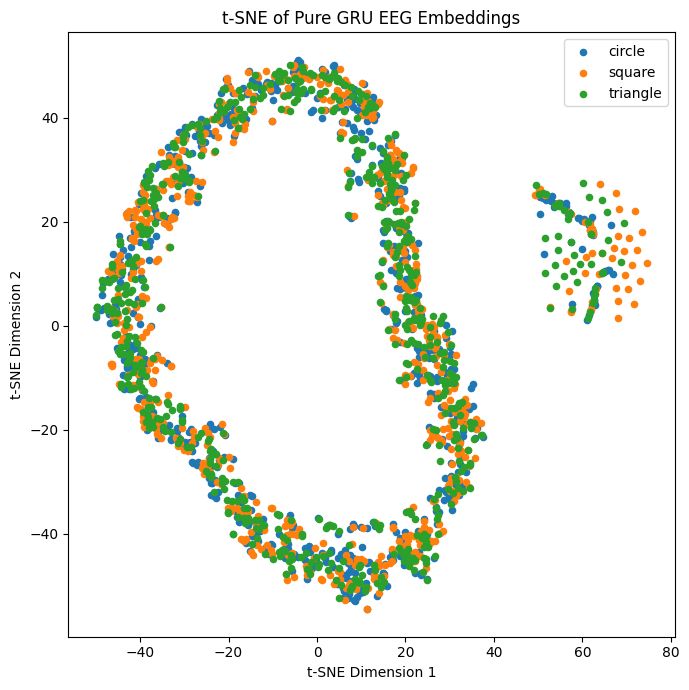

In [ ]:
# ============================================================
# t-SNE Visualization – Pure GRU EEG Encoder (Experiment 08)
# Matched with all previous models (LSTM, CNN, Hybrid, TriFusion)
# ============================================================

import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ---------- Helper ----------
def L2Normalization(x):
    return tf.math.l2_normalize(x, axis=1)

# ---------- Load trained encoder ----------
ENCODER_PATH = "exp08_pure_gru_encoder.keras"
encoder = tf.keras.models.load_model(
    ENCODER_PATH,
    custom_objects={"L2Normalization": L2Normalization}
)
print("✅ Pure GRU encoder loaded")

# ---------- Load data ----------
with open("all_data.pkl", "rb") as f:
    all_data = pickle.load(f)

X_timeseries = all_data["X_timeseries"]          # (N, time, channels)
y_raw = all_data["y_timeseries_str"]
unique_labels = sorted(list(set(y_raw)))

# ---------- Scale time-series (same as training) ----------
scaler = StandardScaler()
X_flat = X_timeseries.reshape(-1, X_timeseries.shape[-1])
X_scaled_flat = scaler.fit_transform(X_flat)
X_scaled = X_scaled_flat.reshape(X_timeseries.shape)

# ---------- Generate EEG embeddings ----------
print("🔄 Generating GRU embeddings...")
Z = encoder.predict(X_scaled, batch_size=32)

# ---------- t-SNE ----------
print("🔄 Running t-SNE...")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="pca",
    random_state=42
)
Z_2d = tsne.fit_transform(Z)

# ---------- Plot (EXACT SAME STYLE AS ALL OTHER FIGURES) ----------
plt.figure(figsize=(7, 7))

for lab in unique_labels:
    idx = np.where(np.array(y_raw) == lab)[0]
    plt.scatter(
        Z_2d[idx, 0],
        Z_2d[idx, 1],
        s=20,
        label=lab
    )

plt.legend()
plt.title("t-SNE of Pure GRU EEG Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()


In [ ]:
# @title  Run Experiment 09 - Stacked GRU on Time-Series
#
# This script uses two Gated Recurrent Unit (GRU) layers stacked on top of
# each other to learn a hierarchy of temporal features from the raw signal.

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda, GRU, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
import pickle
import os

# --- HELPER FUNCTIONS (to make script self-contained) ---
def L2Normalization(x):
    """A named function for L2 normalization for safe model saving."""
    return tf.math.l2_normalize(x, axis=1)

def triplet_loss(y_true, y_pred, alpha=0.4):
    """The Triplet Loss function."""
    embedding_dim = tf.shape(y_pred)[1] // 3
    anchor, pos, neg = y_pred[:, :embedding_dim], y_pred[:, embedding_dim:embedding_dim*2], y_pred[:, embedding_dim*2:]
    pos_dist = tf.reduce_sum(tf.square(anchor - pos), axis=1)
    neg_dist = tf.reduce_sum(tf.square(anchor - neg), axis=1)
    loss = tf.reduce_mean(tf.maximum(pos_dist - neg_dist + alpha, 0.0))
    return loss

def create_triplets(X_features, y_labels_str, clip_embeds):
    """Creates anchor, positive, and negative samples for training."""
    x_anchor, x_positive, x_negative = [], [], []
    classes = list(clip_embeds.keys())
    for i in range(len(X_features)):
        anchor_eeg, true_label_name = X_features[i], y_labels_str[i]
        positive_clip = clip_embeds[true_label_name]
        negative_label_name = np.random.choice([c for c in classes if c != true_label_name])
        negative_clip = clip_embeds[negative_label_name]
        x_anchor.append(anchor_eeg)
        x_positive.append(positive_clip)
        x_negative.append(negative_clip)
    return np.array(x_anchor), np.array(x_positive), np.array(x_negative)

# --- 1. SETUP ---
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(42)
np.random.seed(42)

# --- 2. LOAD & PREPARE DATA ---
print("--- Loading and Preparing Data for Experiment 09 ---")
with open('all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)
X_timeseries = all_data['X_timeseries']
y_timeseries_str = all_data['y_timeseries_str']
clip_embeddings = all_data['clip_embeddings']

# Normalize the time-series data
scaler = StandardScaler()
X_reshaped = X_timeseries.reshape(-1, X_timeseries.shape[-1])
X_scaled_reshaped = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled_reshaped.reshape(X_timeseries.shape)
print(f"✅ Time-series data prepared and scaled. Shape: {X_scaled.shape}")

# --- 3. BUILD THE STACKED GRU ENCODER MODEL ---
def build_stacked_gru_encoder(input_shape, embedding_dim):
    """Builds a stacked GRU encoder for time-series data."""
    eeg_input = Input(shape=input_shape, name="eeg_input")
    x = BatchNormalization()(eeg_input)
    # First GRU layer returns sequences to feed into the next GRU layer
    x = GRU(128, return_sequences=True)(x)
    x = Dropout(0.4)(x)
    # Second GRU layer returns only the final hidden state
    x = GRU(128)(x)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(embedding_dim, activation=None)(x)
    x = Lambda(L2Normalization, name="L2Normalization")(x)
    return Model(inputs=eeg_input, outputs=x, name="EEG_Encoder_Stacked_GRU")

TIMESERIES_SHAPE = (X_scaled.shape[1], X_scaled.shape[2])
EMBEDDING_DIM = 512
encoder = build_stacked_gru_encoder(TIMESERIES_SHAPE, EMBEDDING_DIM)
print("\n--- Model Architecture ---")
encoder.summary()

# --- 4. CREATE TRIPLETS & COMPILE FULL MODEL ---
anchor, positive, negative = create_triplets(X_scaled, y_timeseries_str, clip_embeddings)
anchor_input, pos_input, neg_input = Input(shape=TIMESERIES_SHAPE), Input(shape=(EMBEDDING_DIM,)), Input(shape=(EMBEDDING_DIM,))
eeg_embedding = encoder(anchor_input)
merged_output = tf.keras.layers.concatenate([eeg_embedding, pos_input, neg_input], axis=1)
training_model = Model(inputs=[anchor_input, pos_input, neg_input], outputs=merged_output)
training_model.compile(optimizer=Adam(learning_rate=0.0001), loss=triplet_loss)

# --- 5. TRAIN THE ENCODER ---
early_stopping = EarlyStopping(monitor='val_loss', patience=25, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6, verbose=1)

print("\n🚀 Starting training for Experiment 09...")
training_model.fit(
    [anchor, positive, negative], np.zeros((anchor.shape[0], 1)),
    epochs=200, batch_size=32, validation_split=0.2,
    callbacks=[early_stopping, reduce_lr], verbose=1
)
print("\n✅ Training complete!")

# --- 6. SAVE THE TRAINED ENCODER ---
encoder_filename = 'exp09_stacked_gru_encoder.keras'
encoder.save(encoder_filename)
print(f"\n✅ Trained encoder saved successfully to '{encoder_filename}'")



--- Loading and Preparing Data for Experiment 09 ---
✅ Time-series data prepared and scaled. Shape: (1969, 375, 2)

--- Model Architecture ---


Model: "EEG_Encoder_Stacked_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)          │ (None, 375, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 375, 2)         │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 375, 128)       │        50,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 375, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2Normalization (Lambda)        │ (None, 512)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,376 (1.20 MB)

 Trainable params: 314,372 (1.20 MB)

 Non-trainable params: 4 (16.00 B)


🚀 Starting training for Experiment 09...
Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: 0.4004 - val_loss: 0.4058 - learning_rate: 1.0000e-04
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.3965 - val_loss: 0.4195 - learning_rate: 1.0000e-04
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.3944 - val_loss: 0.4299 - learning_rate: 1.0000e-04
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.3923 - val_loss: 0.4389 - learning_rate: 1.0000e-04
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.3895 - val_loss: 0.4465 - learning_rate: 1.0000e-04
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 0.3904 - val_loss: 0.4520 - learning_rate: 1.0000e-04
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.3879 - val_loss: 0.4585 - learning_rate: 1.0000e-04
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.3878 - val_loss: 0.4622 - learning_rate: 1.0000e-04
Epoch 9/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 103m

--- Validating Model: /content/exp09_stacked_gru_encoder.keras ---
✅ Encoder model loaded successfully.
✅ Prepared 394 test samples.
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 255ms/step

--- OVERALL PERFORMANCE ON TEST SET ---
✅ Accuracy: 33.76%


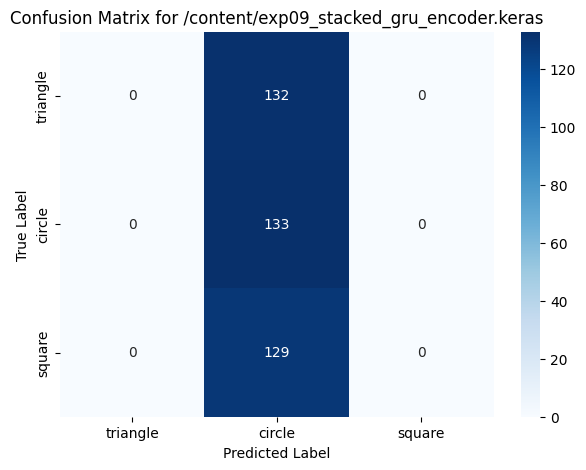

In [ ]:
# @title  Validate Model (Corrected & Self-Contained)
#
# This script loads a saved encoder, matches EEG to images, and calculates
# the overall accuracy on the entire test set. It is now self-contained.

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# --- HELPER FUNCTION (Previously in shared_utils.py) ---
def L2Normalization(x):
    """A named function for L2 normalization for safe model saving."""
    return tf.math.l2_normalize(x, axis=1)

# --- ⬇️ CONFIGURATION FOR VALIDATION ⬇️ ---
# ⚠️ Update these two variables before running!
MODEL_FILENAME = '/content/exp09_stacked_gru_encoder.keras' # e.g., 'exp02_wider_ffn_encoder.keras'
DATA_TYPE = 'timeseries' # Can be 'features' or 'timeseries'
# --- ⬆️ CONFIGURATION FOR VALIDATION ⬆️ ---

print(f"--- Validating Model: {MODEL_FILENAME} ---")

# 1. Load packaged data from the setup script
try:
    with open('all_data.pkl', 'rb') as f:
        all_data = pickle.load(f)
    clip_embeddings = all_data['clip_embeddings']
except FileNotFoundError:
    raise SystemExit("❌ ERROR: 'all_data.pkl' not found. Please run the '00_setup.py' script first.")

# 2. Load the specific encoder model
try:
    encoder = tf.keras.models.load_model(MODEL_FILENAME, custom_objects={'L2Normalization': L2Normalization})
    print("✅ Encoder model loaded successfully.")
except Exception as e:
     raise SystemExit(f"❌ ERROR: Could not load the model. Make sure '{MODEL_FILENAME}' exists. Error details: {e}")

# 3. Prepare the correct dataset for testing
if DATA_TYPE == 'features':
    num_samples, num_channels, num_features_per_channel = all_data['X_raw'].shape
    X_reshaped = all_data['X_raw'].reshape(num_samples, num_channels * num_features_per_channel)
    scaler = StandardScaler()
    X_full_data = scaler.fit_transform(X_reshaped)
    y_full_data = all_data['y_raw']
elif DATA_TYPE == 'timeseries':
    X_full_data = all_data['X_timeseries']
    y_full_data = all_data['y_timeseries_str']
else:
    raise ValueError("DATA_TYPE must be 'features' or 'timeseries'")

# Create a consistent test split
_, X_test, _, y_test = train_test_split(X_full_data, y_full_data, test_size=0.2, random_state=42, stratify=y_full_data)
print(f"✅ Prepared {len(X_test)} test samples.")

# 4. Generate Embeddings and Make Predictions
predicted_eeg_embeddings = encoder.predict(X_test)
class_labels = list(clip_embeddings.keys())
clip_matrix = np.vstack([clip_embeddings[label] for label in class_labels])
similarities = cosine_similarity(predicted_eeg_embeddings, clip_matrix)
pred_indices = np.argmax(similarities, axis=1)
pred_labels = [class_labels[i] for i in pred_indices]

# 5. Display Results
accuracy = accuracy_score(y_test, pred_labels)
print(f"\n--- OVERALL PERFORMANCE ON TEST SET ---")
print(f"✅ Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, pred_labels, labels=class_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Confusion Matrix for {MODEL_FILENAME}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



# t-SNE for Stacked GRU

✅ Stacked GRU encoder loaded
🔄 Generating stacked GRU embeddings...
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
🔄 Running t-SNE...


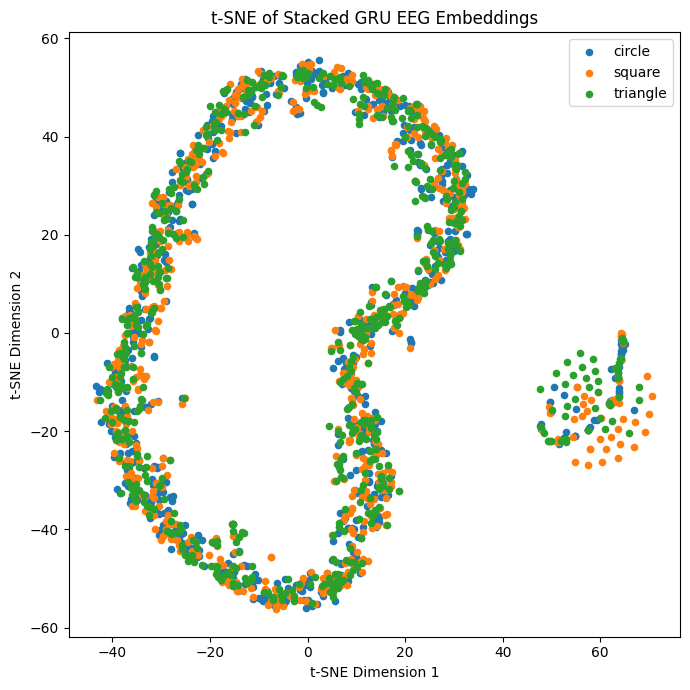

In [ ]:
# ============================================================
# t-SNE Visualization – Stacked GRU EEG Encoder (Experiment 09)
# Matched with all previous models (GRU, LSTM, CNN, Hybrid)
# ============================================================

import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ---------- Helper ----------
def L2Normalization(x):
    return tf.math.l2_normalize(x, axis=1)

# ---------- Load trained encoder ----------
ENCODER_PATH = "exp09_stacked_gru_encoder.keras"
encoder = tf.keras.models.load_model(
    ENCODER_PATH,
    custom_objects={"L2Normalization": L2Normalization}
)
print("✅ Stacked GRU encoder loaded")

# ---------- Load data ----------
with open("all_data.pkl", "rb") as f:
    all_data = pickle.load(f)

X_timeseries = all_data["X_timeseries"]          # (N, time, channels)
y_raw = all_data["y_timeseries_str"]
unique_labels = sorted(list(set(y_raw)))

# ---------- Scale time-series (same as training) ----------
scaler = StandardScaler()
X_flat = X_timeseries.reshape(-1, X_timeseries.shape[-1])
X_scaled_flat = scaler.fit_transform(X_flat)
X_scaled = X_scaled_flat.reshape(X_timeseries.shape)

# ---------- Generate EEG embeddings ----------
print("🔄 Generating stacked GRU embeddings...")
Z = encoder.predict(X_scaled, batch_size=32)

# ---------- t-SNE ----------
print("🔄 Running t-SNE...")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="pca",
    random_state=42
)
Z_2d = tsne.fit_transform(Z)

# ---------- Plot (EXACT SAME STYLE AS ALL OTHER FIGURES) ----------
plt.figure(figsize=(7, 7))

for lab in unique_labels:
    idx = np.where(np.array(y_raw) == lab)[0]
    plt.scatter(
        Z_2d[idx, 0],
        Z_2d[idx, 1],
        s=20,
        label=lab
    )

plt.legend()
plt.title("t-SNE of Stacked GRU EEG Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()


In [ ]:
# @title  Run Experiment 10 - Bidirectional GRU on Time-Series
#
# This script uses a Bidirectional GRU, which processes the time-series
# both forwards and backwards to capture a richer temporal context.

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda, GRU, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
import pickle
import os

# --- HELPER FUNCTIONS (to make script self-contained) ---
def L2Normalization(x):
    return tf.math.l2_normalize(x, axis=1)

def triplet_loss(y_true, y_pred, alpha=0.4):
    embedding_dim = tf.shape(y_pred)[1] // 3
    anchor, pos, neg = y_pred[:, :embedding_dim], y_pred[:, embedding_dim:embedding_dim*2], y_pred[:, embedding_dim*2:]
    pos_dist = tf.reduce_sum(tf.square(anchor - pos), axis=1)
    neg_dist = tf.reduce_sum(tf.square(anchor - neg), axis=1)
    loss = tf.reduce_mean(tf.maximum(pos_dist - neg_dist + alpha, 0.0))
    return loss

def create_triplets(X_features, y_labels_str, clip_embeds):
    x_anchor, x_positive, x_negative = [], [], []
    classes = list(clip_embeds.keys())
    for i in range(len(X_features)):
        anchor_eeg, true_label_name = X_features[i], y_labels_str[i]
        positive_clip = clip_embeds[true_label_name]
        negative_label_name = np.random.choice([c for c in classes if c != true_label_name])
        negative_clip = clip_embeds[negative_label_name]
        x_anchor.append(anchor_eeg)
        x_positive.append(positive_clip)
        x_negative.append(negative_clip)
    return np.array(x_anchor), np.array(x_positive), np.array(x_negative)

# --- 1. SETUP ---
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(42)
np.random.seed(42)

# --- 2. LOAD & PREPARE DATA ---
print("--- Loading and Preparing Data for Experiment 10 ---")
with open('all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)
X_timeseries = all_data['X_timeseries']
y_timeseries_str = all_data['y_timeseries_str']
clip_embeddings = all_data['clip_embeddings']

scaler = StandardScaler()
X_reshaped = X_timeseries.reshape(-1, X_timeseries.shape[-1])
X_scaled_reshaped = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled_reshaped.reshape(X_timeseries.shape)
print(f"✅ Time-series data prepared and scaled. Shape: {X_scaled.shape}")

# --- 3. BUILD THE BIDIRECTIONAL GRU ENCODER MODEL ---
def build_bidirectional_gru_encoder(input_shape, embedding_dim):
    eeg_input = Input(shape=input_shape, name="eeg_input")
    x = BatchNormalization()(eeg_input)
    # Wrap the GRU layer in a Bidirectional layer
    x = Bidirectional(GRU(128, return_sequences=False))(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(embedding_dim, activation=None)(x)
    x = Lambda(L2Normalization, name="L2Normalization")(x)
    return Model(inputs=eeg_input, outputs=x, name="EEG_Encoder_Bidir_GRU")

TIMESERIES_SHAPE = (X_scaled.shape[1], X_scaled.shape[2])
EMBEDDING_DIM = 512
encoder = build_bidirectional_gru_encoder(TIMESERIES_SHAPE, EMBEDDING_DIM)
print("\n--- Model Architecture ---")
encoder.summary()

# --- 4. CREATE TRIPLETS & COMPILE FULL MODEL ---
anchor, positive, negative = create_triplets(X_scaled, y_timeseries_str, clip_embeddings)
anchor_input, pos_input, neg_input = Input(shape=TIMESERIES_SHAPE), Input(shape=(EMBEDDING_DIM,)), Input(shape=(EMBEDDING_DIM,))
eeg_embedding = encoder(anchor_input)
merged_output = tf.keras.layers.concatenate([eeg_embedding, pos_input, neg_input], axis=1)
training_model = Model(inputs=[anchor_input, pos_input, neg_input], outputs=merged_output)
training_model.compile(optimizer=Adam(learning_rate=0.0001), loss=triplet_loss)

# --- 5. TRAIN THE ENCODER ---
early_stopping = EarlyStopping(monitor='val_loss', patience=25, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6, verbose=1)

print("\n🚀 Starting training for Experiment 10...")
training_model.fit(
    [anchor, positive, negative], np.zeros((anchor.shape[0], 1)),
    epochs=200, batch_size=32, validation_split=0.2,
    callbacks=[early_stopping, reduce_lr], verbose=1
)
print("\n✅ Training complete!")

# --- 6. SAVE THE TRAINED ENCODER ---
encoder_filename = 'exp10_bidirectional_gru_encoder.keras'
encoder.save(encoder_filename)
print(f"\n✅ Trained encoder saved successfully to '{encoder_filename}'")



--- Loading and Preparing Data for Experiment 10 ---
✅ Time-series data prepared and scaled. Shape: (1969, 375, 2)

--- Model Architecture ---


Model: "EEG_Encoder_Bidir_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)          │ (None, 375, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 375, 2)         │             8 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       101,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2Normalization (Lambda)        │ (None, 512)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 298,760 (1.14 MB)

 Trainable params: 298,756 (1.14 MB)

 Non-trainable params: 4 (16.00 B)


🚀 Starting training for Experiment 10...
Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.4006 - val_loss: 0.4032 - learning_rate: 1.0000e-04
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.3969 - val_loss: 0.4123 - learning_rate: 1.0000e-04
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.3944 - val_loss: 0.4210 - learning_rate: 1.0000e-04
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.3928 - val_loss: 0.4284 - learning_rate: 1.0000e-04
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.3930 - val_loss: 0.4350 - learning_rate: 1.0000e-04
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - loss: 0.3892 - val_loss: 0.4417 - learning_rate: 1.0000e-04
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.3878 - val_loss: 0.4475 - learning_rate: 1.0000e-04
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.3884 - val_loss: 0.4522 - learning_rate: 1.0000e-04
Epoch 9/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms

--- Validating Model: /content/exp10_bidirectional_gru_encoder.keras ---
✅ Encoder model loaded successfully.
✅ Prepared 394 test samples.
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step

--- OVERALL PERFORMANCE ON TEST SET ---
✅ Accuracy: 35.28%


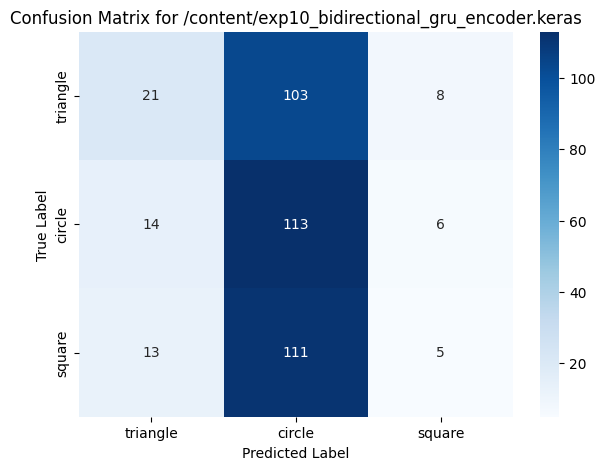

In [ ]:
# @title  Validate Model (Corrected & Self-Contained)
#
# This script loads a saved encoder, matches EEG to images, and calculates
# the overall accuracy on the entire test set. It is now self-contained.

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# --- HELPER FUNCTION (Previously in shared_utils.py) ---
def L2Normalization(x):
    """A named function for L2 normalization for safe model saving."""
    return tf.math.l2_normalize(x, axis=1)

# --- ⬇️ CONFIGURATION FOR VALIDATION ⬇️ ---
# ⚠️ Update these two variables before running!
MODEL_FILENAME = '/content/exp10_bidirectional_gru_encoder.keras' # e.g., 'exp02_wider_ffn_encoder.keras'
DATA_TYPE = 'timeseries' # Can be 'features' or 'timeseries'
# --- ⬆️ CONFIGURATION FOR VALIDATION ⬆️ ---

print(f"--- Validating Model: {MODEL_FILENAME} ---")

# 1. Load packaged data from the setup script
try:
    with open('all_data.pkl', 'rb') as f:
        all_data = pickle.load(f)
    clip_embeddings = all_data['clip_embeddings']
except FileNotFoundError:
    raise SystemExit("❌ ERROR: 'all_data.pkl' not found. Please run the '00_setup.py' script first.")

# 2. Load the specific encoder model
try:
    encoder = tf.keras.models.load_model(MODEL_FILENAME, custom_objects={'L2Normalization': L2Normalization})
    print("✅ Encoder model loaded successfully.")
except Exception as e:
     raise SystemExit(f"❌ ERROR: Could not load the model. Make sure '{MODEL_FILENAME}' exists. Error details: {e}")

# 3. Prepare the correct dataset for testing
if DATA_TYPE == 'features':
    num_samples, num_channels, num_features_per_channel = all_data['X_raw'].shape
    X_reshaped = all_data['X_raw'].reshape(num_samples, num_channels * num_features_per_channel)
    scaler = StandardScaler()
    X_full_data = scaler.fit_transform(X_reshaped)
    y_full_data = all_data['y_raw']
elif DATA_TYPE == 'timeseries':
    X_full_data = all_data['X_timeseries']
    y_full_data = all_data['y_timeseries_str']
else:
    raise ValueError("DATA_TYPE must be 'features' or 'timeseries'")

# Create a consistent test split
_, X_test, _, y_test = train_test_split(X_full_data, y_full_data, test_size=0.2, random_state=42, stratify=y_full_data)
print(f"✅ Prepared {len(X_test)} test samples.")

# 4. Generate Embeddings and Make Predictions
predicted_eeg_embeddings = encoder.predict(X_test)
class_labels = list(clip_embeddings.keys())
clip_matrix = np.vstack([clip_embeddings[label] for label in class_labels])
similarities = cosine_similarity(predicted_eeg_embeddings, clip_matrix)
pred_indices = np.argmax(similarities, axis=1)
pred_labels = [class_labels[i] for i in pred_indices]

# 5. Display Results
accuracy = accuracy_score(y_test, pred_labels)
print(f"\n--- OVERALL PERFORMANCE ON TEST SET ---")
print(f"✅ Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, pred_labels, labels=class_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Confusion Matrix for {MODEL_FILENAME}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



# Bidirectional GRU t-SNE

✅ Bidirectional GRU encoder loaded
🔄 Generating Bidirectional GRU embeddings...
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
🔄 Running t-SNE...


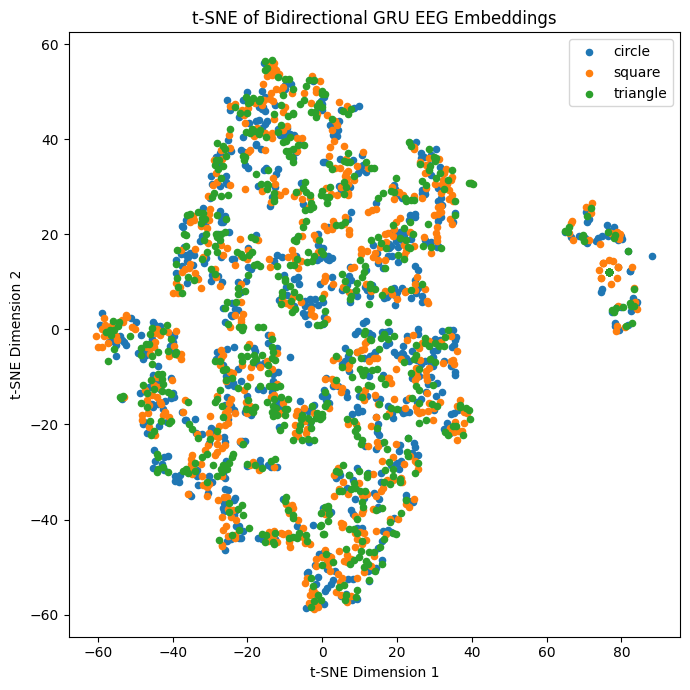

In [ ]:
# ============================================================
# t-SNE Visualization – Bidirectional GRU EEG Encoder (Exp 10)
# Consistent with all previous EEG t-SNE figures
# ============================================================

import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ---------- Helper ----------
def L2Normalization(x):
    return tf.math.l2_normalize(x, axis=1)

# ---------- Load trained encoder ----------
ENCODER_PATH = "exp10_bidirectional_gru_encoder.keras"
encoder = tf.keras.models.load_model(
    ENCODER_PATH,
    custom_objects={"L2Normalization": L2Normalization}
)
print("✅ Bidirectional GRU encoder loaded")

# ---------- Load data ----------
with open("all_data.pkl", "rb") as f:
    all_data = pickle.load(f)

X_timeseries = all_data["X_timeseries"]          # (N, time, channels)
y_raw = all_data["y_timeseries_str"]
unique_labels = sorted(list(set(y_raw)))

# ---------- Scale time-series (same as training) ----------
scaler = StandardScaler()
X_flat = X_timeseries.reshape(-1, X_timeseries.shape[-1])
X_scaled_flat = scaler.fit_transform(X_flat)
X_scaled = X_scaled_flat.reshape(X_timeseries.shape)

# ---------- Generate EEG embeddings ----------
print("🔄 Generating Bidirectional GRU embeddings...")
Z = encoder.predict(X_scaled, batch_size=32)

# ---------- t-SNE ----------
print("🔄 Running t-SNE...")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="pca",
    random_state=42
)
Z_2d = tsne.fit_transform(Z)

# ---------- Plot (EXACT SAME STYLE AS ALL OTHER FIGURES) ----------
plt.figure(figsize=(7, 7))

for lab in unique_labels:
    idx = np.where(np.array(y_raw) == lab)[0]
    plt.scatter(
        Z_2d[idx, 0],
        Z_2d[idx, 1],
        s=20,
        label=lab
    )

plt.legend()
plt.title("t-SNE of Bidirectional GRU EEG Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()


In [ ]:
# @title ▶️ STEP 2: Run Experiment 11 - Pure 1D-CNN on Time-Series
#
# This script uses only 1D Convolutional layers to learn hierarchical
# temporal features (motifs) directly from the raw EEG signal.

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda, Conv1D, MaxPooling1D, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
import pickle
import os

# --- HELPER FUNCTIONS (to make script self-contained) ---
def L2Normalization(x):
    return tf.math.l2_normalize(x, axis=1)

def triplet_loss(y_true, y_pred, alpha=0.4):
    embedding_dim = tf.shape(y_pred)[1] // 3
    anchor, pos, neg = y_pred[:, :embedding_dim], y_pred[:, embedding_dim:embedding_dim*2], y_pred[:, embedding_dim*2:]
    pos_dist = tf.reduce_sum(tf.square(anchor - pos), axis=1)
    neg_dist = tf.reduce_sum(tf.square(anchor - neg), axis=1)
    loss = tf.reduce_mean(tf.maximum(pos_dist - neg_dist + alpha, 0.0))
    return loss

def create_triplets(X_features, y_labels_str, clip_embeds):
    x_anchor, x_positive, x_negative = [], [], []
    classes = list(clip_embeds.keys())
    for i in range(len(X_features)):
        anchor_eeg, true_label_name = X_features[i], y_labels_str[i]
        positive_clip = clip_embeds[true_label_name]
        negative_label_name = np.random.choice([c for c in classes if c != true_label_name])
        negative_clip = clip_embeds[negative_label_name]
        x_anchor.append(anchor_eeg)
        x_positive.append(positive_clip)
        x_negative.append(negative_clip)
    return np.array(x_anchor), np.array(x_positive), np.array(x_negative)

# --- 1. SETUP ---
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(42)
np.random.seed(42)

# --- 2. LOAD & PREPARE DATA ---
print("--- Loading and Preparing Data for Experiment 11 ---")
with open('all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)
X_timeseries = all_data['X_timeseries']
y_timeseries_str = all_data['y_timeseries_str']
clip_embeddings = all_data['clip_embeddings']

scaler = StandardScaler()
X_reshaped = X_timeseries.reshape(-1, X_timeseries.shape[-1])
X_scaled_reshaped = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled_reshaped.reshape(X_timeseries.shape)
print(f"✅ Time-series data prepared and scaled. Shape: {X_scaled.shape}")

# --- 3. BUILD THE PURE 1D-CNN ENCODER MODEL ---
def build_pure_cnn_encoder(input_shape, embedding_dim):
    eeg_input = Input(shape=input_shape, name="eeg_input")
    x = Conv1D(filters=64, kernel_size=10, activation='relu', padding='same')(eeg_input)
    x = MaxPooling1D(2)(x)
    x = Conv1D(filters=128, kernel_size=10, activation='relu', padding='same')(x)
    x = MaxPooling1D(2)(x)
    x = Conv1D(filters=256, kernel_size=10, activation='relu', padding='same')(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(embedding_dim, activation=None)(x)
    x = Lambda(L2Normalization, name="L2Normalization")(x)
    return Model(inputs=eeg_input, outputs=x, name="EEG_Encoder_Pure_CNN_TS")

TIMESERIES_SHAPE = (X_scaled.shape[1], X_scaled.shape[2])
EMBEDDING_DIM = 512
encoder = build_pure_cnn_encoder(TIMESERIES_SHAPE, EMBEDDING_DIM)
print("\n--- Model Architecture ---")
encoder.summary()

# --- 4. CREATE TRIPLETS & COMPILE FULL MODEL ---
anchor, positive, negative = create_triplets(X_scaled, y_timeseries_str, clip_embeddings)
anchor_input, pos_input, neg_input = Input(shape=TIMESERIES_SHAPE), Input(shape=(EMBEDDING_DIM,)), Input(shape=(EMBEDDING_DIM,))
eeg_embedding = encoder(anchor_input)
merged_output = tf.keras.layers.concatenate([eeg_embedding, pos_input, neg_input], axis=1)
training_model = Model(inputs=[anchor_input, pos_input, neg_input], outputs=merged_output)
training_model.compile(optimizer=Adam(learning_rate=0.0001), loss=triplet_loss)

# --- 5. TRAIN THE ENCODER ---
early_stopping = EarlyStopping(monitor='val_loss', patience=25, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6, verbose=1)

print("\n🚀 Starting training for Experiment 11...")
training_model.fit(
    [anchor, positive, negative], np.zeros((anchor.shape[0], 1)),
    epochs=200, batch_size=32, validation_split=0.2,
    callbacks=[early_stopping, reduce_lr], verbose=1
)
print("\n✅ Training complete!")

# --- 6. SAVE THE TRAINED ENCODER ---
encoder_filename = 'exp11_pure_cnn_timeseries_encoder.keras'
encoder.save(encoder_filename)
print(f"\n✅ Trained encoder saved successfully to '{encoder_filename}'")



--- Loading and Preparing Data for Experiment 11 ---
✅ Time-series data prepared and scaled. Shape: (1969, 375, 2)

--- Model Architecture ---


Model: "EEG_Encoder_Pure_CNN_TS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)          │ (None, 375, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 375, 64)        │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 187, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 187, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 93, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 93, 256)        │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2Normalization (Lambda)        │ (None, 512)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 608,704 (2.32 MB)

 Trainable params: 608,704 (2.32 MB)

 Non-trainable params: 0 (0.00 B)


🚀 Starting training for Experiment 11...
Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.3995 - val_loss: 0.4304 - learning_rate: 1.0000e-04
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3943 - val_loss: 0.4491 - learning_rate: 1.0000e-04
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3911 - val_loss: 0.4693 - learning_rate: 1.0000e-04
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3873 - val_loss: 0.4809 - learning_rate: 1.0000e-04
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3871 - val_loss: 0.4808 - learning_rate: 1.0000e-04
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3872 - val_loss: 0.4800 - learning_rate: 1.0000e-04
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3867 - val_loss: 0.4815 - learning_rate: 1.0000e-04
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3841 - val_loss: 0.4832 - learning_rate: 1.0000e-04
Epoch 9/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms

--- Validating Model: /content/exp11_pure_cnn_timeseries_encoder.keras ---
✅ Encoder model loaded successfully.
✅ Prepared 394 test samples.
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step

--- OVERALL PERFORMANCE ON TEST SET ---
✅ Accuracy: 35.03%


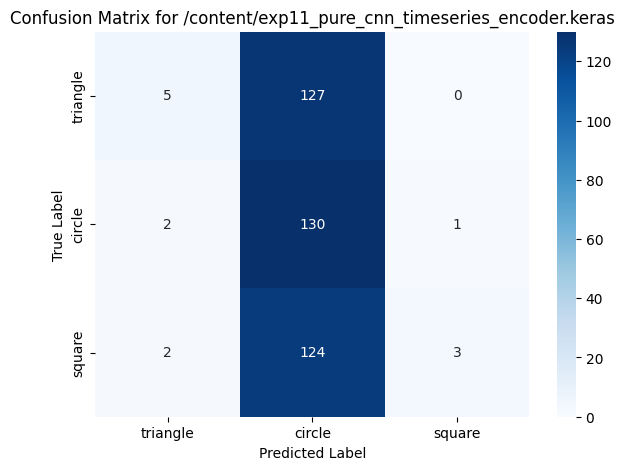

In [ ]:
# @title  Validate Model (Corrected & Self-Contained)
#
# This script loads a saved encoder, matches EEG to images, and calculates
# the overall accuracy on the entire test set. It is now self-contained.

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# --- HELPER FUNCTION (Previously in shared_utils.py) ---
def L2Normalization(x):
    """A named function for L2 normalization for safe model saving."""
    return tf.math.l2_normalize(x, axis=1)

# --- ⬇️ CONFIGURATION FOR VALIDATION ⬇️ ---
# ⚠️ Update these two variables before running!
MODEL_FILENAME = '/content/exp11_pure_cnn_timeseries_encoder.keras' # e.g., 'exp02_wider_ffn_encoder.keras'
DATA_TYPE = 'timeseries' # Can be 'features' or 'timeseries'
# --- ⬆️ CONFIGURATION FOR VALIDATION ⬆️ ---

print(f"--- Validating Model: {MODEL_FILENAME} ---")

# 1. Load packaged data from the setup script
try:
    with open('all_data.pkl', 'rb') as f:
        all_data = pickle.load(f)
    clip_embeddings = all_data['clip_embeddings']
except FileNotFoundError:
    raise SystemExit("❌ ERROR: 'all_data.pkl' not found. Please run the '00_setup.py' script first.")

# 2. Load the specific encoder model
try:
    encoder = tf.keras.models.load_model(MODEL_FILENAME, custom_objects={'L2Normalization': L2Normalization})
    print("✅ Encoder model loaded successfully.")
except Exception as e:
     raise SystemExit(f"❌ ERROR: Could not load the model. Make sure '{MODEL_FILENAME}' exists. Error details: {e}")

# 3. Prepare the correct dataset for testing
if DATA_TYPE == 'features':
    num_samples, num_channels, num_features_per_channel = all_data['X_raw'].shape
    X_reshaped = all_data['X_raw'].reshape(num_samples, num_channels * num_features_per_channel)
    scaler = StandardScaler()
    X_full_data = scaler.fit_transform(X_reshaped)
    y_full_data = all_data['y_raw']
elif DATA_TYPE == 'timeseries':
    X_full_data = all_data['X_timeseries']
    y_full_data = all_data['y_timeseries_str']
else:
    raise ValueError("DATA_TYPE must be 'features' or 'timeseries'")

# Create a consistent test split
_, X_test, _, y_test = train_test_split(X_full_data, y_full_data, test_size=0.2, random_state=42, stratify=y_full_data)
print(f"✅ Prepared {len(X_test)} test samples.")

# 4. Generate Embeddings and Make Predictions
predicted_eeg_embeddings = encoder.predict(X_test)
class_labels = list(clip_embeddings.keys())
clip_matrix = np.vstack([clip_embeddings[label] for label in class_labels])
similarities = cosine_similarity(predicted_eeg_embeddings, clip_matrix)
pred_indices = np.argmax(similarities, axis=1)
pred_labels = [class_labels[i] for i in pred_indices]

# 5. Display Results
accuracy = accuracy_score(y_test, pred_labels)
print(f"\n--- OVERALL PERFORMANCE ON TEST SET ---")
print(f"✅ Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, pred_labels, labels=class_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Confusion Matrix for {MODEL_FILENAME}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



# t-SNE Pure 1D CNN Time Series Encoder

✅ Pure 1D-CNN encoder loaded
🔄 Generating CNN embeddings...
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
🔄 Running t-SNE...


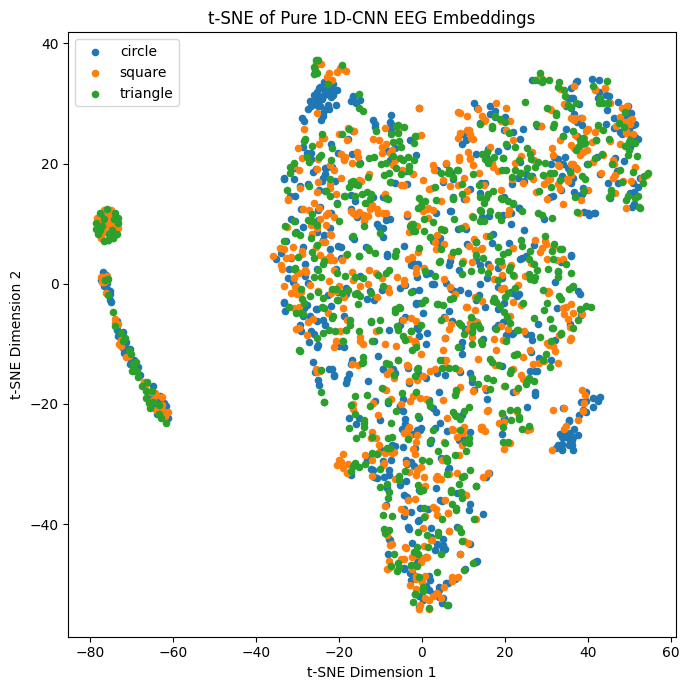

In [ ]:
# ============================================================
# t-SNE Visualization – Pure 1D-CNN Time-Series Encoder (Exp 11)
# Consistent with all previous EEG t-SNE figures
# ============================================================

import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ---------- Helper ----------
def L2Normalization(x):
    return tf.math.l2_normalize(x, axis=1)

# ---------- Load trained encoder ----------
ENCODER_PATH = "exp11_pure_cnn_timeseries_encoder.keras"
encoder = tf.keras.models.load_model(
    ENCODER_PATH,
    custom_objects={"L2Normalization": L2Normalization}
)
print("✅ Pure 1D-CNN encoder loaded")

# ---------- Load data ----------
with open("all_data.pkl", "rb") as f:
    all_data = pickle.load(f)

X_timeseries = all_data["X_timeseries"]          # (N, time, channels)
y_raw = all_data["y_timeseries_str"]
unique_labels = sorted(list(set(y_raw)))

# ---------- Scale time-series (same as training) ----------
scaler = StandardScaler()
X_flat = X_timeseries.reshape(-1, X_timeseries.shape[-1])
X_scaled_flat = scaler.fit_transform(X_flat)
X_scaled = X_scaled_flat.reshape(X_timeseries.shape)

# ---------- Generate EEG embeddings ----------
print("🔄 Generating CNN embeddings...")
Z = encoder.predict(X_scaled, batch_size=32)

# ---------- t-SNE ----------
print("🔄 Running t-SNE...")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="pca",
    random_state=42
)
Z_2d = tsne.fit_transform(Z)

# ---------- Plot (EXACT SAME STYLE AS ALL OTHER FIGURES) ----------
plt.figure(figsize=(7, 7))

for lab in unique_labels:
    idx = np.where(np.array(y_raw) == lab)[0]
    plt.scatter(
        Z_2d[idx, 0],
        Z_2d[idx, 1],
        s=20,
        label=lab
    )

plt.legend()
plt.title("t-SNE of Pure 1D-CNN EEG Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()


In [ ]:
# @title  Run Experiment 12 - CNN+GRU on Time-Series
#
# This script trains a powerful hybrid model that uses 1D-CNN layers to
# extract features from the time-series, which are then fed into a GRU
# to model their temporal sequence.

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda, GRU, BatchNormalization, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
import pickle
import os

# --- HELPER FUNCTIONS (to make script self-contained) ---
def L2Normalization(x):
    return tf.math.l2_normalize(x, axis=1)

def triplet_loss(y_true, y_pred, alpha=0.4):
    embedding_dim = tf.shape(y_pred)[1] // 3
    anchor, pos, neg = y_pred[:, :embedding_dim], y_pred[:, embedding_dim:embedding_dim*2], y_pred[:, embedding_dim*2:]
    pos_dist = tf.reduce_sum(tf.square(anchor - pos), axis=1)
    neg_dist = tf.reduce_sum(tf.square(anchor - neg), axis=1)
    loss = tf.reduce_mean(tf.maximum(pos_dist - neg_dist + alpha, 0.0))
    return loss

def create_triplets(X_features, y_labels_str, clip_embeds):
    x_anchor, x_positive, x_negative = [], [], []
    classes = list(clip_embeds.keys())
    for i in range(len(X_features)):
        anchor_eeg, true_label_name = X_features[i], y_labels_str[i]
        positive_clip = clip_embeds[true_label_name]
        negative_label_name = np.random.choice([c for c in classes if c != true_label_name])
        negative_clip = clip_embeds[negative_label_name]
        x_anchor.append(anchor_eeg)
        x_positive.append(positive_clip)
        x_negative.append(negative_clip)
    return np.array(x_anchor), np.array(x_positive), np.array(x_negative)

# --- 1. SETUP ---
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(42)
np.random.seed(42)

# --- 2. LOAD & PREPARE DATA ---
print("--- Loading and Preparing Data for Experiment 12 ---")
with open('all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)
X_timeseries = all_data['X_timeseries']
y_timeseries_str = all_data['y_timeseries_str']
clip_embeddings = all_data['clip_embeddings']

scaler = StandardScaler()
X_reshaped = X_timeseries.reshape(-1, X_timeseries.shape[-1])
X_scaled_reshaped = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled_reshaped.reshape(X_timeseries.shape)
print(f"✅ Time-series data prepared and scaled. Shape: {X_scaled.shape}")

# --- 3. BUILD THE CNN+GRU ENCODER MODEL ---
def build_cnn_gru_encoder(input_shape, embedding_dim):
    eeg_input = Input(shape=input_shape, name="eeg_input")
    x = Conv1D(64, 10, activation='relu', padding='same')(eeg_input)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Conv1D(128, 10, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = GRU(128)(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(embedding_dim, activation=None)(x)
    x = Lambda(L2Normalization, name="L2Normalization")(x)
    return Model(inputs=eeg_input, outputs=x, name="EEG_Encoder_CNN_GRU")

TIMESERIES_SHAPE = (X_scaled.shape[1], X_scaled.shape[2])
EMBEDDING_DIM = 512
encoder = build_cnn_gru_encoder(TIMESERIES_SHAPE, EMBEDDING_DIM)
print("\n--- Model Architecture ---")
encoder.summary()

# --- 4. CREATE TRIPLETS & COMPILE FULL MODEL ---
anchor, positive, negative = create_triplets(X_scaled, y_timeseries_str, clip_embeddings)
anchor_input, pos_input, neg_input = Input(shape=TIMESERIES_SHAPE), Input(shape=(EMBEDDING_DIM,)), Input(shape=(EMBEDDING_DIM,))
eeg_embedding = encoder(anchor_input)
merged_output = tf.keras.layers.concatenate([eeg_embedding, pos_input, neg_input], axis=1)
training_model = Model(inputs=[anchor_input, pos_input, neg_input], outputs=merged_output)
training_model.compile(optimizer=Adam(learning_rate=0.0001), loss=triplet_loss)

# --- 5. TRAIN THE ENCODER ---
early_stopping = EarlyStopping(monitor='val_loss', patience=25, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6, verbose=1)

print("\n🚀 Starting training for Experiment 12...")
training_model.fit(
    [anchor, positive, negative], np.zeros((anchor.shape[0], 1)),
    epochs=200, batch_size=32, validation_split=0.2,
    callbacks=[early_stopping, reduce_lr], verbose=1
)
print("\n✅ Training complete!")

# --- 6. SAVE THE TRAINED ENCODER ---
encoder_filename = 'exp12_cnn_gru_encoder.keras'
encoder.save(encoder_filename)
print(f"\n✅ Trained encoder saved successfully to '{encoder_filename}'")



--- Loading and Preparing Data for Experiment 12 ---
✅ Time-series data prepared and scaled. Shape: (1969, 375, 2)

--- Model Architecture ---


Model: "EEG_Encoder_CNN_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)          │ (None, 375, 2)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 375, 64)        │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 375, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 187, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 187, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 187, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2Normalization (Lambda)        │ (None, 512)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,840 (1.33 MB)

 Trainable params: 347,456 (1.33 MB)

 Non-trainable params: 384 (1.50 KB)


🚀 Starting training for Experiment 12...
Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.4012 - val_loss: 0.4165 - learning_rate: 1.0000e-04
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.3957 - val_loss: 0.4295 - learning_rate: 1.0000e-04
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.3945 - val_loss: 0.4404 - learning_rate: 1.0000e-04
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.3913 - val_loss: 0.4491 - learning_rate: 1.0000e-04
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3895 - val_loss: 0.4610 - learning_rate: 1.0000e-04
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3863 - val_loss: 0.4704 - learning_rate: 1.0000e-04
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3838 - val_loss: 0.4778 - learning_rate: 1.0000e-04
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3820 - val_loss: 0.4809 - learning_rate: 1.0000e-04
Epoch 9/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms

--- Validating Model: /content/exp12_cnn_gru_encoder.keras ---
✅ Encoder model loaded successfully.
✅ Prepared 394 test samples.
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step

--- OVERALL PERFORMANCE ON TEST SET ---
✅ Accuracy: 31.98%


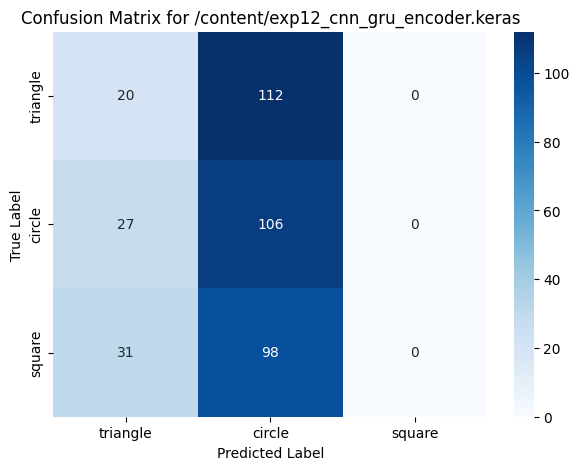

In [ ]:
# @title  Validate Model (Corrected & Self-Contained)
#
# This script loads a saved encoder, matches EEG to images, and calculates
# the overall accuracy on the entire test set. It is now self-contained.

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# --- HELPER FUNCTION (Previously in shared_utils.py) ---
def L2Normalization(x):
    """A named function for L2 normalization for safe model saving."""
    return tf.math.l2_normalize(x, axis=1)

# --- ⬇️ CONFIGURATION FOR VALIDATION ⬇️ ---
# ⚠️ Update these two variables before running!
MODEL_FILENAME = '/content/exp12_cnn_gru_encoder.keras' # e.g., 'exp02_wider_ffn_encoder.keras'
DATA_TYPE = 'timeseries' # Can be 'features' or 'timeseries'
# --- ⬆️ CONFIGURATION FOR VALIDATION ⬆️ ---

print(f"--- Validating Model: {MODEL_FILENAME} ---")

# 1. Load packaged data from the setup script
try:
    with open('all_data.pkl', 'rb') as f:
        all_data = pickle.load(f)
    clip_embeddings = all_data['clip_embeddings']
except FileNotFoundError:
    raise SystemExit("❌ ERROR: 'all_data.pkl' not found. Please run the '00_setup.py' script first.")

# 2. Load the specific encoder model
try:
    encoder = tf.keras.models.load_model(MODEL_FILENAME, custom_objects={'L2Normalization': L2Normalization})
    print("✅ Encoder model loaded successfully.")
except Exception as e:
     raise SystemExit(f"❌ ERROR: Could not load the model. Make sure '{MODEL_FILENAME}' exists. Error details: {e}")

# 3. Prepare the correct dataset for testing
if DATA_TYPE == 'features':
    num_samples, num_channels, num_features_per_channel = all_data['X_raw'].shape
    X_reshaped = all_data['X_raw'].reshape(num_samples, num_channels * num_features_per_channel)
    scaler = StandardScaler()
    X_full_data = scaler.fit_transform(X_reshaped)
    y_full_data = all_data['y_raw']
elif DATA_TYPE == 'timeseries':
    X_full_data = all_data['X_timeseries']
    y_full_data = all_data['y_timeseries_str']
else:
    raise ValueError("DATA_TYPE must be 'features' or 'timeseries'")

# Create a consistent test split
_, X_test, _, y_test = train_test_split(X_full_data, y_full_data, test_size=0.2, random_state=42, stratify=y_full_data)
print(f"✅ Prepared {len(X_test)} test samples.")

# 4. Generate Embeddings and Make Predictions
predicted_eeg_embeddings = encoder.predict(X_test)
class_labels = list(clip_embeddings.keys())
clip_matrix = np.vstack([clip_embeddings[label] for label in class_labels])
similarities = cosine_similarity(predicted_eeg_embeddings, clip_matrix)
pred_indices = np.argmax(similarities, axis=1)
pred_labels = [class_labels[i] for i in pred_indices]

# 5. Display Results
accuracy = accuracy_score(y_test, pred_labels)
print(f"\n--- OVERALL PERFORMANCE ON TEST SET ---")
print(f"✅ Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, pred_labels, labels=class_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Confusion Matrix for {MODEL_FILENAME}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



# t-SNE for CNN+GRU in Timeseries

✅ CNN+GRU encoder loaded
🔄 Generating CNN+GRU embeddings...
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
🔄 Running t-SNE...


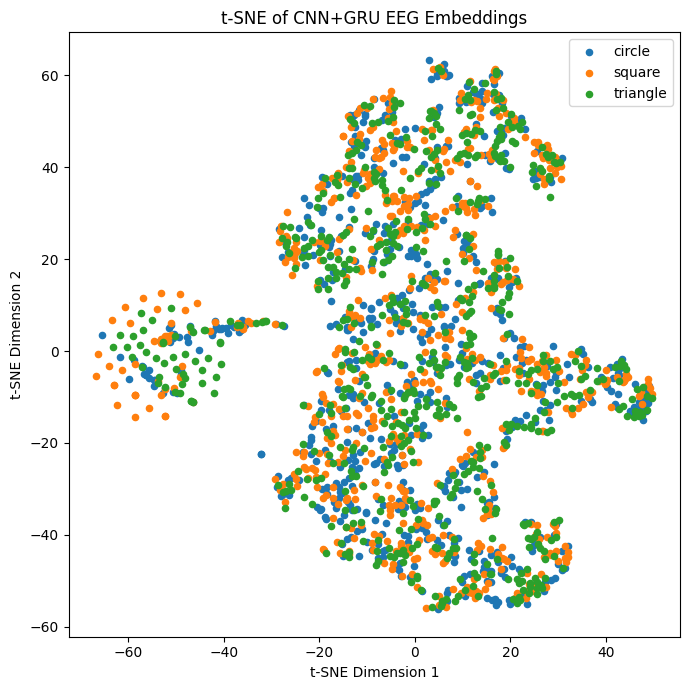

In [ ]:
# ============================================================
# t-SNE Visualization – CNN + GRU EEG Encoder (Experiment 12)
# Consistent with all previous EEG t-SNE figures
# ============================================================

import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ---------- Helper ----------
def L2Normalization(x):
    return tf.math.l2_normalize(x, axis=1)

# ---------- Load trained encoder ----------
ENCODER_PATH = "exp12_cnn_gru_encoder.keras"
encoder = tf.keras.models.load_model(
    ENCODER_PATH,
    custom_objects={"L2Normalization": L2Normalization}
)
print("✅ CNN+GRU encoder loaded")

# ---------- Load data ----------
with open("all_data.pkl", "rb") as f:
    all_data = pickle.load(f)

X_timeseries = all_data["X_timeseries"]          # (N, time, channels)
y_raw = all_data["y_timeseries_str"]
unique_labels = sorted(list(set(y_raw)))

# ---------- Scale time-series (same as training) ----------
scaler = StandardScaler()
X_flat = X_timeseries.reshape(-1, X_timeseries.shape[-1])
X_scaled_flat = scaler.fit_transform(X_flat)
X_scaled = X_scaled_flat.reshape(X_timeseries.shape)

# ---------- Generate EEG embeddings ----------
print("🔄 Generating CNN+GRU embeddings...")
Z = encoder.predict(X_scaled, batch_size=32)

# ---------- t-SNE ----------
print("🔄 Running t-SNE...")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="pca",
    random_state=42
)
Z_2d = tsne.fit_transform(Z)

# ---------- Plot (EXACT SAME STYLE AS ALL OTHER FIGURES) ----------
plt.figure(figsize=(7, 7))

for lab in unique_labels:
    idx = np.where(np.array(y_raw) == lab)[0]
    plt.scatter(
        Z_2d[idx, 0],
        Z_2d[idx, 1],
        s=20,
        label=lab
    )

plt.legend()
plt.title("t-SNE of CNN+GRU EEG Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()


In [ ]:
# @title  Run Experiment 13 - CNN+Transformer on Time-Series
#
# This script trains a state-of-the-art hybrid model that uses a CNN for
# feature extraction and a Transformer block for its self-attention mechanism,
# which can be very effective at finding important temporal dependencies.

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda, Conv1D, MaxPooling1D, Flatten, Reshape, LayerNormalization, MultiHeadAttention
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
import pickle
import os

# --- HELPER FUNCTIONS (to make script self-contained) ---
def L2Normalization(x):
    """A named function for L2 normalization for safe model saving."""
    return tf.math.l2_normalize(x, axis=1)

def triplet_loss(y_true, y_pred, alpha=0.4):
    """The Triplet Loss function."""
    embedding_dim = tf.shape(y_pred)[1] // 3
    anchor, pos, neg = y_pred[:, :embedding_dim], y_pred[:, embedding_dim:embedding_dim*2], y_pred[:, embedding_dim*2:]
    pos_dist = tf.reduce_sum(tf.square(anchor - pos), axis=1)
    neg_dist = tf.reduce_sum(tf.square(anchor - neg), axis=1)
    loss = tf.reduce_mean(tf.maximum(pos_dist - neg_dist + alpha, 0.0))
    return loss

def create_triplets(X_features, y_labels_str, clip_embeds):
    """Creates anchor, positive, and negative samples for training."""
    x_anchor, x_positive, x_negative = [], [], []
    classes = list(clip_embeds.keys())
    for i in range(len(X_features)):
        anchor_eeg, true_label_name = X_features[i], y_labels_str[i]
        positive_clip = clip_embeds[true_label_name]
        negative_label_name = np.random.choice([c for c in classes if c != true_label_name])
        negative_clip = clip_embeds[negative_label_name]
        x_anchor.append(anchor_eeg)
        x_positive.append(positive_clip)
        x_negative.append(negative_clip)
    return np.array(x_anchor), np.array(x_positive), np.array(x_negative)

# --- 1. SETUP ---
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(42)
np.random.seed(42)

# --- 2. LOAD & PREPARE DATA ---
print("--- Loading and Preparing Data for Experiment 13 ---")
with open('all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)
X_timeseries = all_data['X_timeseries']
y_timeseries_str = all_data['y_timeseries_str']
clip_embeddings = all_data['clip_embeddings']

scaler = StandardScaler()
X_reshaped = X_timeseries.reshape(-1, X_timeseries.shape[-1])
X_scaled_reshaped = scaler.fit_transform(X_reshaped)
X_scaled = X_scaled_reshaped.reshape(X_timeseries.shape)
print(f"✅ Time-series data prepared and scaled. Shape: {X_scaled.shape}")

# --- 3. BUILD THE CNN+TRANSFORMER ENCODER MODEL ---
def transformer_encoder_block(inputs, head_size, num_heads, ff_dim, dropout=0):
    """Defines a single Transformer block."""
    # Attention and Normalization
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = Dropout(dropout)(x)
    res = x + inputs
    x = LayerNormalization(epsilon=1e-6)(res)
    # Feed Forward Part
    ff_out = Dense(ff_dim, activation="relu")(x)
    ff_out = Dropout(dropout)(ff_out)
    ff_out = Dense(inputs.shape[-1])(ff_out)
    return LayerNormalization(epsilon=1e-6)(x + ff_out)

def build_cnn_transformer_encoder(input_shape, embedding_dim):
    eeg_input = Input(shape=input_shape)
    x = Conv1D(filters=64, kernel_size=10, activation='relu', padding='same')(eeg_input)
    x = MaxPooling1D(2)(x)
    x = Conv1D(filters=128, kernel_size=10, activation='relu', padding='same')(x)
    x = MaxPooling1D(2)(x)
    # Add a transformer block
    x = transformer_encoder_block(x, head_size=128, num_heads=4, ff_dim=128, dropout=0.4)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(embedding_dim, activation=None)(x)
    x = Lambda(L2Normalization, name="L2Normalization")(x)
    return Model(inputs=eeg_input, outputs=x, name="EEG_Encoder_CNN_Transformer")

TIMESERIES_SHAPE = (X_scaled.shape[1], X_scaled.shape[2])
EMBEDDING_DIM = 512
encoder = build_cnn_transformer_encoder(TIMESERIES_SHAPE, EMBEDDING_DIM)
print("\n--- Model Architecture ---")
encoder.summary()

# --- 4. CREATE TRIPLETS & COMPILE FULL MODEL ---
anchor, positive, negative = create_triplets(X_scaled, y_timeseries_str, clip_embeddings)
anchor_input, pos_input, neg_input = Input(shape=TIMESERIES_SHAPE), Input(shape=(EMBEDDING_DIM,)), Input(shape=(EMBEDDING_DIM,))
eeg_embedding = encoder(anchor_input)
merged_output = tf.keras.layers.concatenate([eeg_embedding, pos_input, neg_input], axis=1)
training_model = Model(inputs=[anchor_input, pos_input, neg_input], outputs=merged_output)
training_model.compile(optimizer=Adam(learning_rate=0.0001), loss=triplet_loss)

# --- 5. TRAIN THE ENCODER ---
early_stopping = EarlyStopping(monitor='val_loss', patience=25, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10, min_lr=1e-6, verbose=1)

print("\n🚀 Starting training for Experiment 13...")
training_model.fit(
    [anchor, positive, negative], np.zeros((anchor.shape[0], 1)),
    epochs=200, batch_size=32, validation_split=0.2,
    callbacks=[early_stopping, reduce_lr], verbose=1
)
print("\n✅ Training complete!")

# --- 6. SAVE THE TRAINED ENCODER ---
encoder_filename = 'exp13_cnn_transformer_encoder.keras'
encoder.save(encoder_filename)
print(f"\n✅ Trained encoder saved successfully to '{encoder_filename}'")



--- Loading and Preparing Data for Experiment 13 ---
✅ Time-series data prepared and scaled. Shape: (1969, 375, 2)

--- Model Architecture ---


Model: "EEG_Encoder_CNN_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 375, 2)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 375, 64)   │      1,344 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 187, 64)   │          0 │ conv1d_2[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 187, 128)  │     82,048 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 93, 128)   │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 93, 128)   │    263,808 │ max_pooling1d_2[… │
│ (MultiHeadAttentio… │                   │            │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 93, 128)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 93, 128)   │          0 │ dropout_3[0][0],  │
│                     │                   │            │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 93, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 93, 128)   │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 93, 128)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 93, 128)   │     16,512 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 93, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 93, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     33,024 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 512)       │    131,584 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ L2Normalization     │ (None, 512)       │          0 │ dense_5[0][0]     │
│ (Lambda)            │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 545,344 (2.08 MB)

 Trainable params: 545,344 (2.08 MB)

 Non-trainable params: 0 (0.00 B)


🚀 Starting training for Experiment 13...
Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 0.3998 - val_loss: 0.4237 - learning_rate: 1.0000e-04
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.3949 - val_loss: 0.4426 - learning_rate: 1.0000e-04
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3925 - val_loss: 0.4605 - learning_rate: 1.0000e-04
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3914 - val_loss: 0.4771 - learning_rate: 1.0000e-04
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3874 - val_loss: 0.4816 - learning_rate: 1.0000e-04
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3897 - val_loss: 0.4807 - learning_rate: 1.0000e-04
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.3881 - val_loss: 0.4805 - learning_rate: 1.0000e-04
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.3875 - val_loss: 0.4824 - learning_rate: 1.0000e-04
Epoch 9/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms

--- Validating Model: /content/exp13_cnn_transformer_encoder.keras ---
✅ Encoder model loaded successfully.
✅ Prepared 394 test samples.
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step

--- OVERALL PERFORMANCE ON TEST SET ---
✅ Accuracy: 33.76%


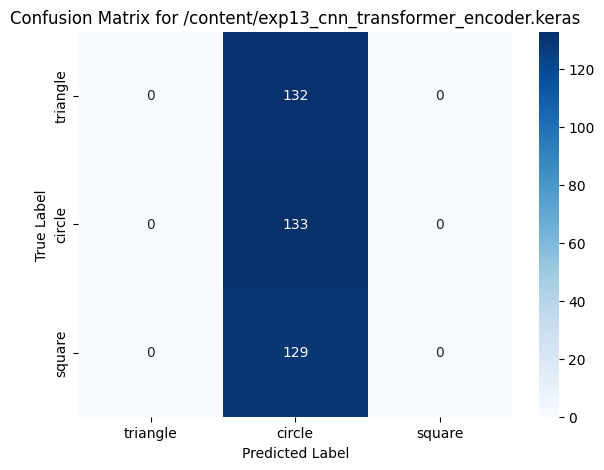

In [ ]:
# @title  Validate Model (Corrected & Self-Contained)
#
# This script loads a saved encoder, matches EEG to images, and calculates
# the overall accuracy on the entire test set. It is now self-contained.

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# --- HELPER FUNCTION (Previously in shared_utils.py) ---
def L2Normalization(x):
    """A named function for L2 normalization for safe model saving."""
    return tf.math.l2_normalize(x, axis=1)

# --- ⬇️ CONFIGURATION FOR VALIDATION ⬇️ ---
# ⚠️ Update these two variables before running!
MODEL_FILENAME = '/content/exp13_cnn_transformer_encoder.keras' # e.g., 'exp02_wider_ffn_encoder.keras'
DATA_TYPE = 'timeseries' # Can be 'features' or 'timeseries'
# --- ⬆️ CONFIGURATION FOR VALIDATION ⬆️ ---

print(f"--- Validating Model: {MODEL_FILENAME} ---")

# 1. Load packaged data from the setup script
try:
    with open('all_data.pkl', 'rb') as f:
        all_data = pickle.load(f)
    clip_embeddings = all_data['clip_embeddings']
except FileNotFoundError:
    raise SystemExit("❌ ERROR: 'all_data.pkl' not found. Please run the '00_setup.py' script first.")

# 2. Load the specific encoder model
try:
    encoder = tf.keras.models.load_model(MODEL_FILENAME, custom_objects={'L2Normalization': L2Normalization})
    print("✅ Encoder model loaded successfully.")
except Exception as e:
     raise SystemExit(f"❌ ERROR: Could not load the model. Make sure '{MODEL_FILENAME}' exists. Error details: {e}")

# 3. Prepare the correct dataset for testing
if DATA_TYPE == 'features':
    num_samples, num_channels, num_features_per_channel = all_data['X_raw'].shape
    X_reshaped = all_data['X_raw'].reshape(num_samples, num_channels * num_features_per_channel)
    scaler = StandardScaler()
    X_full_data = scaler.fit_transform(X_reshaped)
    y_full_data = all_data['y_raw']
elif DATA_TYPE == 'timeseries':
    X_full_data = all_data['X_timeseries']
    y_full_data = all_data['y_timeseries_str']
else:
    raise ValueError("DATA_TYPE must be 'features' or 'timeseries'")

# Create a consistent test split
_, X_test, _, y_test = train_test_split(X_full_data, y_full_data, test_size=0.2, random_state=42, stratify=y_full_data)
print(f"✅ Prepared {len(X_test)} test samples.")

# 4. Generate Embeddings and Make Predictions
predicted_eeg_embeddings = encoder.predict(X_test)
class_labels = list(clip_embeddings.keys())
clip_matrix = np.vstack([clip_embeddings[label] for label in class_labels])
similarities = cosine_similarity(predicted_eeg_embeddings, clip_matrix)
pred_indices = np.argmax(similarities, axis=1)
pred_labels = [class_labels[i] for i in pred_indices]

# 5. Display Results
accuracy = accuracy_score(y_test, pred_labels)
print(f"\n--- OVERALL PERFORMANCE ON TEST SET ---")
print(f"✅ Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, pred_labels, labels=class_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'Confusion Matrix for {MODEL_FILENAME}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()



#t-SNE for CNN+Transformer

✅ CNN+Transformer encoder loaded
🔄 Generating CNN+Transformer embeddings...
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
🔄 Running t-SNE...


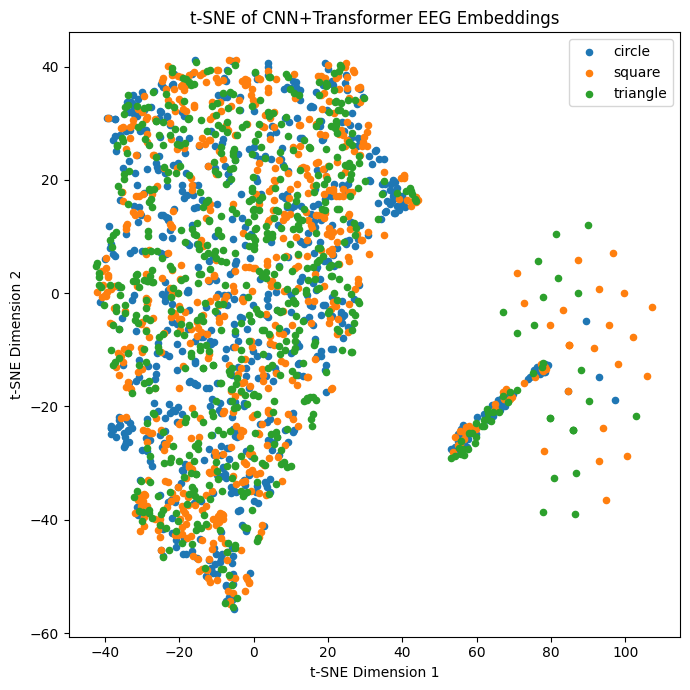

In [ ]:
# ============================================================
# t-SNE Visualization – CNN + Transformer EEG Encoder (Exp 13)
# Consistent with all previous EEG t-SNE figures
# ============================================================

import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ---------- Helper ----------
def L2Normalization(x):
    return tf.math.l2_normalize(x, axis=1)

# ---------- Load trained encoder ----------
ENCODER_PATH = "exp13_cnn_transformer_encoder.keras"
encoder = tf.keras.models.load_model(
    ENCODER_PATH,
    custom_objects={"L2Normalization": L2Normalization}
)
print("✅ CNN+Transformer encoder loaded")

# ---------- Load data ----------
with open("all_data.pkl", "rb") as f:
    all_data = pickle.load(f)

X_timeseries = all_data["X_timeseries"]          # (N, time, channels)
y_raw = all_data["y_timeseries_str"]
unique_labels = sorted(list(set(y_raw)))

# ---------- Scale time-series (same as training) ----------
scaler = StandardScaler()
X_flat = X_timeseries.reshape(-1, X_timeseries.shape[-1])
X_scaled_flat = scaler.fit_transform(X_flat)
X_scaled = X_scaled_flat.reshape(X_timeseries.shape)

# ---------- Generate EEG embeddings ----------
print("🔄 Generating CNN+Transformer embeddings...")
Z = encoder.predict(X_scaled, batch_size=32)

# ---------- t-SNE ----------
print("🔄 Running t-SNE...")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    init="pca",
    random_state=42
)
Z_2d = tsne.fit_transform(Z)

# ---------- Plot (EXACT SAME STYLE AS ALL OTHER FIGURES) ----------
plt.figure(figsize=(7, 7))

for lab in unique_labels:
    idx = np.where(np.array(y_raw) == lab)[0]
    plt.scatter(
        Z_2d[idx, 0],
        Z_2d[idx, 1],
        s=20,
        label=lab
    )

plt.legend()
plt.title("t-SNE of CNN+Transformer EEG Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.tight_layout()
plt.show()


In [ ]:
# @title  Run Experiment 14 - Principal Component Analysis (PCA)
#
# This script applies PCA, a classical linear dimensionality reduction
# technique, to the pre-computed features. It does not involve a training loop.

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pickle
import os

print("--- Running Experiment 14: PCA Encoder ---")

# --- 1. LOAD DATA ---
with open('all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)
X_raw = all_data['X_raw']
y_raw = all_data['y_raw']
print("✅ Data loaded.")

# --- 2. PREPARE & SCALE DATA ---
num_samples, num_channels, num_features = X_raw.shape
X_reshaped = X_raw.reshape(num_samples, num_channels * num_features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped)
print(f"✅ Data prepared and scaled. Shape: {X_scaled.shape}")

# --- 3. FIT PCA MODEL ---
# We'll reduce the 40 features down to the 10 most important components
N_COMPONENTS = 10
pca = PCA(n_components=N_COMPONENTS)
pca.fit(X_scaled) # Fit the PCA model on the data

print(f"\nOriginal feature dimension: {X_scaled.shape[1]}")
print(f"Reduced feature dimension with PCA: {N_COMPONENTS}")
print(f"Explained variance by {N_COMPONENTS} components: {np.sum(pca.explained_variance_ratio_) * 100:.2f}%")

# --- 4. SAVE THE FITTED MODEL AND SCALER ---
# We save the fitted pca object itself, so we can apply the same transformation
# to the test data during validation.
output_filename = 'exp14_pca_model.pkl'
with open(output_filename, 'wb') as f:
    pickle.dump({'model': pca, 'scaler': scaler}, f)
print(f"\n✅ Fitted PCA model and scaler saved to '{output_filename}'")
print("\nNow, run '99_validate_model.py' to check the accuracy.")



--- Running Experiment 14: PCA Encoder ---
✅ Data loaded.
✅ Data prepared and scaled. Shape: (1820, 40)

Original feature dimension: 40
Reduced feature dimension with PCA: 10
Explained variance by 10 components: 83.47%

✅ Fitted PCA model and scaler saved to 'exp14_pca_model.pkl'

Now, run '99_validate_model.py' to check the accuracy.


--- Validating Classical Model: /content/exp14_pca_model.pkl ---
✅ Classical model and scaler loaded successfully.

--- Generating Embeddings (Transforming Data) ---
✅ Generated embeddings with shape: (1820, 10)

--- Training k-Nearest Neighbors (k-NN) classifier on embeddings ---
✅ k-NN training and prediction complete.

--- OVERALL PERFORMANCE OF EMBEDDINGS (via k-NN) ---
✅ Accuracy: 50.82%


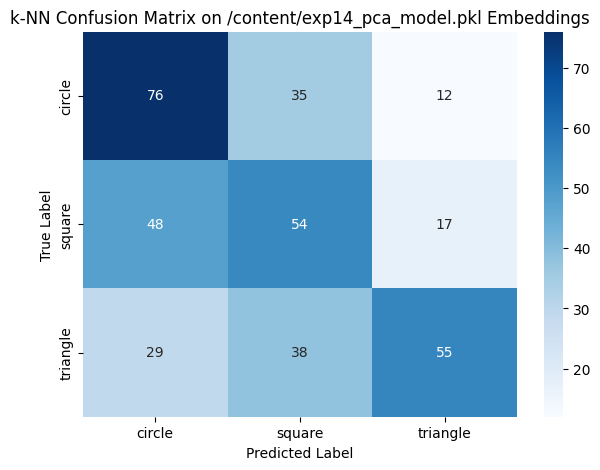

In [ ]:
# @title ▶️ Validate Classical Models (PCA, ICA, LDA)
#
# This script evaluates the quality of embeddings from classical models
# by training a k-Nearest Neighbors (k-NN) classifier on them and
# measuring its accuracy on a test set.

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# --- ⬇️ CONFIGURATION FOR VALIDATION ⬇️ ---
# ⚠️ Update this variable to test a specific classical model file.
MODEL_FILENAME = '/content/exp14_pca_model.pkl' # e.g., 'exp15_ica_model.pkl' or 'exp16_lda_model.pkl'
# --- ⬆️ CONFIGURATION FOR VALIDATION ⬆️ ---

print(f"--- Validating Classical Model: {MODEL_FILENAME} ---")

# 1. Load Data
try:
    with open('all_data.pkl', 'rb') as f:
        all_data = pickle.load(f)
    X_raw = all_data['X_raw']
    y_raw = all_data['y_raw']
    class_labels = sorted(list(np.unique(y_raw)))
except FileNotFoundError:
    raise SystemExit("❌ ERROR: 'all_data.pkl' not found. Please run the '00_setup.py' script first.")

# 2. Load the fitted classical model and its scaler
try:
    with open(MODEL_FILENAME, 'rb') as f:
        data = pickle.load(f)
    model = data['model']
    scaler = data['scaler']
    print("✅ Classical model and scaler loaded successfully.")
except Exception as e:
    raise SystemExit(f"❌ ERROR: Could not load the model file. Make sure '{MODEL_FILENAME}' exists. Error: {e}")

# 3. Prepare the full dataset using the saved scaler
num_samples, num_channels, num_features = X_raw.shape
X_reshaped = X_raw.reshape(num_samples, num_channels * num_features)
# Use the scaler that was saved with the model to ensure consistency
X_full_data = scaler.transform(X_reshaped)
y_full_data = y_raw

# 4. Generate Embeddings (transform the data)
print("\n--- Generating Embeddings (Transforming Data) ---")
generated_embeddings = model.transform(X_full_data)
print(f"✅ Generated embeddings with shape: {generated_embeddings.shape}")

# 5. Train and Evaluate a k-NN Classifier
X_train_emb, X_test_emb, y_train, y_test = train_test_split(
    generated_embeddings,
    y_full_data,
    test_size=0.2,
    random_state=42,
    stratify=y_full_data
)

print("\n--- Training k-Nearest Neighbors (k-NN) classifier on embeddings ---")
knn_classifier = KNeighborsClassifier(n_neighbors=7) # Using 7 neighbors can sometimes be more robust
knn_classifier.fit(X_train_emb, y_train)
y_pred_labels = knn_classifier.predict(X_test_emb)
print("✅ k-NN training and prediction complete.")

# 6. Display Results
accuracy = accuracy_score(y_test, y_pred_labels)
print(f"\n--- OVERALL PERFORMANCE OF EMBEDDINGS (via k-NN) ---")
print(f"✅ Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred_labels, labels=class_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'k-NN Confusion Matrix on {MODEL_FILENAME} Embeddings')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


In [ ]:
# @title  Run Experiment 15 - Independent Component Analysis (ICA)
#
# This script applies ICA, a classical technique for separating
# statistically independent source signals, to the pre-computed features.

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA
import pickle
import os

print("--- Running Experiment 15: ICA Encoder ---")

# --- 1. LOAD DATA ---
with open('all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)
X_raw = all_data['X_raw']
y_raw = all_data['y_raw']
print("✅ Data loaded.")

# --- 2. PREPARE & SCALE DATA ---
num_samples, num_channels, num_features = X_raw.shape
X_reshaped = X_raw.reshape(num_samples, num_channels * num_features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped)
print(f"✅ Data prepared and scaled. Shape: {X_scaled.shape}")

# --- 3. FIT ICA MODEL ---
N_COMPONENTS = 10
# Use a fixed random_state for reproducibility
ica = FastICA(n_components=N_COMPONENTS, random_state=42)
ica.fit(X_scaled)

print(f"\nOriginal feature dimension: {X_scaled.shape[1]}")
print(f"Reduced feature dimension with ICA: {N_COMPONENTS}")

# --- 4. SAVE THE FITTED MODEL AND SCALER ---
output_filename = 'exp15_ica_model.pkl'
with open(output_filename, 'wb') as f:
    pickle.dump({'model': ica, 'scaler': scaler}, f)
print(f"\n✅ Fitted ICA model and scaler saved to '{output_filename}'")
print("\nNow, run '99_validate_model.py' to check the accuracy.")



--- Running Experiment 15: ICA Encoder ---
✅ Data loaded.
✅ Data prepared and scaled. Shape: (1820, 40)

Original feature dimension: 40
Reduced feature dimension with ICA: 10

✅ Fitted ICA model and scaler saved to 'exp15_ica_model.pkl'

Now, run '99_validate_model.py' to check the accuracy.


--- Validating Classical Model: /content/exp15_ica_model.pkl ---
✅ Classical model and scaler loaded successfully.

--- Generating Embeddings (Transforming Data) ---
✅ Generated embeddings with shape: (1820, 10)

--- Training k-Nearest Neighbors (k-NN) classifier on embeddings ---
✅ k-NN training and prediction complete.

--- OVERALL PERFORMANCE OF EMBEDDINGS (via k-NN) ---
✅ Accuracy: 46.98%


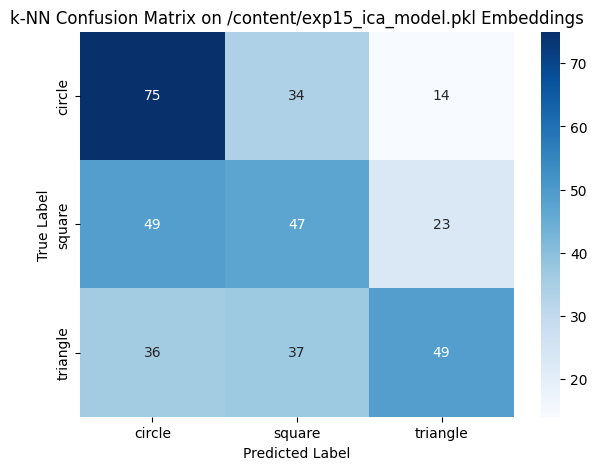

In [ ]:
# @title ▶️ Validate Classical Models (PCA, ICA, LDA)
#
# This script evaluates the quality of embeddings from classical models
# by training a k-Nearest Neighbors (k-NN) classifier on them and
# measuring its accuracy on a test set.

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# --- ⬇️ CONFIGURATION FOR VALIDATION ⬇️ ---
# ⚠️ Update this variable to test a specific classical model file.
MODEL_FILENAME = '/content/exp15_ica_model.pkl' # e.g., 'exp15_ica_model.pkl' or 'exp16_lda_model.pkl'
# --- ⬆️ CONFIGURATION FOR VALIDATION ⬆️ ---

print(f"--- Validating Classical Model: {MODEL_FILENAME} ---")

# 1. Load Data
try:
    with open('all_data.pkl', 'rb') as f:
        all_data = pickle.load(f)
    X_raw = all_data['X_raw']
    y_raw = all_data['y_raw']
    class_labels = sorted(list(np.unique(y_raw)))
except FileNotFoundError:
    raise SystemExit("❌ ERROR: 'all_data.pkl' not found. Please run the '00_setup.py' script first.")

# 2. Load the fitted classical model and its scaler
try:
    with open(MODEL_FILENAME, 'rb') as f:
        data = pickle.load(f)
    model = data['model']
    scaler = data['scaler']
    print("✅ Classical model and scaler loaded successfully.")
except Exception as e:
    raise SystemExit(f"❌ ERROR: Could not load the model file. Make sure '{MODEL_FILENAME}' exists. Error: {e}")

# 3. Prepare the full dataset using the saved scaler
num_samples, num_channels, num_features = X_raw.shape
X_reshaped = X_raw.reshape(num_samples, num_channels * num_features)
# Use the scaler that was saved with the model to ensure consistency
X_full_data = scaler.transform(X_reshaped)
y_full_data = y_raw

# 4. Generate Embeddings (transform the data)
print("\n--- Generating Embeddings (Transforming Data) ---")
generated_embeddings = model.transform(X_full_data)
print(f"✅ Generated embeddings with shape: {generated_embeddings.shape}")

# 5. Train and Evaluate a k-NN Classifier
X_train_emb, X_test_emb, y_train, y_test = train_test_split(
    generated_embeddings,
    y_full_data,
    test_size=0.2,
    random_state=42,
    stratify=y_full_data
)

print("\n--- Training k-Nearest Neighbors (k-NN) classifier on embeddings ---")
knn_classifier = KNeighborsClassifier(n_neighbors=7) # Using 7 neighbors can sometimes be more robust
knn_classifier.fit(X_train_emb, y_train)
y_pred_labels = knn_classifier.predict(X_test_emb)
print("✅ k-NN training and prediction complete.")

# 6. Display Results
accuracy = accuracy_score(y_test, y_pred_labels)
print(f"\n--- OVERALL PERFORMANCE OF EMBEDDINGS (via k-NN) ---")
print(f"✅ Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred_labels, labels=class_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'k-NN Confusion Matrix on {MODEL_FILENAME} Embeddings')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


In [ ]:
# @title  Run Experiment 16 - Linear Discriminant Analysis (LDA)
#
# This script applies LDA, a supervised dimensionality reduction technique
# that finds a feature subspace that maximizes class separability.

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pickle
import os

print("--- Running Experiment 16: LDA Encoder ---")

# --- 1. LOAD DATA ---
with open('all_data.pkl', 'rb') as f:
    all_data = pickle.load(f)
X_raw = all_data['X_raw']
y_raw = all_data['y_raw']
print("✅ Data loaded.")

# --- 2. PREPARE & SCALE DATA ---
num_samples, num_channels, num_features = X_raw.shape
X_reshaped = X_raw.reshape(num_samples, num_channels * num_features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped)
print(f"✅ Data prepared and scaled. Shape: {X_scaled.shape}")

# --- 3. FIT LDA MODEL ---
# LDA can reduce dimensions to at most n_classes - 1 (i.e., 3 - 1 = 2)
N_COMPONENTS = 2
lda = LinearDiscriminantAnalysis(n_components=N_COMPONENTS)
# LDA is supervised, so it requires the labels (y_raw) during fitting.
lda.fit(X_scaled, y_raw)

print(f"\nOriginal feature dimension: {X_scaled.shape[1]}")
print(f"Reduced feature dimension with LDA: {N_COMPONENTS}")
print(f"Explained variance by components: {lda.explained_variance_ratio_ * 100}")

# --- 4. SAVE THE FITTED MODEL AND SCALER ---
output_filename = 'exp16_lda_model.pkl'
with open(output_filename, 'wb') as f:
    pickle.dump({'model': lda, 'scaler': scaler}, f)
print(f"\n✅ Fitted LDA model and scaler saved to '{output_filename}'")
print("\nNow, run '99_validate_model.py' to check the accuracy.")



--- Running Experiment 16: LDA Encoder ---
✅ Data loaded.
✅ Data prepared and scaled. Shape: (1820, 40)

Original feature dimension: 40
Reduced feature dimension with LDA: 2
Explained variance by components: [62.16094619 37.83905381]

✅ Fitted LDA model and scaler saved to 'exp16_lda_model.pkl'

Now, run '99_validate_model.py' to check the accuracy.


--- Validating Classical Model: /content/exp16_lda_model.pkl ---
✅ Classical model and scaler loaded successfully.

--- Generating Embeddings (Transforming Data) ---
✅ Generated embeddings with shape: (1820, 2)

--- Training k-Nearest Neighbors (k-NN) classifier on embeddings ---
✅ k-NN training and prediction complete.

--- OVERALL PERFORMANCE OF EMBEDDINGS (via k-NN) ---
✅ Accuracy: 41.48%


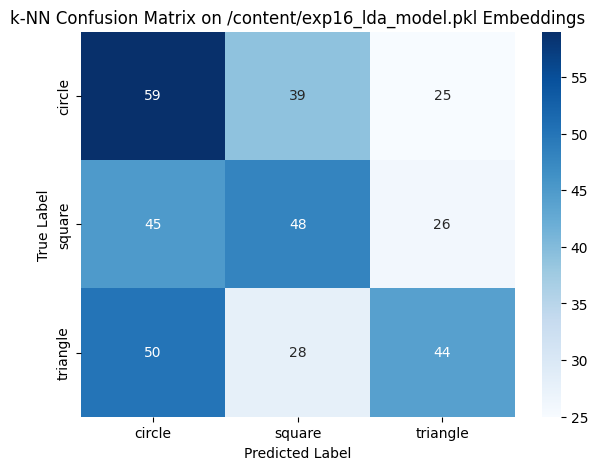

In [ ]:
# @title ▶️ Validate Classical Models (PCA, ICA, LDA)
#
# This script evaluates the quality of embeddings from classical models
# by training a k-Nearest Neighbors (k-NN) classifier on them and
# measuring its accuracy on a test set.

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# --- ⬇️ CONFIGURATION FOR VALIDATION ⬇️ ---
# ⚠️ Update this variable to test a specific classical model file.
MODEL_FILENAME = '/content/exp16_lda_model.pkl' # e.g., 'exp15_ica_model.pkl' or 'exp16_lda_model.pkl'
# --- ⬆️ CONFIGURATION FOR VALIDATION ⬆️ ---

print(f"--- Validating Classical Model: {MODEL_FILENAME} ---")

# 1. Load Data
try:
    with open('all_data.pkl', 'rb') as f:
        all_data = pickle.load(f)
    X_raw = all_data['X_raw']
    y_raw = all_data['y_raw']
    class_labels = sorted(list(np.unique(y_raw)))
except FileNotFoundError:
    raise SystemExit("❌ ERROR: 'all_data.pkl' not found. Please run the '00_setup.py' script first.")

# 2. Load the fitted classical model and its scaler
try:
    with open(MODEL_FILENAME, 'rb') as f:
        data = pickle.load(f)
    model = data['model']
    scaler = data['scaler']
    print("✅ Classical model and scaler loaded successfully.")
except Exception as e:
    raise SystemExit(f"❌ ERROR: Could not load the model file. Make sure '{MODEL_FILENAME}' exists. Error: {e}")

# 3. Prepare the full dataset using the saved scaler
num_samples, num_channels, num_features = X_raw.shape
X_reshaped = X_raw.reshape(num_samples, num_channels * num_features)
# Use the scaler that was saved with the model to ensure consistency
X_full_data = scaler.transform(X_reshaped)
y_full_data = y_raw

# 4. Generate Embeddings (transform the data)
print("\n--- Generating Embeddings (Transforming Data) ---")
generated_embeddings = model.transform(X_full_data)
print(f"✅ Generated embeddings with shape: {generated_embeddings.shape}")

# 5. Train and Evaluate a k-NN Classifier
X_train_emb, X_test_emb, y_train, y_test = train_test_split(
    generated_embeddings,
    y_full_data,
    test_size=0.2,
    random_state=42,
    stratify=y_full_data
)

print("\n--- Training k-Nearest Neighbors (k-NN) classifier on embeddings ---")
knn_classifier = KNeighborsClassifier(n_neighbors=7) # Using 7 neighbors can sometimes be more robust
knn_classifier.fit(X_train_emb, y_train)
y_pred_labels = knn_classifier.predict(X_test_emb)
print("✅ k-NN training and prediction complete.")

# 6. Display Results
accuracy = accuracy_score(y_test, y_pred_labels)
print(f"\n--- OVERALL PERFORMANCE OF EMBEDDINGS (via k-NN) ---")
print(f"✅ Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred_labels, labels=class_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title(f'k-NN Confusion Matrix on {MODEL_FILENAME} Embeddings')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
